# Determination of Optimal Infill Density for PLA FDM 3D Printed Parts through Mechanical Response and Resource Efficiency Analysis (Project Optimal Infill Density) 
- This is to assess the PLA Experimental Dataset and know the nature of the data.
- Various Analysis Testing will be used in order to explore relationship between data features.
- Graphs and other statistical methods are considered based on the expected results and supporting articles on what methods will be needed in order to arrive to a statistically sound result.

## Phase I - Data Understanding and Validation

### 1.1 Importing Libraries  

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats
from scipy.stats import f_oneway, kruskal, shapiro, levene, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
import warnings
import math

# To avoid displaying FutureWarnings from pandas/numpy
warnings.filterwarnings('ignore', category=FutureWarning)

# Allow to show all columns when printing dataframes
pd.set_option('display.max_columns', None)

# Set seaborn theme for better aesthetics
sns.set_theme(style="whitegrid")

### 1.2 Loading Dataset

In [ ]:
# Load the dataset
df = pd.read_csv("EXP DATAV2_CLEANED.csv", header=0)
df.head()

,item_no,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,remarks
0,1,4/14/2026,15:15:57,15:23:30,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,00:03:13,00:07:33,1.40,1.44,0.013,35.8098,1.68293,NaN
1,2,4/14/2026,15:25:15,15:33:12,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,00:03:13,00:07:57,1.40,1.44,0.013,33.5701,1.92406,NaN
2,3,4/14/2026,15:34:26,15:42:32,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,00:03:13,00:08:06,1.40,1.44,0.013,36.1737,1.59461,NaN
3,4,4/14/2026,15:43:59,15:51:56,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,00:03:13,00:07:57,1.41,1.44,0.013,36.8314,1.54971,NaN
4,5,4/14/2026,15:53:29,16:01:25,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,00:03:13,00:07:56,1.41,1.44,0.012,34.4062,1.69792,NaN


### 1.3 Inspection of Dataset Structure

In [ ]:
# Display dataset shape
print("Dataset shape: ", df.shape)

Dataset shape:  (50, 23)


In [ ]:
# Print summary info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   item_no                 50 non-null     int64  
 1   print_date              50 non-null     str    
 2   start_time              50 non-null     str    
 3   end_time                50 non-null     str    
 4   specimen_id             50 non-null     str    
 5   replicate_no            50 non-null     int64  
 6   infill_density_percent  50 non-null     int64  
 7   infill_pattern          50 non-null     str    
 8   material_type           50 non-null     str    
 9   layer_height_mm         50 non-null     float64
 10  nozzle_temp_c           50 non-null     int64  
 11  bed_temp_c              50 non-null     int64  
 12  wall_count              50 non-null     int64  
 13  top_layers              50 non-null     int64  
 14  bottom_layers           50 non-null     int64  
 15  pr

In [ ]:
# Display data types of each column
print("Data types:\n", df.dtypes)

Data types:
 item_no                     int64
print_date                    str
start_time                    str
end_time                      str
specimen_id                   str
replicate_no                int64
infill_density_percent      int64
infill_pattern                str
material_type                 str
layer_height_mm           float64
nozzle_temp_c               int64
bed_temp_c                  int64
wall_count                  int64
top_layers                  int64
bottom_layers               int64
print_time_slicer             str
print_time_actual             str
actual_specimen_mass_g    float64
slicer_specimen_mass_g    float64
energy_used_kwh           float64
ultimate_stress_mpa       float64
strain_percent            float64
remarks                   float64
dtype: object


### 1.4 Identification and Grouping of Variable Categories

In [ ]:
# Classify columns in to data nature (Independent Variable, Dependent Variable (Resource Parameter and Mechanical Properties), Control Variable)
indep_vars = ['infill_density_percent']

dep_res_vars = ['print_time_actual',
                'print_time_slicer',
                'actual_specimen_mass_g',
                'slicer_specimen_mass_g',
                'energy_used_kwh']

dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']

dep_vars = dep_res_vars + dep_mech_vars

con_vars = ['material_type',
            'infill_pattern',
            'layer_height_mm',
            'nozzle_temp_c',
            'bed_temp_c',
            'wall_count',
            'top_layers',
            'bottom_layers']

In [ ]:
df.describe()

,item_no,replicate_no,infill_density_percent,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,remarks
count,50.00000,50.000000,50.000000,5.000000e+01,50.0,50.0,50.0,50.0,50.0,50.000000,50.000000,50.000000,50.000000,50.000000,0.0
mean,25.50000,3.000000,55.000000,2.000000e-01,220.0,50.0,2.0,5.0,5.0,1.585600,1.604000,0.016660,39.877734,2.181942,NaN
std,14.57738,1.428571,29.014423,5.607473e-17,0.0,0.0,0.0,0.0,0.0,0.102423,0.101539,0.002631,3.095246,0.406348,NaN
min,1.00000,1.000000,10.000000,2.000000e-01,220.0,50.0,2.0,5.0,5.0,1.400000,1.440000,0.012000,33.570100,1.456830,NaN
25%,13.25000,2.000000,30.000000,2.000000e-01,220.0,50.0,2.0,5.0,5.0,1.510000,1.520000,0.015000,38.456600,1.851778,NaN
50%,25.50000,3.000000,55.000000,2.000000e-01,220.0,50.0,2.0,5.0,5.0,1.590000,1.605000,0.016500,39.943250,2.227275,NaN
75%,37.75000,4.000000,80.000000,2.000000e-01,220.0,50.0,2.0,5.0,5.0,1.670000,1.700000,0.018000,40.956675,2.538385,NaN
max,50.00000,5.000000,100.000000,2.000000e-01,220.0,50.0,2.0,5.0,5.0,1.750000,1.760000,0.023000,52.598100,2.909330,NaN


In [ ]:
# Summary statistics for variables
df[indep_vars].info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   infill_density_percent  50 non-null     int64
dtypes: int64(1)
memory usage: 532.0 bytes


In [ ]:
df[dep_res_vars].info()
print("\n")
df[dep_mech_vars].info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   print_time_actual       50 non-null     str    
 1   print_time_slicer       50 non-null     str    
 2   actual_specimen_mass_g  50 non-null     float64
 3   slicer_specimen_mass_g  50 non-null     float64
 4   energy_used_kwh         50 non-null     float64
dtypes: float64(3), str(2)
memory usage: 2.9 KB


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ultimate_stress_mpa  50 non-null     float64
 1   strain_percent       50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [ ]:
df[con_vars].info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   material_type    50 non-null     str    
 1   infill_pattern   50 non-null     str    
 2   layer_height_mm  50 non-null     float64
 3   nozzle_temp_c    50 non-null     int64  
 4   bed_temp_c       50 non-null     int64  
 5   wall_count       50 non-null     int64  
 6   top_layers       50 non-null     int64  
 7   bottom_layers    50 non-null     int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 4.0 KB


In [ ]:
# Summary statistics for variables
df[indep_vars].describe()

,infill_density_percent
count,50.000000
mean,55.000000
std,29.014423
min,10.000000
25%,30.000000
50%,55.000000
75%,80.000000
max,100.000000


In [ ]:
df[dep_res_vars].describe()

,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh
count,50.000000,50.000000,50.000000
mean,1.585600,1.604000,0.016660
std,0.102423,0.101539,0.002631
min,1.400000,1.440000,0.012000
25%,1.510000,1.520000,0.015000
50%,1.590000,1.605000,0.016500
75%,1.670000,1.700000,0.018000
max,1.750000,1.760000,0.023000


In [ ]:
df[dep_mech_vars].describe()

,ultimate_stress_mpa,strain_percent
count,50.000000,50.000000
mean,39.877734,2.181942
std,3.095246,0.406348
min,33.570100,1.456830
25%,38.456600,1.851778
50%,39.943250,2.227275
75%,40.956675,2.538385
max,52.598100,2.909330


In [ ]:
df[con_vars].describe()

,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers
count,5.000000e+01,50.0,50.0,50.0,50.0,50.0
mean,2.000000e-01,220.0,50.0,2.0,5.0,5.0
std,5.607473e-17,0.0,0.0,0.0,0.0,0.0
min,2.000000e-01,220.0,50.0,2.0,5.0,5.0
25%,2.000000e-01,220.0,50.0,2.0,5.0,5.0
50%,2.000000e-01,220.0,50.0,2.0,5.0,5.0
75%,2.000000e-01,220.0,50.0,2.0,5.0,5.0
max,2.000000e-01,220.0,50.0,2.0,5.0,5.0


## Phase II - Data Cleaning and Preprocessing

### 2.1 Conversion of Time format columns to numerical

In [ ]:
# Convert 'print_time_slicer' and 'print_time_actual' columns from time format to numeric seconds
def time_to_decimal(time_str):
    if pd.isna(time_str):
        return np.nan
    try:
        parts = time_str.split(':')
        if len(parts) == 3:
            hours, minutes, seconds = parts
            return int(hours) * 3600 + int(minutes) * 60 + float(seconds)
        elif len(parts) == 2:
            minutes, seconds = parts
            return int(minutes) * 60 + float(seconds)
        else:
            return float(time_str)
    except Exception as e:
        print(f"Error converting time '{time_str}': {e}")
        return np.nan

# Apply the conversion and replace the original columns
df['print_time_slicer'] = df['print_time_slicer'].apply(time_to_decimal)
df['print_time_actual'] = df['print_time_actual'].apply(time_to_decimal)

# Display the first few rows of the updated dataset
df.head()


,item_no,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,remarks
0,1,4/14/2026,15:15:57,15:23:30,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,453.0,1.40,1.44,0.013,35.8098,1.68293,NaN
1,2,4/14/2026,15:25:15,15:33:12,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,477.0,1.40,1.44,0.013,33.5701,1.92406,NaN
2,3,4/14/2026,15:34:26,15:42:32,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,486.0,1.40,1.44,0.013,36.1737,1.59461,NaN
3,4,4/14/2026,15:43:59,15:51:56,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,477.0,1.41,1.44,0.013,36.8314,1.54971,NaN
4,5,4/14/2026,15:53:29,16:01:25,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,476.0,1.41,1.44,0.012,34.4062,1.69792,NaN


### 2.2 Missing Value Inspection

In [ ]:
# Check for missing values in the dataset.
print('Missing values in independent variables:')
print(df.isnull().sum())

Missing values in independent variables:
item_no                    0
print_date                 0
start_time                 0
end_time                   0
specimen_id                0
replicate_no               0
infill_density_percent     0
infill_pattern             0
material_type              0
layer_height_mm            0
nozzle_temp_c              0
bed_temp_c                 0
wall_count                 0
top_layers                 0
bottom_layers              0
print_time_slicer          0
print_time_actual          0
actual_specimen_mass_g     0
slicer_specimen_mass_g     0
energy_used_kwh            0
ultimate_stress_mpa        0
strain_percent             0
remarks                   50
dtype: int64


In [ ]:
# Check for missing values in the dataset
print('Missing values in independent variables:')
print(df[indep_vars].isnull().sum())
print('\nMissing values in dependent resource variables:')
print(df[dep_res_vars].isnull().sum())
print('\nMissing values in dependent mechanical variables:')
print(df[dep_mech_vars].isnull().sum())
print('\nMissing values in control variables:')
print(df[con_vars].isnull().sum())

Missing values in independent variables:
infill_density_percent    0
dtype: int64

Missing values in dependent resource variables:
print_time_actual         0
print_time_slicer         0
actual_specimen_mass_g    0
slicer_specimen_mass_g    0
energy_used_kwh           0
dtype: int64

Missing values in dependent mechanical variables:
ultimate_stress_mpa    0
strain_percent         0
dtype: int64

Missing values in control variables:
material_type      0
infill_pattern     0
layer_height_mm    0
nozzle_temp_c      0
bed_temp_c         0
wall_count         0
top_layers         0
bottom_layers      0
dtype: int64


### 2.2 Checking for Duplicates

In [ ]:
# Check for duplicate in the dataset
duplicate_ids = df[df.duplicated(subset=['specimen_id'], keep=False)]
print(f"Number of duplicated specimen IDs: {len(duplicate_ids)}")

# Check for identical measurements across key outcome columns
identical_results = df[df.duplicated(subset=dep_vars, keep=False)]
print(f"Number of identical rows: {len(identical_results)}")

Number of duplicated specimen IDs: 0
Number of identical rows: 0


### 2.3 Outlier Detection

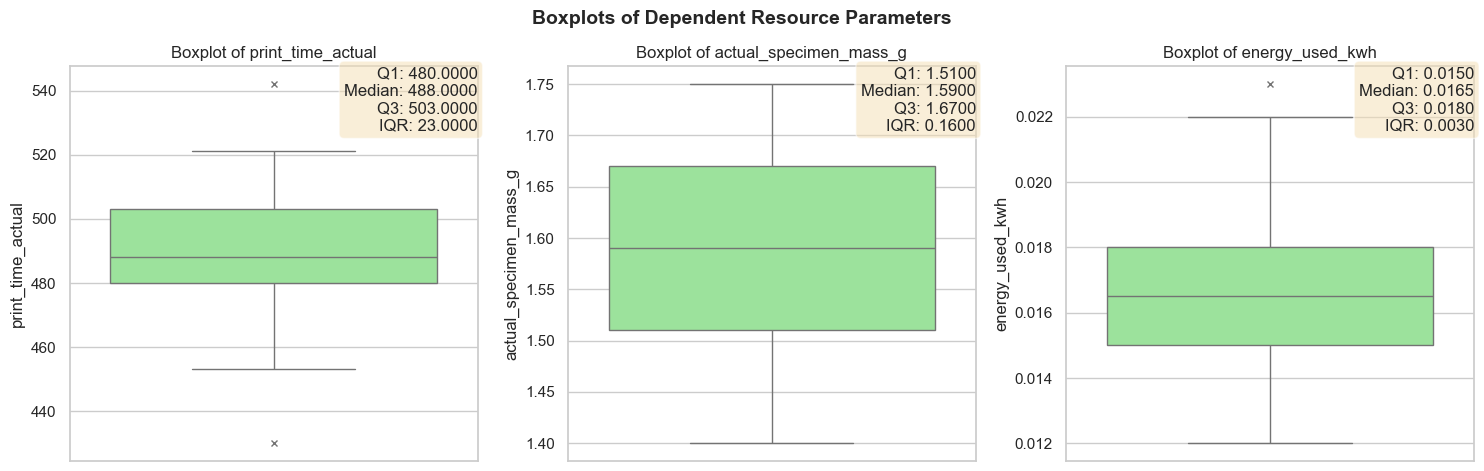

In [ ]:
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']

# Boxplot of Dependent Resource Parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(dep_res_vars):
    ax = axes[i]
    
    plt.subplot(2, 3, i + 1)
    sns.boxplot(
        y=df[var],
        color='lightgreen',
        ax=ax,
        flierprops=dict(markerfacecolor='red', marker='x', markersize=5, linestyle='none')
        )
    plt.title(f'Boxplot of {var}')

        # Compute statistics
    q1 = df[var].quantile(0.25)
    q2 = df[var].quantile(0.50)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    
    stats_text = (
        f'Q1: {q1:.4f}\n'
        f'Median: {q2:.4f}\n'
        f'Q3: {q3:.4f}\n'
        f'IQR: {iqr:.4f}'
    )
    
    # Stable placement (top-right corner)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    ax.text(
        xlim[1], ylim[1],
        stats_text,
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        verticalalignment='top',
        horizontalalignment='right'
    )

# Hide unused subplots
for idx in range(len(dep_res_vars), len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Boxplots of Dependent Resource Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

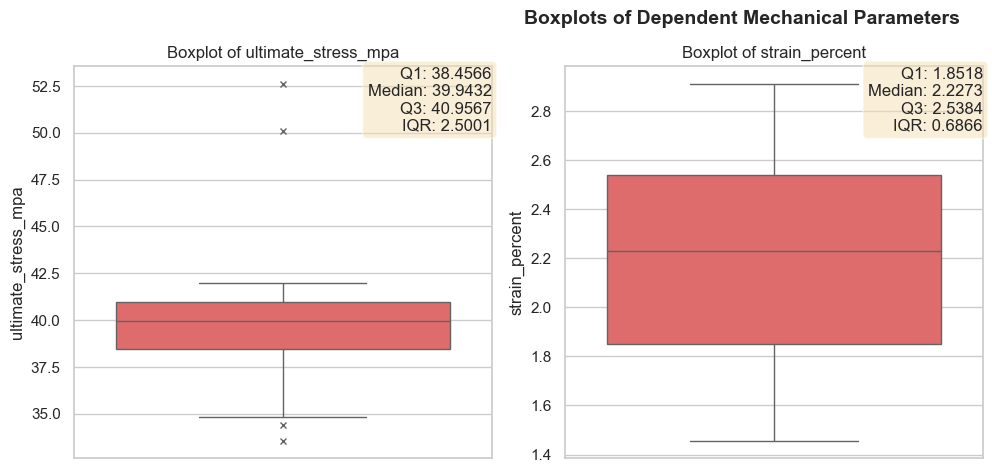

In [ ]:
# Boxplot of Dependent Resource Parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(dep_mech_vars):
    ax = axes[i]
    
    plt.subplot(2, 3, i + 1)
    sns.boxplot(
        y=df[var],
        color='#F15959',
        ax=ax,
        flierprops=dict(markerfacecolor='red', marker='x', markersize=5, linestyle='none')
        )
    plt.title(f'Boxplot of {var}')

        # Compute statistics
    q1 = df[var].quantile(0.25)
    q2 = df[var].quantile(0.50)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    
    stats_text = (
        f'Q1: {q1:.4f}\n'
        f'Median: {q2:.4f}\n'
        f'Q3: {q3:.4f}\n'
        f'IQR: {iqr:.4f}'
    )
    
    # Stable placement (top-right corner)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    ax.text(
        xlim[1], ylim[1],
        stats_text,
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        verticalalignment='top',
        horizontalalignment='right'
    )

# Hide unused subplots
for idx in range(len(dep_mech_vars), len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Boxplots of Dependent Mechanical Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("Data types:\n", df[dep_res_vars + dep_mech_vars + indep_vars].dtypes)

Data types:
 print_time_actual         float64
actual_specimen_mass_g    float64
energy_used_kwh           float64
ultimate_stress_mpa       float64
strain_percent            float64
infill_density_percent      int64
dtype: object


## Phase III - Exploratory Data Analysis (EDA)

### 3.1 Descriptive Statistics

In [ ]:
df[indep_vars + dep_vars + con_vars].describe()

,infill_density_percent,print_time_actual,print_time_slicer,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.0,50.0,50.0,50.0,50.0
mean,55.000000,491.440000,206.800000,1.585600,1.604000,0.016660,39.877734,2.181942,2.000000e-01,220.0,50.0,2.0,5.0,5.0
std,29.014423,18.975989,14.061091,0.102423,0.101539,0.002631,3.095246,0.406348,5.607473e-17,0.0,0.0,0.0,0.0,0.0
min,10.000000,430.000000,192.000000,1.400000,1.440000,0.012000,33.570100,1.456830,2.000000e-01,220.0,50.0,2.0,5.0,5.0
25%,30.000000,480.000000,195.000000,1.510000,1.520000,0.015000,38.456600,1.851778,2.000000e-01,220.0,50.0,2.0,5.0,5.0
50%,55.000000,488.000000,202.000000,1.590000,1.605000,0.016500,39.943250,2.227275,2.000000e-01,220.0,50.0,2.0,5.0,5.0
75%,80.000000,503.000000,219.000000,1.670000,1.700000,0.018000,40.956675,2.538385,2.000000e-01,220.0,50.0,2.0,5.0,5.0
max,100.000000,542.000000,231.000000,1.750000,1.760000,0.023000,52.598100,2.909330,2.000000e-01,220.0,50.0,2.0,5.0,5.0


### 3.2 Distribution Analysis

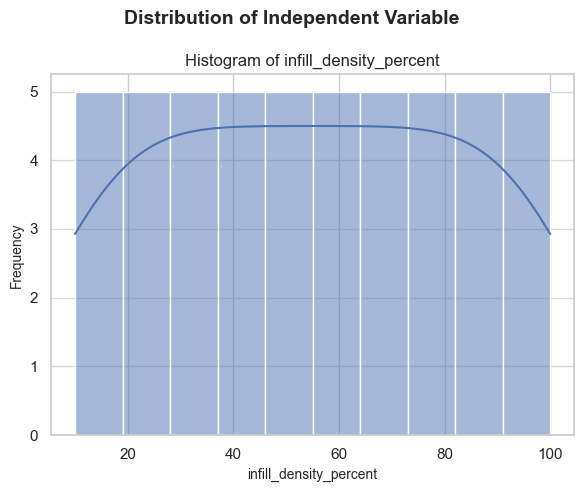

In [ ]:
# Create histograms of Independent Variables
num_vars = len(indep_vars)
fig, axes = plt.subplots(num_vars, 1, figsize=(6, 5 * num_vars))

# Ensure axes is iterable even if it's a single subplot
if num_vars == 1:
    axes = [axes]

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    sns.histplot(df[var], kde=True, ax=ax, bins=10)
    ax.set_title(f'Histogram of {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(axis='y', alpha=0.75)

plt.suptitle('Distribution of Independent Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

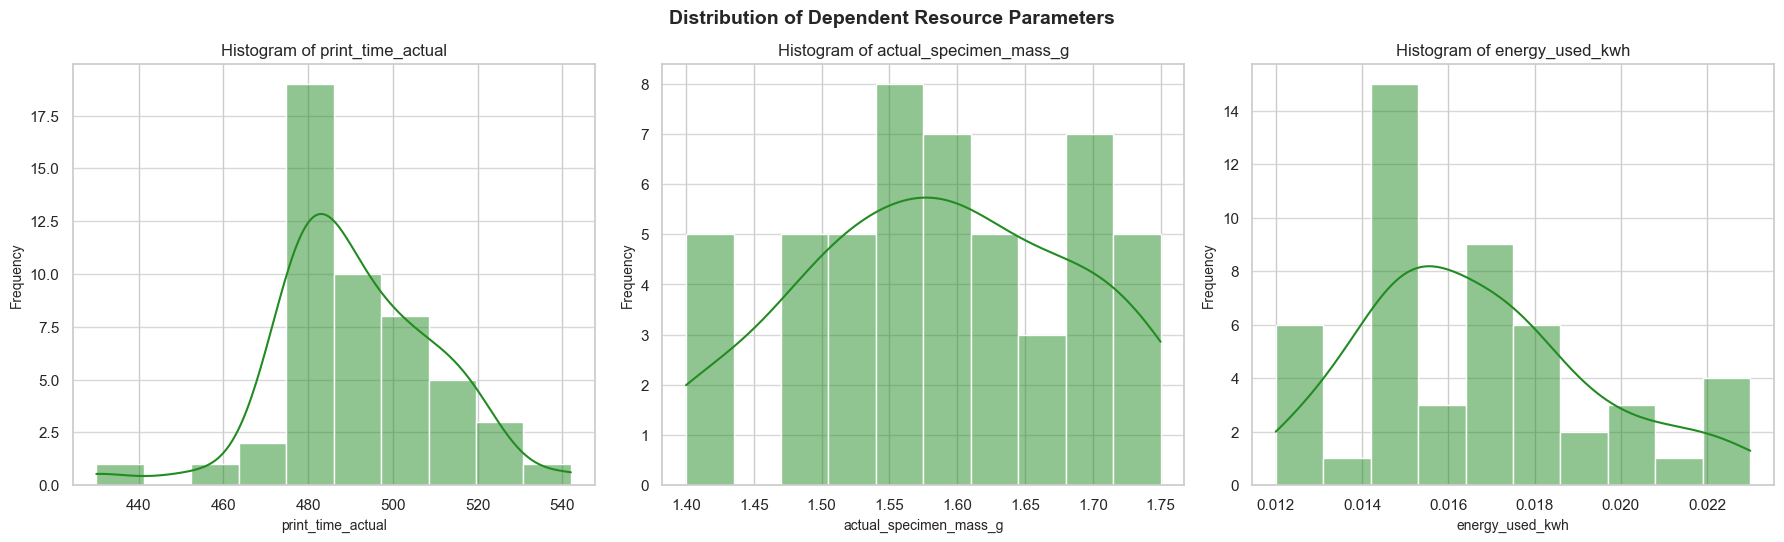

In [ ]:
# Create a histogram of the Dependent Resource Variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, var in enumerate(dep_res_vars):
    ax = axes[idx]
    sns.histplot(df[var], kde=True, ax=ax, color='forestgreen', bins=10)
    ax.set_title(f'Histogram of {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(axis='y', alpha=0.75)
# Hide unused subplots
for idx in range(len(dep_res_vars), len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Distribution of Dependent Resource Parameters', fontsize=14, fontweight='bold') 
plt.tight_layout()
plt.show()

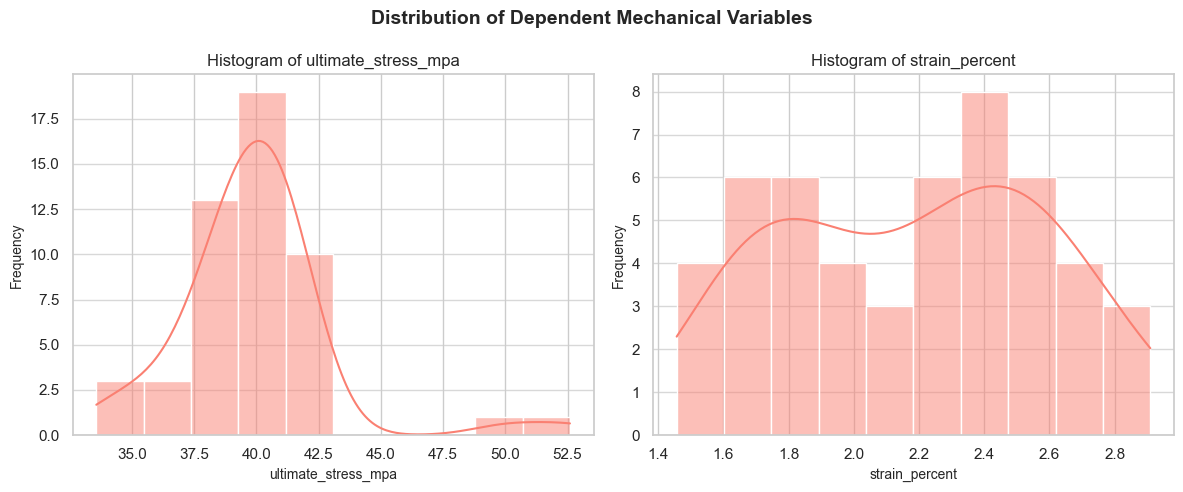

In [ ]:
# Histogram of Dependent Mechanical Variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, var in enumerate(dep_mech_vars):
    ax = axes[idx]
    sns.histplot(df[var], kde=True, ax=ax, color='salmon', bins=10)
    ax.set_title(f'Histogram of {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(axis='y', alpha=0.75)
plt.suptitle('Distribution of Dependent Mechanical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

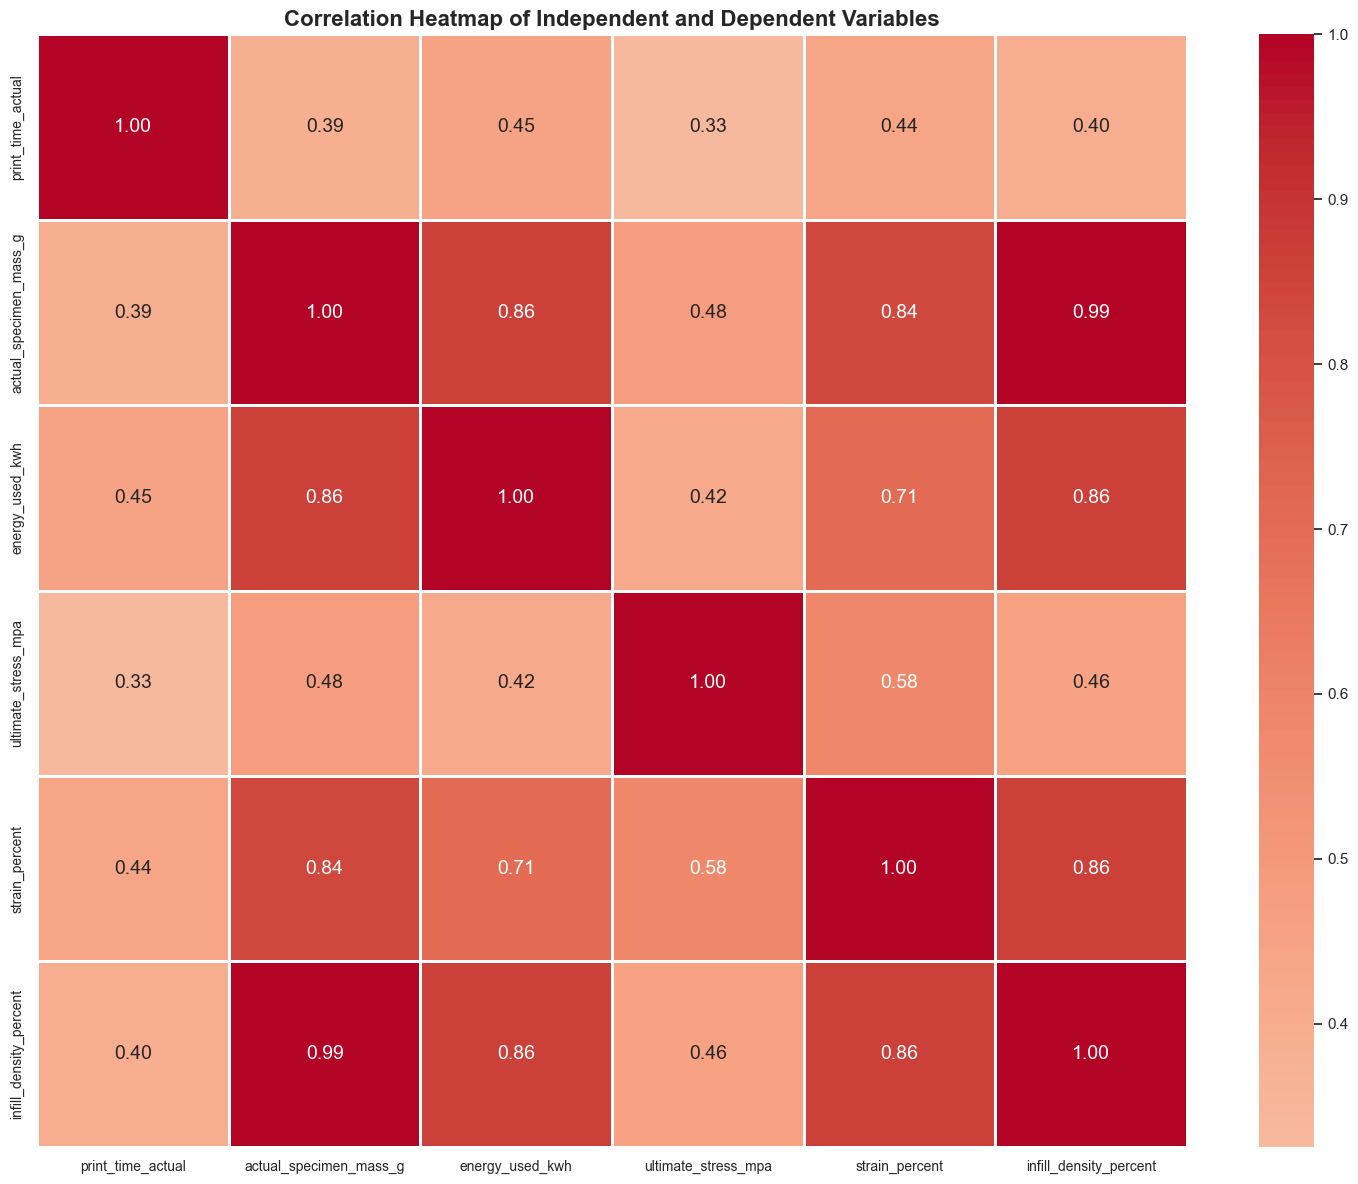

P-values:
                        print_time_actual  actual_specimen_mass_g  \
print_time_actual                  1.0000                  0.0055   
actual_specimen_mass_g             0.0055                  1.0000   
energy_used_kwh                    0.0009                  0.0000   
ultimate_stress_mpa                0.0211                  0.0004   
strain_percent                     0.0014                  0.0000   
infill_density_percent             0.0045                  0.0000   

                        energy_used_kwh  ultimate_stress_mpa  strain_percent  \
print_time_actual                0.0009               0.0211          0.0014   
actual_specimen_mass_g           0.0000               0.0004          0.0000   
energy_used_kwh                  1.0000               0.0023          0.0000   
ultimate_stress_mpa              0.0023               1.0000          0.0000   
strain_percent                   0.0000               0.0000          1.0000   
infill_density_percent    

In [ ]:
# Correlation Heatmap between independent and dependent variables
plt.figure(figsize=(15, 12))
corr_matrix = df[dep_res_vars + dep_mech_vars + indep_vars].corr(numeric_only=True)

# Calculate p-values
from scipy.stats import pearsonr
pvalues = pd.DataFrame(1.0, index=corr_matrix.index, columns=corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        if i != j:
            _, pval = pearsonr(df[corr_matrix.columns[i]], df[corr_matrix.columns[j]])
            pvalues.iloc[i, j] = pval

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, center=0, annot_kws={'size': 14})
plt.title('Correlation Heatmap of Independent and Dependent Variables', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Display p-values
print("P-values:")
print(pvalues.round(4))

### 3.4 Interaction Analysis per Replicate

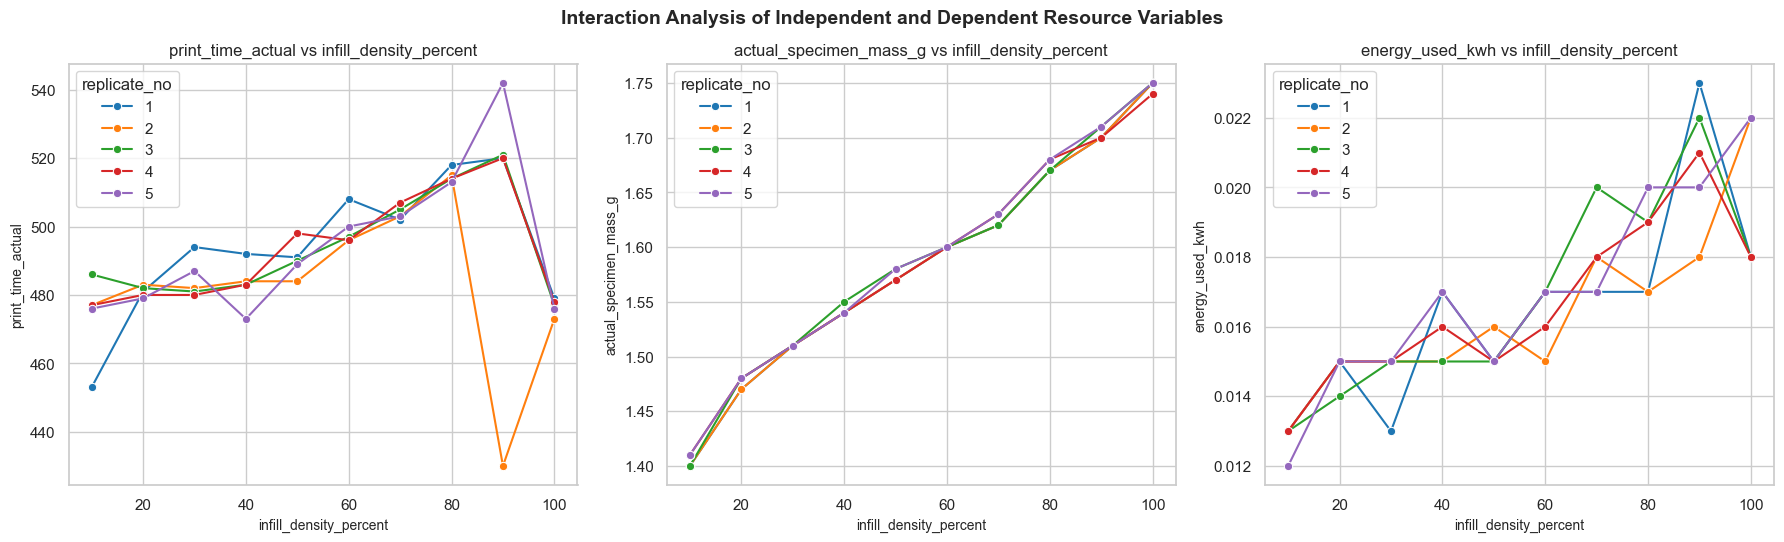

In [ ]:
# Interaction Analysis of Independent and Dependent Resource Variables through Line Plots per Replicate
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, dep_var in enumerate(dep_res_vars):
    ax = axes[i]
    sns.lineplot(
        x=df[indep_vars[0]],
        y=df[dep_var],
        hue=df['replicate_no'],
        marker='o',
        ax=ax,
        palette='tab10'
    )
    ax.set_title(f'{dep_var} vs {indep_vars[0]}', fontsize=12)
    ax.set_xlabel(indep_vars[0], fontsize=10)
    ax.set_ylabel(dep_var, fontsize=10)
    ax.grid(True)
# Hide unused subplots
for idx in range(len(dep_res_vars), len(axes)):
    axes[idx].set_visible(False)
    
plt.suptitle('Interaction Analysis of Independent and Dependent Resource Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

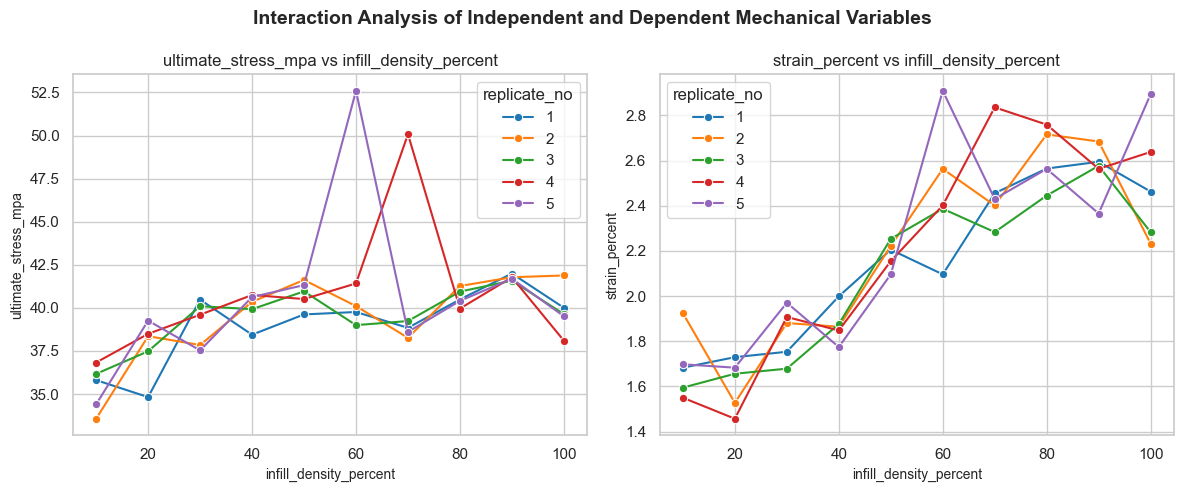

In [ ]:
# Interaction Analysis of Independent and Dependent Mechanical Variables through Line Plots per Replicate
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(dep_mech_vars):
    ax = axes[idx]
    sns.lineplot(
        x=df[indep_vars[0]],
        y=df[var],
        hue=df['replicate_no'],
        marker='o',
        ax=ax,
        palette='tab10'
    )
    ax.set_title(f'{var} vs {indep_vars[0]}', fontsize=12)
    ax.set_xlabel(indep_vars[0], fontsize=10)
    ax.set_ylabel(var, fontsize=10)
    ax.grid(True)
plt.suptitle('Interaction Analysis of Independent and Dependent Mechanical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()

Plots saved as separate_stress_plots.png


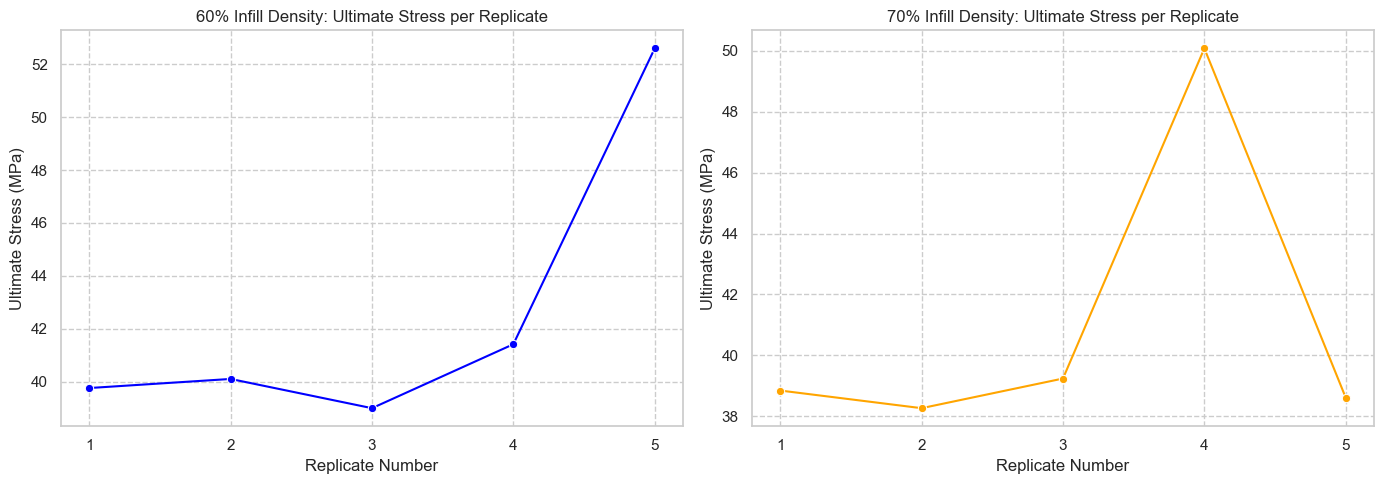

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data
data_60 = df[df['infill_density_percent'] == 60].copy()
data_70 = df[df['infill_density_percent'] == 70].copy()

# Set up subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for 60%
sns.lineplot(
    data=data_60,
    x='replicate_no',
    y='ultimate_stress_mpa',
    marker='o',
    ax=axes[0],
    color='blue'
)
axes[0].set_title('60% Infill Density: Ultimate Stress per Replicate')
axes[0].set_xlabel('Replicate Number')
axes[0].set_ylabel('Ultimate Stress (MPa)')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(True, linestyle='--')

# Plot for 70%
sns.lineplot(
    data=data_70,
    x='replicate_no',
    y='ultimate_stress_mpa',
    marker='o',
    ax=axes[1],
    color='orange'
)
axes[1].set_title('70% Infill Density: Ultimate Stress per Replicate')
axes[1].set_xlabel('Replicate Number')
axes[1].set_ylabel('Ultimate Stress (MPa)')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.savefig('separate_stress_plots.png')
print("Plots saved as separate_stress_plots.png")

### 3.5 Convert Dataset to Average

In [ ]:
# Create a new data frame that averages the dependent variables across replicates for each infill density
avg_df = df.groupby(indep_vars[0])[dep_vars].mean().reset_index()
avg_df.head(10)

,infill_density_percent,print_time_actual,print_time_slicer,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent
0,10,473.8,193.0,1.404,1.44,0.0128,35.35824,1.689846
1,20,481.0,195.0,1.476,1.49,0.0148,37.68412,1.610488
2,30,484.8,196.0,1.510,1.52,0.0146,39.11364,1.838116
3,40,483.0,198.0,1.542,1.55,0.0160,40.02072,1.872232
4,50,490.4,206.0,1.574,1.59,0.0152,40.80806,2.186410
5,60,499.4,210.0,1.600,1.62,0.0164,42.57694,2.471508
6,70,504.0,219.0,1.624,1.64,0.0180,41.00698,2.481400
7,80,514.8,228.0,1.674,1.70,0.0184,40.61494,2.609872
8,90,506.6,231.0,1.704,1.73,0.0208,41.76440,2.557180
9,100,476.6,192.0,1.748,1.76,0.0196,39.82930,2.502366


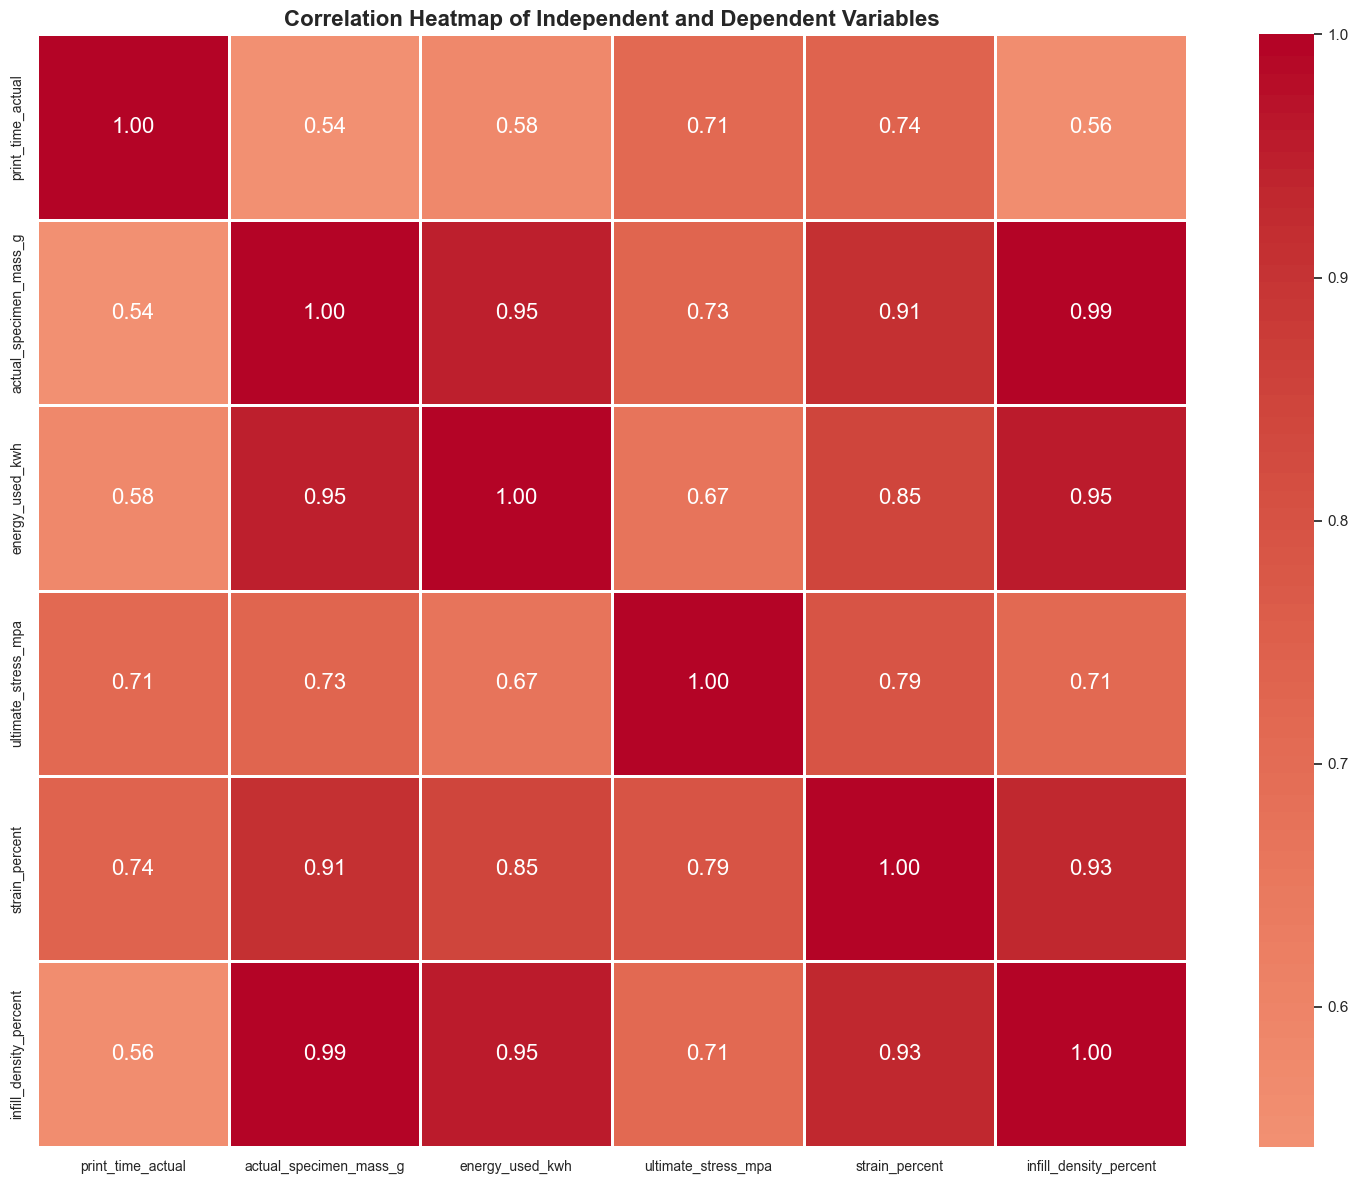

P-values:
                        print_time_actual  actual_specimen_mass_g  \
print_time_actual                  1.0000                  0.1052   
actual_specimen_mass_g             0.1052                  1.0000   
energy_used_kwh                    0.0761                  0.0000   
ultimate_stress_mpa                0.0202                  0.0168   
strain_percent                     0.0140                  0.0003   
infill_density_percent             0.0919                  0.0000   

                        energy_used_kwh  ultimate_stress_mpa  strain_percent  \
print_time_actual                0.0761               0.0202          0.0140   
actual_specimen_mass_g           0.0000               0.0168          0.0003   
energy_used_kwh                  1.0000               0.0341          0.0020   
ultimate_stress_mpa              0.0341               1.0000          0.0066   
strain_percent                   0.0020               0.0066          1.0000   
infill_density_percent    

In [ ]:
# Correlation Heatmap between independent and dependent variables
plt.figure(figsize=(15, 12))
corr_matrix = avg_df[dep_res_vars + dep_mech_vars + indep_vars].corr(numeric_only=True)

# Calculate p-values
from scipy.stats import pearsonr
pvalues = pd.DataFrame(1.0, index=corr_matrix.index, columns=corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        if i != j:
            _, pval = pearsonr(avg_df[corr_matrix.columns[i]], avg_df[corr_matrix.columns[j]])
            pvalues.iloc[i, j] = pval

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, center=0, annot_kws={'size': 16})
plt.title('Correlation Heatmap of Independent and Dependent Variables', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Display p-values
print("P-values:")
print(pvalues.round(4))

### 3.6 Line Graph of Average Dependent Resource Variables vs Infill Density

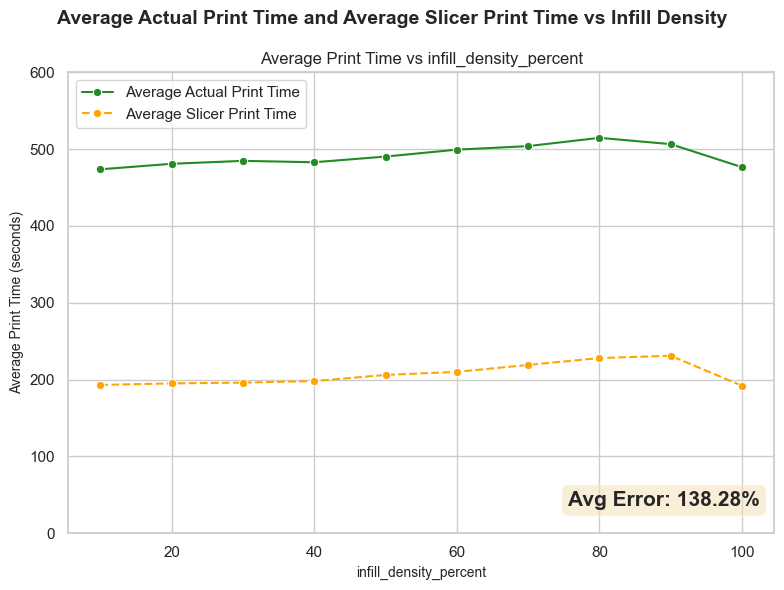


PERCENT ERROR ANALYSIS BY INDEPENDENT VARIABLES

Independent Variables: ['infill_density_percent']


--------------------------------------------------------------------------------
PERCENT ERROR STATISTICS BY INFILL_DENSITY_PERCENT
--------------------------------------------------------------------------------
                        Count  Mean Error (%)  Std Dev (pp)  Min Error (%)  Max Error (%)
infill_density_percent                                                                   
10                          1          145.49           NaN         145.49         145.49
20                          1          146.67           NaN         146.67         146.67
30                          1          147.35           NaN         147.35         147.35
40                          1          143.94           NaN         143.94         143.94
50                          1          138.06           NaN         138.06         138.06
60                          1          137.81          

In [ ]:
# Line Graph of the Average Actual Print Time and Average Slicer Print Time vs Infill Density in the same plot
# Also calculate the average percent error

num_vars = len(indep_vars)
fig, axes = plt.subplots(num_vars, 1, figsize=(8, 6 * num_vars))

# Ensure axes is iterable even if it's a single subplot
if num_vars == 1:
    axes = [axes]

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    
    # Calculate percent error: ((actual - slicer) / slicer) * 100
    avg_df['percent_error'] = ((avg_df['print_time_actual'] - avg_df['print_time_slicer']) / avg_df['print_time_slicer']) * 100
    
    sns.lineplot(
        x=avg_df[var],
        y=avg_df['print_time_actual'],
        marker='o',
        ax=ax,
        label='Average Actual Print Time',
        color='forestgreen',
    )
    sns.lineplot(
        x=avg_df[var],
        y=avg_df['print_time_slicer'],
        marker='o',
        ax=ax,
        label='Average Slicer Print Time',
        color='orange',
        linestyle='--'
    )
    ax.set_title(f'Average Print Time vs {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Average Print Time (seconds)', fontsize=10)
    ax.grid(True)
    ax.legend(loc='upper left')
    ax.set_ylim(0, 600)
    
    # Calculate and display average percent error for this variable
    avg_percent_error = avg_df['percent_error'].mean()
    ax.text(0.98, 0.05, f'Avg Error: {avg_percent_error:.2f}%', 
            transform=ax.transAxes, fontsize=15, verticalalignment='bottom', fontweight='bold',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Average Actual Print Time and Average Slicer Print Time vs Infill Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate percent error
avg_df['percent_error'] = ((avg_df['print_time_actual'] - avg_df['print_time_slicer']) / avg_df['print_time_slicer']) * 100

# Print percent error statistics per variable
print("\n" + "="*80)
print("PERCENT ERROR ANALYSIS BY INDEPENDENT VARIABLES")
print("="*80)
print(f"\nIndependent Variables: {indep_vars}\n")

# Analyze by each independent variable
for var in indep_vars:
    print(f"\n{'-'*80}")
    print(f"PERCENT ERROR STATISTICS BY {var.upper()}")
    print(f"{'-'*80}")
    
    # Group by the variable and calculate statistics
    error_by_var = avg_df.groupby(var)['percent_error'].agg([
        ('Count', 'count'),
        ('Mean Error (%)', 'mean'),
        ('Std Dev (pp)', 'std'),
        ('Min Error (%)', 'min'),
        ('Max Error (%)', 'max')
    ]).round(2)
    
    print(error_by_var.to_string())
    
    # Check deviation consistency for this variable
    std_of_means = error_by_var['Mean Error (%)'].std()
    print(f"\nVariability of Mean Errors (pp): {std_of_means:>7.2f}")
    print(f"(Lower value = more consistent across {var})")

# Overall statistics
print(f"\n{'-'*80}")
print("OVERALL STATISTICS")
print(f"{'-'*80}")
print(f"Overall Average Percent Error:  {avg_df['percent_error'].mean():>7.2f}%")
print(f"Overall Standard Deviation:     {avg_df['percent_error'].std():>7.2f}%")
print(f"Overall Min Error:              {avg_df['percent_error'].min():>7.2f}%")
print(f"Overall Max Error:              {avg_df['percent_error'].max():>7.2f}%")
print(f"Total Data Points:              {len(avg_df):>7}")

print("="*80)
print("\nNote: Positive error = Actual took longer than slicer predicted")
print("      Negative error = Actual was faster than slicer predicted")

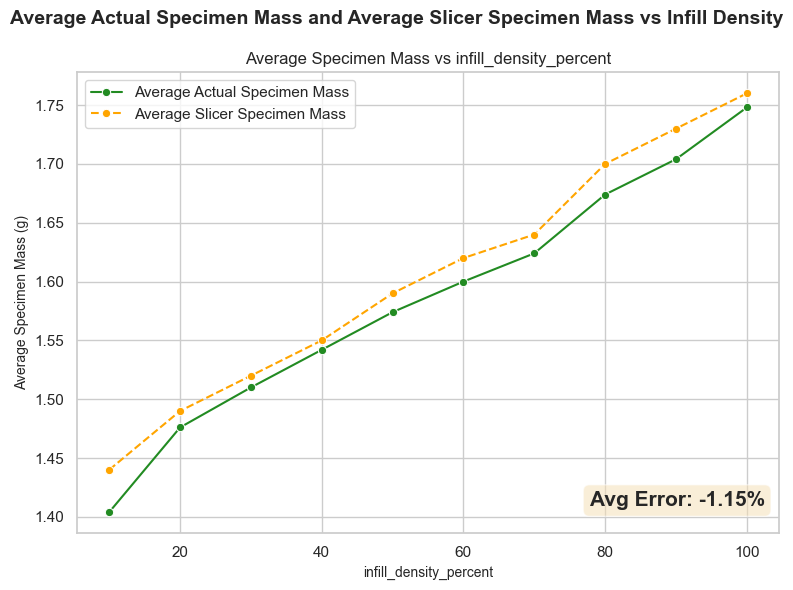


PERCENT ERROR ANALYSIS - SPECIMEN MASS BY INDEPENDENT VARIABLES

Independent Variables: ['infill_density_percent']


--------------------------------------------------------------------------------
PERCENT ERROR STATISTICS BY INFILL_DENSITY_PERCENT
--------------------------------------------------------------------------------
                        Count  Mean Error (%)  Std Dev (pp)  Min Error (%)  Max Error (%)
infill_density_percent                                                                   
10                          1           -2.50           NaN          -2.50          -2.50
20                          1           -0.94           NaN          -0.94          -0.94
30                          1           -0.66           NaN          -0.66          -0.66
40                          1           -0.52           NaN          -0.52          -0.52
50                          1           -1.01           NaN          -1.01          -1.01
60                          1          

In [ ]:
# Line Graph of the Average Actual Specimen Mass and Average Slicer Specimen Mass vs Infill Density in the same plot
num_vars = len(indep_vars)
fig, axes = plt.subplots(num_vars, 1, figsize=(8, 6 * num_vars))

# Ensure axes is iterable even if it's a single subplot
if num_vars == 1:
    axes = [axes]

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    
    # Calculate percent error: ((actual - slicer) / slicer) * 100
    avg_df['percent_error_mass'] = ((avg_df['actual_specimen_mass_g'] - avg_df['slicer_specimen_mass_g']) / avg_df['slicer_specimen_mass_g']) * 100
    
    sns.lineplot(
        x=avg_df[var],
        y=avg_df['actual_specimen_mass_g'],
        marker='o',
        ax=ax,
        label='Average Actual Specimen Mass',
        color='forestgreen',
    )
    sns.lineplot(
        x=avg_df[var],
        y=avg_df['slicer_specimen_mass_g'],
        marker='o',
        ax=ax,
        label='Average Slicer Specimen Mass',
        color='orange',
        linestyle='--'
    )
    ax.set_title(f'Average Specimen Mass vs {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Average Specimen Mass (g)', fontsize=10)
    ax.grid(True)
    ax.legend(loc='upper left')
    
    # Calculate and display average percent error for this variable
    avg_percent_error = avg_df['percent_error_mass'].mean()
    ax.text(0.98, 0.05, f'Avg Error: {avg_percent_error:.2f}%', 
            transform=ax.transAxes, fontsize=15, verticalalignment='bottom', fontweight='bold',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Average Actual Specimen Mass and Average Slicer Specimen Mass vs Infill Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate percent error for analysis
avg_df['percent_error_mass'] = ((avg_df['actual_specimen_mass_g'] - avg_df['slicer_specimen_mass_g']) / avg_df['slicer_specimen_mass_g']) * 100

# Print percent error statistics per variable
print("\n" + "="*80)
print("PERCENT ERROR ANALYSIS - SPECIMEN MASS BY INDEPENDENT VARIABLES")
print("="*80)
print(f"\nIndependent Variables: {indep_vars}\n")

# Analyze by each independent variable
for var in indep_vars:
    print(f"\n{'-'*80}")
    print(f"PERCENT ERROR STATISTICS BY {var.upper()}")
    print(f"{'-'*80}")
    
    # Group by the variable and calculate statistics
    error_by_var = avg_df.groupby(var)['percent_error_mass'].agg([
        ('Count', 'count'),
        ('Mean Error (%)', 'mean'),
        ('Std Dev (pp)', 'std'),
        ('Min Error (%)', 'min'),
        ('Max Error (%)', 'max')
    ]).round(2)
    
    print(error_by_var.to_string())
    
    # Check deviation consistency for this variable
    std_of_means = error_by_var['Mean Error (%)'].std()
    print(f"\nVariability of Mean Errors (pp): {std_of_means:>7.2f}")
    print(f"(Lower value = more consistent across {var})")

# Overall statistics
print(f"\n{'-'*80}")
print("OVERALL STATISTICS")
print(f"{'-'*80}")
print(f"Overall Average Percent Error:  {avg_df['percent_error_mass'].mean():>7.2f}%")
print(f"Overall Standard Deviation:     {avg_df['percent_error_mass'].std():>7.2f} pp")
print(f"Overall Min Error:              {avg_df['percent_error_mass'].min():>7.2f}%")
print(f"Overall Max Error:              {avg_df['percent_error_mass'].max():>7.2f}%")
print(f"Total Data Points:              {len(avg_df):>7}")

print("="*80)
print("\nNote: Positive error = Actual mass is heavier than slicer predicted")
print("      Negative error = Actual mass is lighter than slicer predicted")

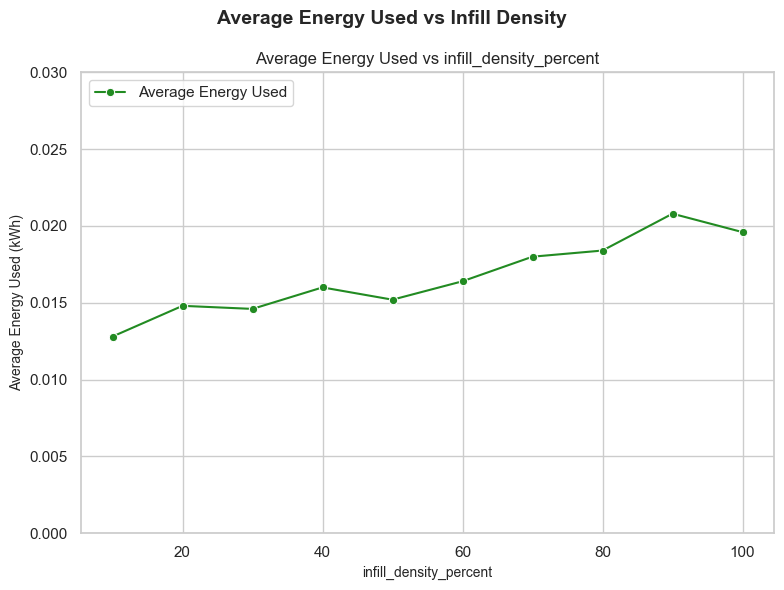

In [ ]:
# Line Graph of the Average Energy Used vs Infill Density
num_vars = len(indep_vars)
fig, axes = plt.subplots(num_vars, 1, figsize=(8, 6 * num_vars))

# Ensure axes is iterable even if it's a single subplot
if num_vars == 1:
    axes = [axes]

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    sns.lineplot(
        x=avg_df[var],
        y=avg_df['energy_used_kwh'],
        marker='o',
        ax=ax,
        label='Average Energy Used',
        color='forestgreen',
    )
    ax.set_title(f'Average Energy Used vs {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Average Energy Used (kWh)', fontsize=10)
    ax.grid(True)
    ax.legend(loc='upper left')
    ax.set_ylim(0, 0.03)

plt.suptitle('Average Energy Used vs Infill Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Line Graph of Average Mechanical Variables vs Infill Density

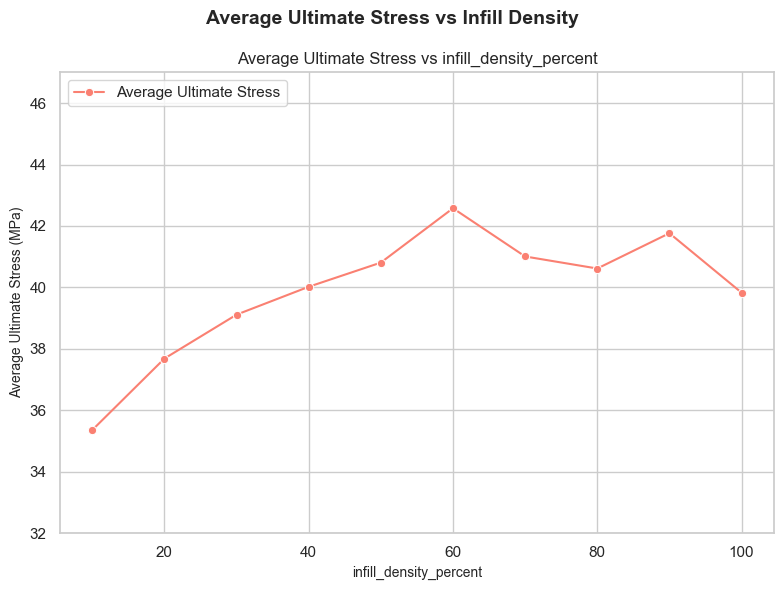

In [ ]:
# Line Graph of the Average Ultimate Stress (MPa) vs Infill Density
num_vars = len(indep_vars)
fig, axes = plt.subplots(num_vars, 1, figsize=(8, 6 * num_vars))

# Ensure axes is iterable even if it's a single subplot
if num_vars == 1:
    axes = [axes]

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    sns.lineplot(
        x=avg_df[var],
        y=avg_df['ultimate_stress_mpa'],
        marker='o',
        ax=ax,
        label='Average Ultimate Stress',
        color='salmon',
    )
    ax.set_title(f'Average Ultimate Stress vs {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Average Ultimate Stress (MPa)', fontsize=10)
    ax.grid(True)
    ax.legend(loc='upper left')
    ax.set_ylim(32, 47)

plt.suptitle('Average Ultimate Stress vs Infill Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

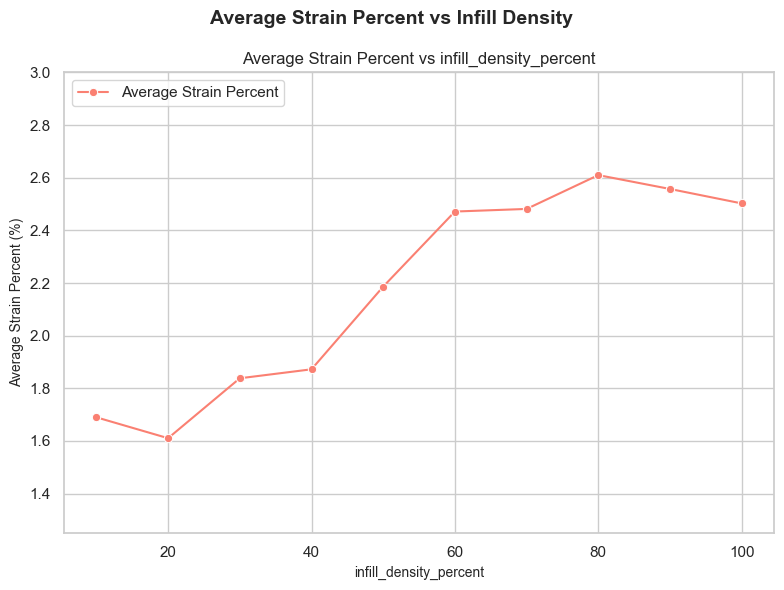

In [ ]:
# Line Graph of the Average Strain Percent vs Infill Density
num_vars = len(indep_vars)
fig, axes = plt.subplots(num_vars, 1, figsize=(8, 6 * num_vars))

# Ensure axes is iterable even if it's a single subplot
if num_vars == 1:
    axes = [axes]

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    sns.lineplot(
        x=avg_df[var],
        y=avg_df['strain_percent'],
        marker='o',
        ax=ax,
        label='Average Strain Percent',
        color='salmon'
    )
    
    ax.set_title(f'Average Strain Percent vs {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Average Strain Percent (%)', fontsize=10)
    ax.grid(True)
    ax.legend(loc='upper left')
    ax.set_ylim(1.25, 3)

plt.suptitle('Average Strain Percent vs Infill Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Pairwise Relationship Analysis

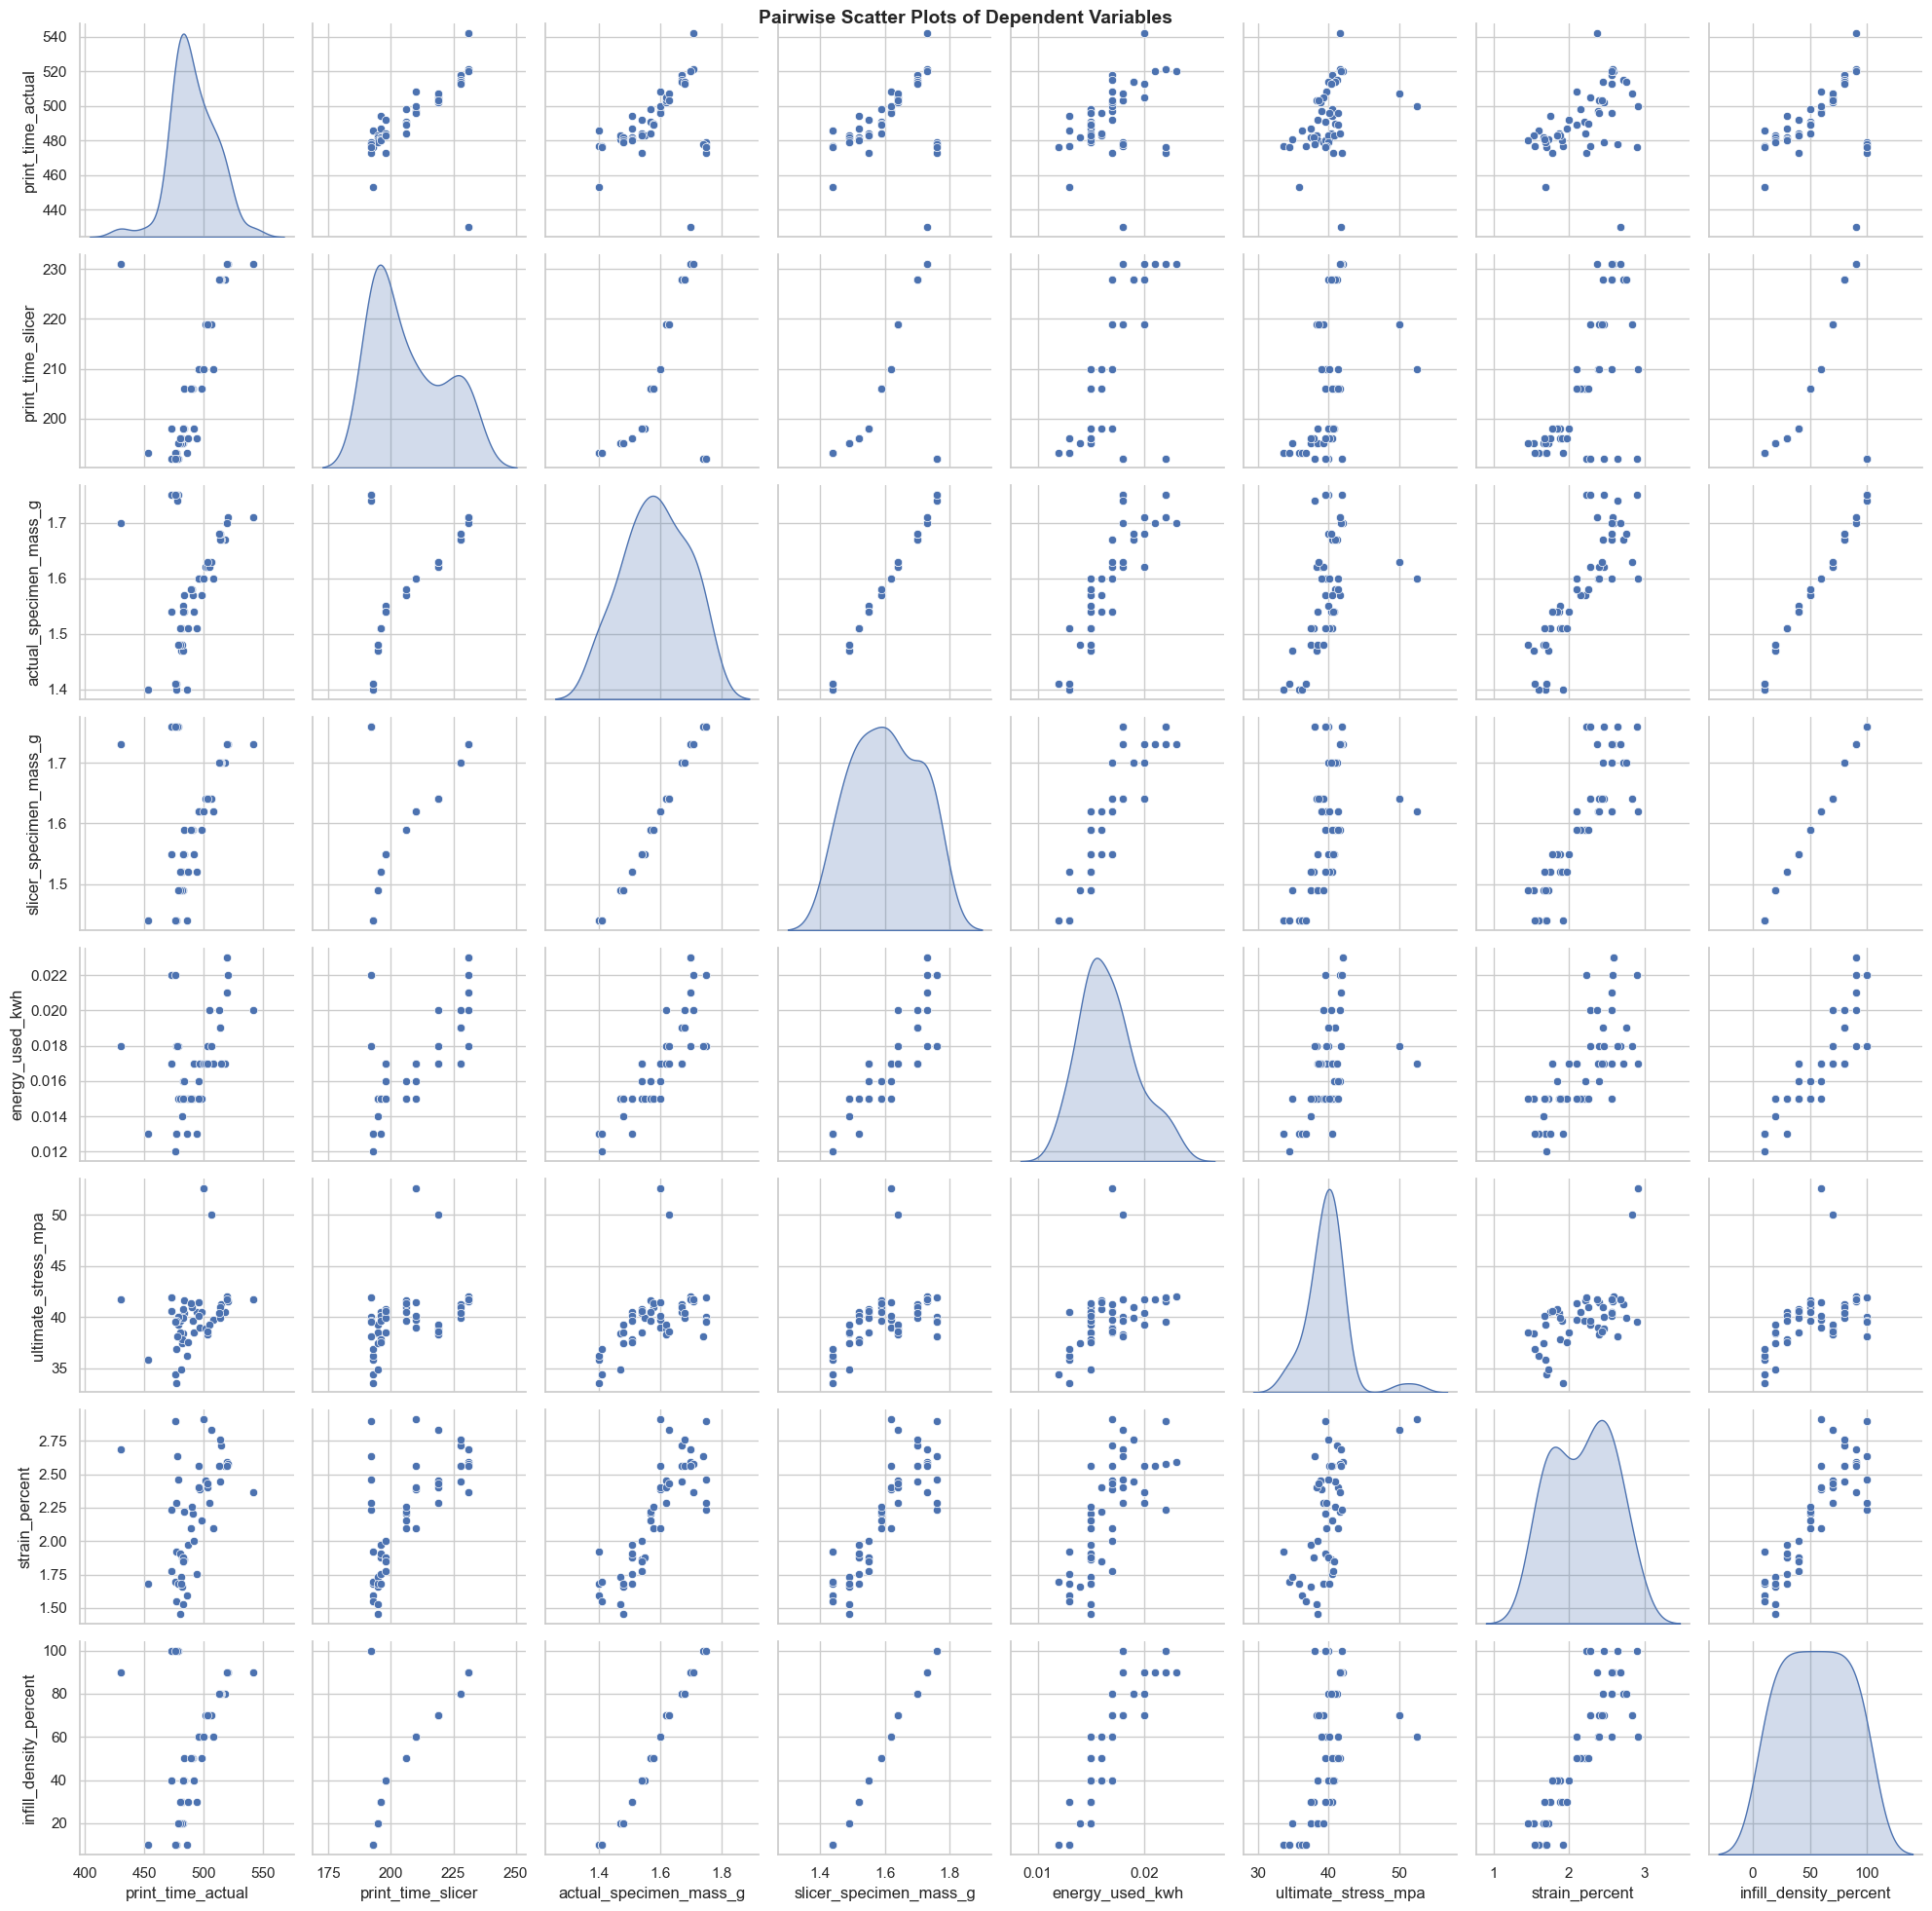

In [ ]:
# Pairwise Scatter Plots of Dependent Variables colored by Infill Density
sns.pairplot(df[dep_vars + indep_vars], diag_kind='kde')
plt.suptitle('Pairwise Scatter Plots of Dependent Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase IV - Grouped Performance Analysis

### 4.1 Compute Statistical Summaries of the Average Dataset

In [ ]:
avg_df[dep_res_vars + dep_mech_vars + indep_vars].describe()

,print_time_actual,actual_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,infill_density_percent
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,491.440000,1.585600,0.016660,39.877734,2.181942,55.000000
std,13.957969,0.106787,0.002491,2.091618,0.392003,30.276504
min,473.800000,1.404000,0.012800,35.358240,1.610488,10.000000
25%,481.500000,1.518000,0.014900,39.292555,1.846645,32.500000
50%,487.600000,1.587000,0.016200,40.317830,2.328959,55.000000
75%,502.850000,1.661500,0.018300,40.957250,2.497124,77.500000
max,514.800000,1.748000,0.020800,42.576940,2.609872,100.000000


### 4.2 Coeficient of Variation of the Dataset

In [ ]:
# Coefficient of Variation of the Dependent Resource Variable
dep_vars_df = df[dep_res_vars + dep_mech_vars]

# CV = (Standard Deviation / Mean) × 100
cv_values = (dep_vars_df.std() / dep_vars_df.mean()) * 100

# Create a DataFrame for better visualization
cv_df = pd.DataFrame({
    'Column': cv_values.index,
    'CV (%)': cv_values.values
}).sort_values('CV (%)', ascending=False)

print("Coefficient of Variation (%) by Column:")
print(cv_df.to_string(index=False))
print("\nStatistics:")
print(f"Mean CV: {cv_values.mean():.2f}%")
print(f"Max CV: {cv_values.max():.2f}% ({cv_values.idxmax()})")
print(f"Min CV: {cv_values.min():.2f}% ({cv_values.idxmin()})")

Coefficient of Variation (%) by Column:
                Column    CV (%)
        strain_percent 18.623243
       energy_used_kwh 15.793111
   ultimate_stress_mpa  7.761840
actual_specimen_mass_g  6.459567
     print_time_actual  3.861303

Statistics:
Mean CV: 10.50%
Max CV: 18.62% (strain_percent)
Min CV: 3.86% (print_time_actual)


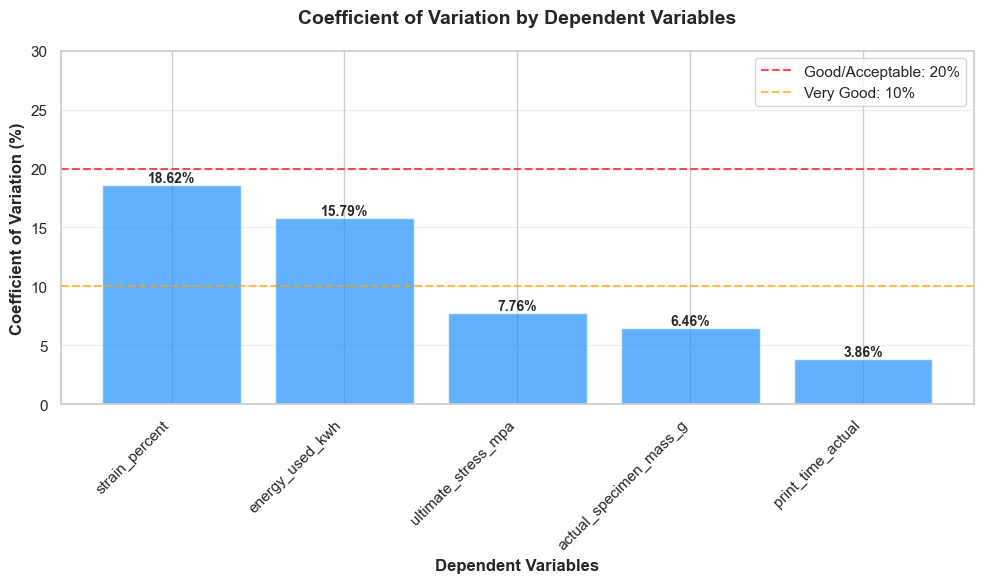

In [ ]:
# Create a Bar Graph of the Coefficient of Variation

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(cv_df['Column'], cv_df['CV (%)'], color='dodgerblue', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize the chart
ax.set_xlabel('Dependent Variables', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax.set_title('Coefficient of Variation by Dependent Variables', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=20, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Good/Acceptable: 20%')
ax.axhline(y=10, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Very Good: 10%')
ax.legend()
ax.set_ylim(0, 30)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


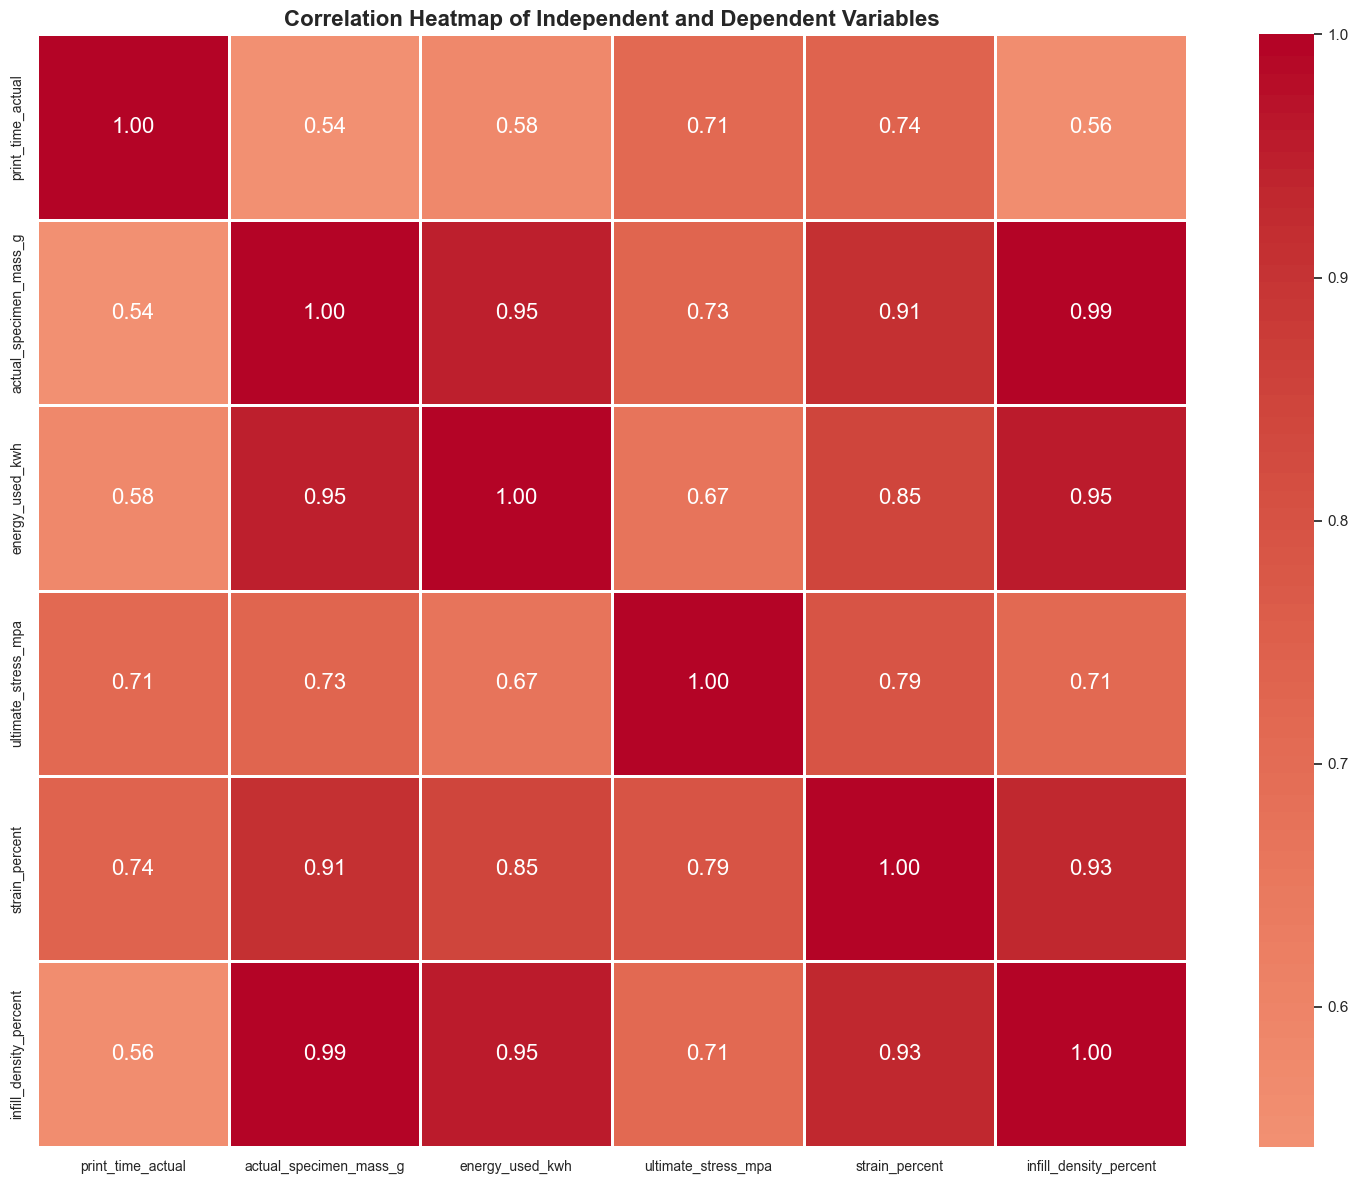

P-values:
                        print_time_actual  actual_specimen_mass_g  \
print_time_actual                  1.0000                  0.1052   
actual_specimen_mass_g             0.1052                  1.0000   
energy_used_kwh                    0.0761                  0.0000   
ultimate_stress_mpa                0.0202                  0.0168   
strain_percent                     0.0140                  0.0003   
infill_density_percent             0.0919                  0.0000   

                        energy_used_kwh  ultimate_stress_mpa  strain_percent  \
print_time_actual                0.0761               0.0202          0.0140   
actual_specimen_mass_g           0.0000               0.0168          0.0003   
energy_used_kwh                  1.0000               0.0341          0.0020   
ultimate_stress_mpa              0.0341               1.0000          0.0066   
strain_percent                   0.0020               0.0066          1.0000   
infill_density_percent    

In [ ]:
# Correlation Heatmap between independent and dependent variables
plt.figure(figsize=(15, 12))
corr_matrix = avg_df[dep_res_vars + dep_mech_vars + indep_vars].corr(numeric_only=True)

# Calculate p-values
from scipy.stats import pearsonr
pvalues = pd.DataFrame(1.0, index=corr_matrix.index, columns=corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        if i != j:
            _, pval = pearsonr(avg_df[corr_matrix.columns[i]], avg_df[corr_matrix.columns[j]])
            pvalues.iloc[i, j] = pval

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, center=0, annot_kws={'size': 16})
plt.title('Correlation Heatmap of Independent and Dependent Variables', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Display p-values
print("P-values:")
print(pvalues.round(4))

## Phase V - Statistical Significance Testing

### 5.1 Prepare Data Group

In [ ]:
# Get unique infill density
infill_densities = sorted(df['infill_density_percent'].unique())
print(f'\nInfill density Levels: {infill_densities}')
print(f'Nubmber of infill density levels: {len(infill_densities)}')


Infill density Levels: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]
Nubmber of infill density levels: 10


In [ ]:
mass_g = ['actual_specimen_mass_g']
grouped_data = {}
assumption_results = {}

for dv in dep_vars:
    groups = [
        group[dv].values
        for name, group in df.groupby('infill_density_percent')
    ]
    grouped_data[dv] = groups

for dv in mass_g:
    groups = grouped_data[dv]
    
    # Test for normality (Shapiro-Wilk test)
    normality_p_values = []
    for i, group in enumerate(groups):
        stat, p_value = shapiro(group)
        normality_p_values.append(p_value)
    
    # Test for homogeneity of variance (Levene's test)
    levene_stat, levene_p = levene(*groups)
    
    # Store results
    assumption_results[dv] = {
        'normality_p_values': normality_p_values,
        'levene_p': levene_p,
        'is_normal': all(p > 0.05 for p in normality_p_values),
        'is_homogeneous': levene_p > 0.05
    }
    
    # Print results
    print(f"\n{dv}:")
    print(f"  Normality (Shapiro-Wilk p-values by density):")
    for i, density in enumerate(infill_densities):
        is_normal = "✓ Normal" if normality_p_values[i] > 0.05 else "✗ Not Normal"
        print(f"    {density}%: p={normality_p_values[i]:.4f} {is_normal}")
    
    print(f"  Homogeneity of Variance (Levene's test): p={levene_p:.4f}")
    print(f"    {'✓ Homogeneous' if levene_p > 0.05 else '✗ Not Homogeneous'}")


actual_specimen_mass_g:
  Normality (Shapiro-Wilk p-values by density):
    10%: p=0.0065 ✗ Not Normal
    20%: p=0.0065 ✗ Not Normal
    30%: p=1.0000 ✓ Normal
    40%: p=0.0001 ✗ Not Normal
    50%: p=0.0065 ✗ Not Normal
    60%: p=1.0000 ✓ Normal
    70%: p=0.0065 ✗ Not Normal
    80%: p=0.0065 ✗ Not Normal
    90%: p=0.0065 ✗ Not Normal
    100%: p=0.0001 ✗ Not Normal
  Homogeneity of Variance (Levene's test): p=0.7507
    ✓ Homogeneous


c:\Program Files\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# Create groups for each dependent variable
grouped_data = {}
 
for dv in dep_vars:
    groups = [
        group[dv].values
        for name, group in df.groupby('infill_density_percent')
    ]
    grouped_data[dv] = groups
    print(f"\n{dv}:")
    print(f"  Groups created: {len(groups)}")
    for i, density in enumerate(infill_densities):
        print(f"    Density {density}%: n={len(groups[i])}, mean={np.mean(groups[i]):.4f}, std={np.std(groups[i]):.4f}")


print_time_actual:
  Groups created: 10
    Density 10%: n=5, mean=473.8000, std=11.0164
    Density 20%: n=5, mean=481.0000, std=1.4142
    Density 30%: n=5, mean=484.8000, std=5.1923
    Density 40%: n=5, mean=483.0000, std=6.0332
    Density 50%: n=5, mean=490.4000, std=4.4989
    Density 60%: n=5, mean=499.4000, std=4.5431
    Density 70%: n=5, mean=504.0000, std=1.7889
    Density 80%: n=5, mean=514.8000, std=1.7205
    Density 90%: n=5, mean=506.6000, std=39.2102
    Density 100%: n=5, mean=476.6000, std=2.0591

print_time_slicer:
  Groups created: 10
    Density 10%: n=5, mean=193.0000, std=0.0000
    Density 20%: n=5, mean=195.0000, std=0.0000
    Density 30%: n=5, mean=196.0000, std=0.0000
    Density 40%: n=5, mean=198.0000, std=0.0000
    Density 50%: n=5, mean=206.0000, std=0.0000
    Density 60%: n=5, mean=210.0000, std=0.0000
    Density 70%: n=5, mean=219.0000, std=0.0000
    Density 80%: n=5, mean=228.0000, std=0.0000
    Density 90%: n=5, mean=231.0000, std=0.0000
   

 ### 5.2 Normality and Homogeneity Test

In [ ]:
assumption_results = {}
 
for dv in dep_res_vars:
    groups = grouped_data[dv]
    
    # Test for normality (Shapiro-Wilk test)
    normality_p_values = []
    for i, group in enumerate(groups):
        stat, p_value = shapiro(group)
        normality_p_values.append(p_value)
    
    # Test for homogeneity of variance (Levene's test)
    levene_stat, levene_p = levene(*groups)
    
    # Store results
    assumption_results[dv] = {
        'normality_p_values': normality_p_values,
        'levene_p': levene_p,
        'is_normal': all(p > 0.05 for p in normality_p_values),
        'is_homogeneous': levene_p > 0.05
    }
    
    # Print results
    print(f"\n{dv}:")
    print(f"  Normality (Shapiro-Wilk p-values by density):")
    for i, density in enumerate(infill_densities):
        is_normal = "✓ Normal" if normality_p_values[i] > 0.05 else "✗ Not Normal"
        print(f"    {density}%: p={normality_p_values[i]:.4f} {is_normal}")
    
    print(f"  Homogeneity of Variance (Levene's test): p={levene_p:.4f}")
    print(f"    {'✓ Homogeneous' if levene_p > 0.05 else '✗ Not Homogeneous'}")


print_time_actual:
  Normality (Shapiro-Wilk p-values by density):
    10%: p=0.0981 ✓ Normal
    20%: p=0.9672 ✓ Normal
    30%: p=0.2204 ✓ Normal
    40%: p=0.4677 ✓ Normal
    50%: p=0.7131 ✓ Normal
    60%: p=0.0495 ✗ Not Normal
    70%: p=0.4399 ✓ Normal
    80%: p=0.2230 ✓ Normal
    90%: p=0.0174 ✗ Not Normal
    100%: p=0.6853 ✓ Normal
  Homogeneity of Variance (Levene's test): p=0.3096
    ✓ Homogeneous

actual_specimen_mass_g:
  Normality (Shapiro-Wilk p-values by density):
    10%: p=0.0065 ✗ Not Normal
    20%: p=0.0065 ✗ Not Normal
    30%: p=1.0000 ✓ Normal
    40%: p=0.0001 ✗ Not Normal
    50%: p=0.0065 ✗ Not Normal
    60%: p=1.0000 ✓ Normal
    70%: p=0.0065 ✗ Not Normal
    80%: p=0.0065 ✗ Not Normal
    90%: p=0.0065 ✗ Not Normal
    100%: p=0.0001 ✗ Not Normal
  Homogeneity of Variance (Levene's test): p=0.7507
    ✓ Homogeneous

energy_used_kwh:
  Normality (Shapiro-Wilk p-values by density):
    10%: p=0.0001 ✗ Not Normal
    20%: p=0.0001 ✗ Not Normal
    30%: 

In [ ]:
assumption_results = {}
 
for dv in dep_mech_vars:
    groups = grouped_data[dv]
    
    # Test for normality (Shapiro-Wilk test)
    normality_p_values = []
    for i, group in enumerate(groups):
        stat, p_value = shapiro(group)
        normality_p_values.append(p_value)
    
    # Test for homogeneity of variance (Levene's test)
    levene_stat, levene_p = levene(*groups)
    
    # Store results
    assumption_results[dv] = {
        'normality_p_values': normality_p_values,
        'levene_p': levene_p,
        'is_normal': all(p > 0.05 for p in normality_p_values),
        'is_homogeneous': levene_p > 0.05
    }
    
    # Print results
    print(f"\n{dv}:")
    print(f"  Normality (Shapiro-Wilk p-values by density):")
    for i, density in enumerate(infill_densities):
        is_normal = "✓ Normal" if normality_p_values[i] > 0.05 else "✗ Not Normal"
        print(f"    {density}%: p={normality_p_values[i]:.4f} {is_normal}")
    
    print(f"  Homogeneity of Variance (Levene's test): p={levene_p:.4f}")
    print(f"    {'✓ Homogeneous' if levene_p > 0.05 else '✗ Not Homogeneous'}")


ultimate_stress_mpa:
  Normality (Shapiro-Wilk p-values by density):
    10%: p=0.6813 ✓ Normal
    20%: p=0.2377 ✓ Normal
    30%: p=0.2726 ✓ Normal
    40%: p=0.1293 ✓ Normal
    50%: p=0.7418 ✓ Normal
    60%: p=0.0080 ✗ Not Normal
    70%: p=0.0011 ✗ Not Normal
    80%: p=0.9104 ✓ Normal
    90%: p=0.7459 ✓ Normal
    100%: p=0.6663 ✓ Normal
  Homogeneity of Variance (Levene's test): p=0.6529
    ✓ Homogeneous

strain_percent:
  Normality (Shapiro-Wilk p-values by density):
    10%: p=0.3856 ✓ Normal
    20%: p=0.5305 ✓ Normal
    30%: p=0.6770 ✓ Normal
    40%: p=0.5711 ✓ Normal
    50%: p=0.7733 ✓ Normal
    60%: p=0.8287 ✓ Normal
    70%: p=0.1353 ✓ Normal
    80%: p=0.5934 ✓ Normal
    90%: p=0.3115 ✓ Normal
    100%: p=0.6522 ✓ Normal
  Homogeneity of Variance (Levene's test): p=0.4055
    ✓ Homogeneous


### 5.3 ANOVA and Kruskal-Wallis Test

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

# ANOVA: Testing if infill_density_percent significantly affects dependent variables

# Get unique infill density groups
groups = sorted(df['infill_density_percent'].dropna().unique())

# Perform ANOVA for each dependent variable
anova_results = {}

for dep_var in dep_res_vars + dep_mech_vars:
    # Create groups of data for each infill density level
    group_data = []
    for group in groups:
        data = df[df['infill_density_percent'] == group][dep_var].dropna().values
        if len(data) > 0:
            group_data.append(data)
    
    # Perform ANOVA
    if len(group_data) >= 2:
        f_stat, p_value = stats.f_oneway(*group_data)
        anova_results[dep_var] = {'F-statistic': f_stat, 'p-value': p_value}

# ANOVA Summary Table
print("="*80)
print("ANOVA Results: Infill Density Percent vs Dependent Variables")
print("="*80)
anova_df = pd.DataFrame(anova_results).T
anova_df.columns = ['F-statistic', 'p-value']
print(anova_df.to_string(float_format=lambda x: f'{x:.10f}'))

ANOVA Results: Infill Density Percent vs Dependent Variables
                           F-statistic      p-value
print_time_actual         4.3893319715 0.0004945753
actual_specimen_mass_g 2591.6767676768 0.0000000000
energy_used_kwh          20.6829629630 0.0000000000
ultimate_stress_mpa       3.2099940707 0.0051247660
strain_percent           26.1372505433 0.0000000000


In [ ]:
print("\n" + "="*100)
print("STEP 5: CORRELATION ANALYSIS")
print("="*100)
print("\nMeasuring strength of relationship between infill density and each DV:")
 
correlation_results = {}
 
for dv in dep_vars:
    # Create numeric infill density values
    infill_numeric = df['infill_density_percent'].values
    dv_values = df[dv].values
    
    # Calculate Pearson and Spearman correlation
    pearson_r, pearson_p = stats.pearsonr(infill_numeric, dv_values)
    spearman_r, spearman_p = stats.spearmanr(infill_numeric, dv_values)
    
    correlation_results[dv] = {
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p
    }
    
    print(f"\n{dv}:")
    print(f"  Pearson Correlation: r={pearson_r:.4f}, p={pearson_p:.6f}")
    if abs(pearson_r) < 0.3:
        strength = "weak"
    elif abs(pearson_r) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if pearson_r > 0 else "negative"
    print(f"    → {strength.upper()} {direction} correlation")
    
    print(f"  Spearman Correlation: ρ={spearman_r:.4f}, p={spearman_p:.6f}")
    print(f"    → {strength.upper()} {direction} correlation")


STEP 5: CORRELATION ANALYSIS

Measuring strength of relationship between infill density and each DV:

print_time_actual:
  Pearson Correlation: r=0.3951, p=0.004513
    → MODERATE positive correlation
  Spearman Correlation: ρ=0.3983, p=0.004178
    → MODERATE positive correlation

print_time_slicer:
  Pearson Correlation: r=0.5878, p=0.000007
    → MODERATE positive correlation
  Spearman Correlation: ρ=0.4545, p=0.000913
    → MODERATE positive correlation

actual_specimen_mass_g:
  Pearson Correlation: r=0.9930, p=0.000000
    → STRONG positive correlation
  Spearman Correlation: ρ=0.9973, p=0.000000
    → STRONG positive correlation

slicer_specimen_mass_g:
  Pearson Correlation: r=0.9975, p=0.000000
    → STRONG positive correlation
  Spearman Correlation: ρ=1.0000, p=0.000000
    → STRONG positive correlation

energy_used_kwh:
  Pearson Correlation: r=0.8648, p=0.000000
    → STRONG positive correlation
  Spearman Correlation: ρ=0.9062, p=0.000000
    → STRONG positive correlati

In [ ]:
df[(indep_vars + dep_vars)].head(50)


,infill_density_percent,print_time_actual,print_time_slicer,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent
0,10,453.0,193.0,1.40,1.44,0.013,35.8098,1.68293
1,10,477.0,193.0,1.40,1.44,0.013,33.5701,1.92406
2,10,486.0,193.0,1.40,1.44,0.013,36.1737,1.59461
3,10,477.0,193.0,1.41,1.44,0.013,36.8314,1.54971
4,10,476.0,193.0,1.41,1.44,0.012,34.4062,1.69792
5,20,481.0,195.0,1.47,1.49,0.015,34.8242,1.72938
6,20,483.0,195.0,1.47,1.49,0.015,38.3593,1.52727
7,20,482.0,195.0,1.48,1.49,0.014,37.4826,1.65602
8,20,480.0,195.0,1.48,1.49,0.015,38.4941,1.45683
9,20,479.0,195.0,1.48,1.49,0.015,39.2604,1.68294


### Data Normalization (MIN-MAX)

In [ ]:
# ============================================================================
# NORMALIZED INFILL DENSITY TABLE
# ============================================================================
 
# Define variables
indep_vars = ['infill_density_percent']
 
# Resource variables to minimize
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']
 
# Mechanical variables to maximize
dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']
 
 
# ============================================================================
# CREATE NORMALIZED TABLE FOR MECHANICAL & RESOURCE PARAMETERS
# ============================================================================
 
normalized_params_df = pd.DataFrame()
 
# Keep original infill density
normalized_params_df['Infill Density (%)'] = avg_df['infill_density_percent'].values
 
# Resource variables (minimize - invert normalization: 1 - normalized)
print("Normalizing Resource Parameters (Lower is Better)...")
for var in dep_res_vars:
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    normalized_params_df[f'{var}_norm'] = (
        1 - (avg_df[var] - min_val) / (max_val - min_val)
    ).round(4)
 
# Mechanical variables (maximize - normal normalization)
print("Normalizing Mechanical Properties (Higher is Better)...")
for var in dep_mech_vars:
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    normalized_params_df[f'{var}_norm'] = (
        (avg_df[var] - min_val) / (max_val - min_val)
    ).round(4)
 
# Sort by infill density
normalized_params_df = normalized_params_df.sort_values('Infill Density (%)').reset_index(drop=True)
 
print("\n" + "="*100)
print("NORMALIZED MECHANICAL PROPERTIES & RESOURCE PARAMETERS")
print("="*100 + "\n")
print("Resource Variables (Normalized: 1 = Best, 0 = Worst):")
print("  - print_time_actual_norm")
print("  - actual_specimen_mass_g_norm")
print("  - energy_used_kwh_norm")
print("\nMechanical Variables (Normalized: 1 = Best, 0 = Worst):")
print("  - ultimate_stress_mpa_norm")
print("  - strain_percent_norm")
print("\n" + "-"*100 + "\n")
display(normalized_params_df)

Normalizing Resource Parameters (Lower is Better)...
Normalizing Mechanical Properties (Higher is Better)...

NORMALIZED MECHANICAL PROPERTIES & RESOURCE PARAMETERS

Resource Variables (Normalized: 1 = Best, 0 = Worst):
  - print_time_actual_norm
  - actual_specimen_mass_g_norm
  - energy_used_kwh_norm

Mechanical Variables (Normalized: 1 = Best, 0 = Worst):
  - ultimate_stress_mpa_norm
  - strain_percent_norm

----------------------------------------------------------------------------------------------------



,Infill Density (%),print_time_actual_norm,actual_specimen_mass_g_norm,energy_used_kwh_norm,ultimate_stress_mpa_norm,strain_percent_norm
0,10,1.0000,1.0000,1.000,0.0000,0.0794
1,20,0.8244,0.7907,0.750,0.3222,0.0000
2,30,0.7317,0.6919,0.775,0.5202,0.2278
3,40,0.7756,0.5988,0.600,0.6459,0.2619
4,50,0.5951,0.5058,0.700,0.7550,0.5763
5,60,0.3756,0.4302,0.550,1.0000,0.8616
6,70,0.2634,0.3605,0.350,0.7825,0.8714
7,80,0.0000,0.2151,0.300,0.7282,1.0000
8,90,0.2000,0.1279,0.000,0.8874,0.9473
9,100,0.9317,0.0000,0.150,0.6194,0.8924


### Max Standardization

In [ ]:
# ============================================================================
# CREATE NORMALIZED TABLE FOR MECHANICAL & RESOURCE PARAMETERS (TWEAKED)
# ============================================================================
 
max_normalized_params_df = pd.DataFrame()
 
# Keep original infill density
max_normalized_params_df['Infill Density (%)'] = avg_df['infill_density_percent'].values
 
# Resource variables (minimize - TWEAKED: min_val / actual_val)
print("Normalizing Resource Parameters via Max-Standardization (Lower is Better)...")
for var in dep_res_vars:
    min_val = avg_df[var].min()
    # No range subtraction: directly divides the absolute minimum by the group average
    max_normalized_params_df[f'{var}_norm'] = (
        min_val / avg_df[var]
    ).round(4)
 
# Mechanical variables (maximize - TWEAKED: actual_val / max_val)
print("Normalizing Mechanical Properties via Max-Standardization (Higher is Better)...")
for var in dep_mech_vars:
    max_val = avg_df[var].max()
    # No range subtraction: directly divides the group average by the absolute maximum
    max_normalized_params_df[f'{var}_norm'] = (
        avg_df[var] / max_val
    ).round(4)
 
# Sort by infill density
max_normalized_params_df = max_normalized_params_df.sort_values('Infill Density (%)').reset_index(drop=True)
 
print("\n" + "="*100)
print("NORMALIZED MECHANICAL PROPERTIES & RESOURCE PARAMETERS")
print("="*100 + "\n")
print("Resource Variables (Normalized: 1 = Best, 0 = Worst):")
print("  - print_time_actual_norm")
print("  - actual_specimen_mass_g_norm")
print("  - energy_used_kwh_norm")
print("\nMechanical Variables (Normalized: 1 = Best, 0 = Worst):")
print("  - ultimate_stress_mpa_norm")
print("  - strain_percent_norm")
print("\n" + "-"*100 + "\n")
display(max_normalized_params_df)

Normalizing Resource Parameters via Max-Standardization (Lower is Better)...
Normalizing Mechanical Properties via Max-Standardization (Higher is Better)...

NORMALIZED MECHANICAL PROPERTIES & RESOURCE PARAMETERS

Resource Variables (Normalized: 1 = Best, 0 = Worst):
  - print_time_actual_norm
  - actual_specimen_mass_g_norm
  - energy_used_kwh_norm

Mechanical Variables (Normalized: 1 = Best, 0 = Worst):
  - ultimate_stress_mpa_norm
  - strain_percent_norm

----------------------------------------------------------------------------------------------------



,Infill Density (%),print_time_actual_norm,actual_specimen_mass_g_norm,energy_used_kwh_norm,ultimate_stress_mpa_norm,strain_percent_norm
0,10,1.0000,1.0000,1.0000,0.8305,0.6475
1,20,0.9850,0.9512,0.8649,0.8851,0.6171
2,30,0.9773,0.9298,0.8767,0.9187,0.7043
3,40,0.9810,0.9105,0.8000,0.9400,0.7174
4,50,0.9662,0.8920,0.8421,0.9585,0.8377
5,60,0.9487,0.8775,0.7805,1.0000,0.9470
6,70,0.9401,0.8645,0.7111,0.9631,0.9508
7,80,0.9204,0.8387,0.6957,0.9539,1.0000
8,90,0.9353,0.8239,0.6154,0.9809,0.9798
9,100,0.9941,0.8032,0.6531,0.9355,0.9588


In [ ]:
# ============================================================================
# COMPUTE WEIGHTED SCORES USING MAX-STANDARDIZATION
# ============================================================================

scores_df = pd.DataFrame()
scores_df['Infill Density (%)'] = max_normalized_params_df['Infill Density (%)'].values

# --- 1. Mechanical Score Calculation (50% Cumulative Weight) ---
# Sums the pre-calculated normalized columns from max_normalized_params_df
mechanical_score = pd.Series([0.0] * len(max_normalized_params_df))
for var in dep_mech_vars:
    # Pulls directly from your max-standardized dataframe columns
    mechanical_score += 0.25 * max_normalized_params_df[f'{var}_norm']

scores_df['Mechanical Score (50%)'] = mechanical_score.round(4)


# --- 2. Resource Score Calculation (50% Cumulative Weight) ---
# Sums the pre-calculated normalized columns from max_normalized_params_df
resource_score = pd.Series([0.0] * len(max_normalized_params_df))
for var in dep_res_vars:
    # Pulls directly from your max-standardized dataframe columns
    resource_score += (0.50 / 3) * max_normalized_params_df[f'{var}_norm']

scores_df['Resource Score (50%)'] = resource_score.round(4)


# --- 3. Overall Cumulative Score ---
# Summing the pre-factored sub-scores to hit a clean 1.0 maximum target ceiling
overall_score = mechanical_score + resource_score
scores_df['Overall Score'] = overall_score.round(4)


# --- 4. Final Ranks Generation ---
# Generates final optimization ranks where the highest score is Rank 1
scores_df['Rank'] = scores_df['Overall Score'].rank(ascending=False, method='min').astype(int)

# Sort strictly by infill density for a clean slide layout
scores_df = scores_df.sort_values('Infill Density (%)').reset_index(drop=True)

print("\n" + "="*100)
print("FINAL STABILIZED MCDA SCORES & RANKS (MAX-STANDARDIZATION)")
print("="*100 + "\n")
display(scores_df)


FINAL STABILIZED MCDA SCORES & RANKS (MAX-STANDARDIZATION)



,Infill Density (%),Mechanical Score (50%),Resource Score (50%),Overall Score,Rank
0,10,0.3695,0.5000,0.8695,8
1,20,0.3756,0.4668,0.8424,10
2,30,0.4058,0.4640,0.8697,7
3,40,0.4144,0.4486,0.8629,9
4,50,0.4490,0.4500,0.8991,2
5,60,0.4868,0.4344,0.9212,1
6,70,0.4785,0.4193,0.8978,3
7,80,0.4885,0.4091,0.8976,4
8,90,0.4902,0.3958,0.8859,5
9,100,0.4736,0.4084,0.8820,6


In [ ]:
# Define variables
indep_vars = ['infill_density_percent']

# Resource variables to minimize
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']

# Mechanical variables to maximize
dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']

# Compute weighted scores
scores_df = pd.DataFrame()
scores_df['Infill Density (%)'] = avg_df['infill_density_percent'].values

# Mechanical Score (50% weight)
mechanical_score = pd.Series([0.0] * len(avg_df))
for var in dep_mech_vars:
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    normalized = (avg_df[var] - min_val) / (max_val - min_val)
    mechanical_score += 0.5 * normalized

scores_df['Mechanical Score (50%)'] = mechanical_score.round(4)

# Resource Score (50% weight)
resource_score = pd.Series([0.0] * len(avg_df))
for var in dep_res_vars:
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    normalized = 1 - (avg_df[var] - min_val) / (max_val - min_val)
    resource_score += (1/3) * normalized

scores_df['Resource Score (50%)'] = resource_score.round(4)

# Overall Score (50% Mechanical + 50% Resource)
overall_score = (0.50 * mechanical_score) + (0.50 * resource_score)
scores_df['Overall Score'] = overall_score.round(4)

# Sort by infill density
scores_df = scores_df.sort_values('Infill Density (%)').reset_index(drop=True)

# Display the table
display(scores_df)

,Infill Density (%),Mechanical Score (50%),Resource Score (50%),Overall Score
0,10,0.0397,1.0000,0.5199
1,20,0.1611,0.7884,0.4747
2,30,0.3740,0.7329,0.5534
3,40,0.4539,0.6581,0.5560
4,50,0.6656,0.6003,0.6330
5,60,0.9308,0.4519,0.6914
6,70,0.8270,0.3246,0.5758
7,80,0.8641,0.1717,0.5179
8,90,0.9174,0.1093,0.5133
9,100,0.7559,0.3606,0.5582


--- Pairwise Dominance Matrix Table ---


,10,20,30,40,50,60,70,80,90,100
Infill (%),,,,,,,,,,
10,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
20,Non-Dominated,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
30,Non-Dominated,Non-Dominated,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
40,Non-Dominated,Non-Dominated,Non-Dominated,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
50,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
60,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,—,Dominates,Dominates,Dominates,Dominates
70,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Defeated,—,Non-Dominated,Non-Dominated,Non-Dominated
80,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Defeated,Non-Dominated,—,Non-Dominated,Non-Dominated
90,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Defeated,Non-Dominated,Non-Dominated,—,Non-Dominated


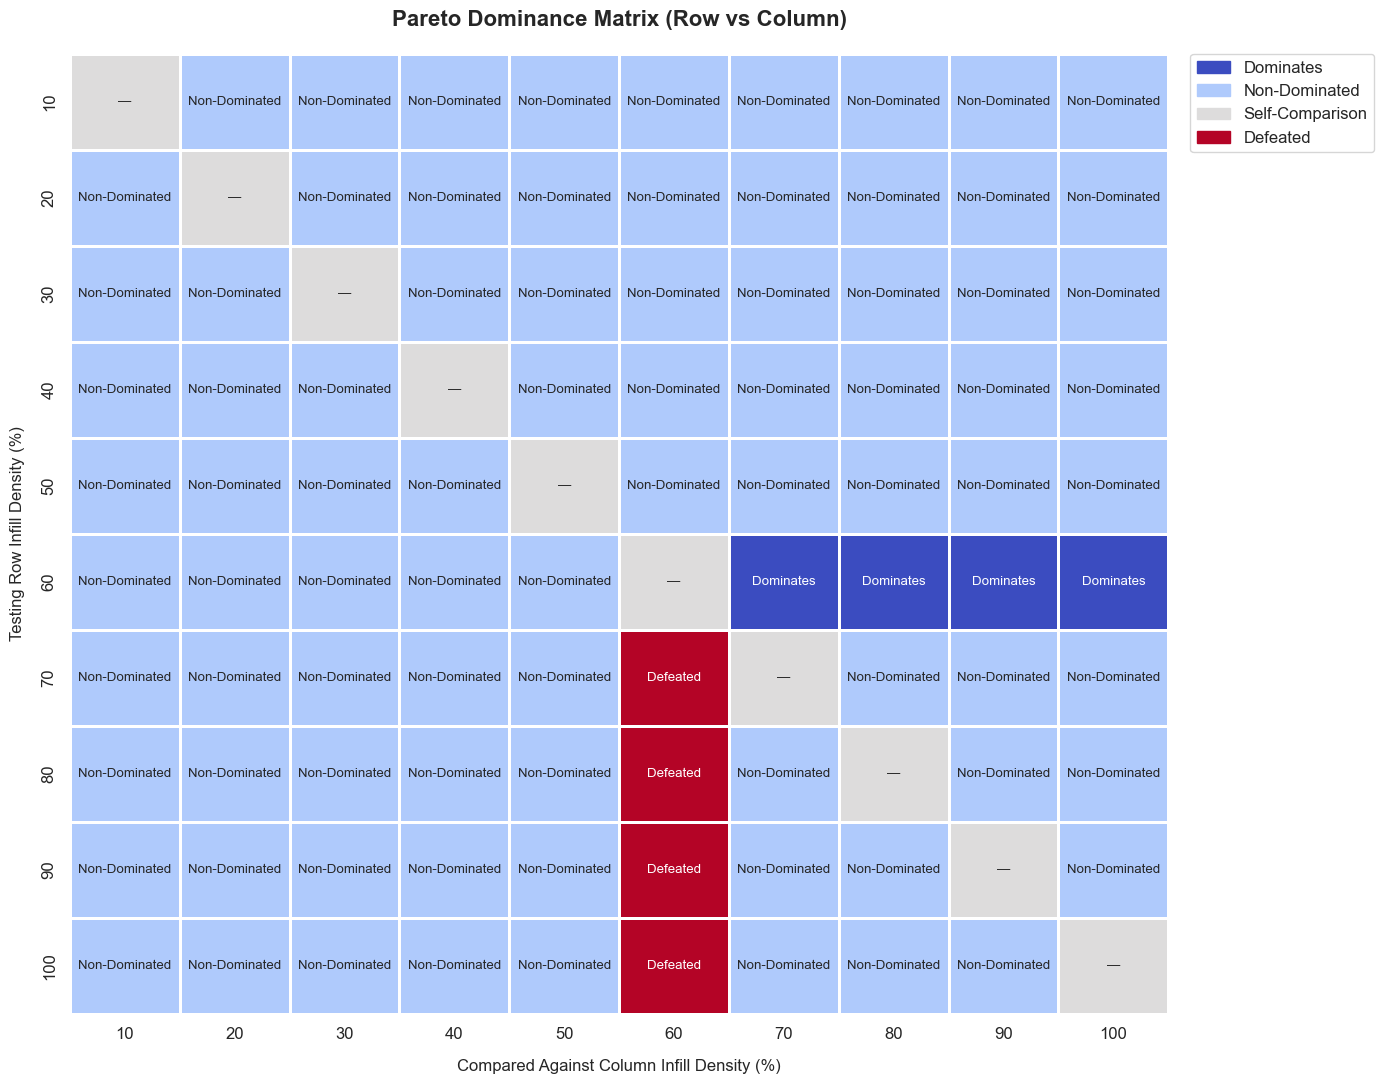

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Extract the normalized scores from your existing scores_df
infills = scores_df['Infill Density (%)'].values
mech_scores = scores_df['Mechanical Score (50%)'].values
res_scores = scores_df['Resource Score (50%)'].values
n = len(infills)

# 2. Initialize arrays for full text categories and numeric color codes
# We re-index the integers to map cleanly onto a coolwarm gradient space
# 0.0 = Dominates (Deep Blue), 0.35 = Non-Dominated (Soft Light Blue/Gray)
# 0.5 = Self (Neutral Light), 1.0 = Defeated (Deep Red)
dominance_numeric = np.zeros((n, n))
dominance_text = np.empty((n, n), dtype=object)

for i in range(n):
    for j in range(n):
        if i == j:
            dominance_text[i, j] = "—"
            dominance_numeric[i, j] = 0.5  # Neutral center of coolwarm
            continue
        
        # Alternative A (Row i) vs Alternative B (Column j)
        a_dominates_b = (
            (mech_scores[i] >= mech_scores[j] and res_scores[i] > res_scores[j]) or
            (mech_scores[i] > mech_scores[j] and res_scores[i] >= res_scores[j])
        )
        
        b_dominates_a = (
            (mech_scores[j] >= mech_scores[i] and res_scores[j] > res_scores[i]) or
            (mech_scores[j] > mech_scores[i] and res_scores[j] >= res_scores[i])
        )
        
        if a_dominates_b:
            dominance_text[i, j] = "Dominates"
            dominance_numeric[i, j] = 0.0   # Cool Anchor
        elif b_dominates_a:
            dominance_text[i, j] = "Defeated"
            dominance_numeric[i, j] = 1.0   # Warm Anchor
        else:
            dominance_text[i, j] = "Non-Dominated"
            dominance_numeric[i, j] = 0.35  # Transition Cool-Neutral

# 3. Create DataFrame for clean text display in Jupyter
matrix_df = pd.DataFrame(dominance_text, index=infills, columns=infills)
matrix_df.index.name = "Infill (%)"

print("--- Pairwise Dominance Matrix Table ---")
display(matrix_df)

# 4. Generate the Categorical Visual Heatmap using 'coolwarm'
plt.figure(figsize=(14, 11))

# We set vmin=0 and vmax=1 to map our explicit anchors perfectly to the coolwarm spectrum
ax = sns.heatmap(
    dominance_numeric, 
    annot=dominance_text, 
    fmt="", 
    cmap="coolwarm", 
    vmin=0,
    vmax=1,
    cbar=False,
    xticklabels=infills, 
    yticklabels=infills,
    linewidths=1,
    annot_kws={"size": 9.5}
)

ax.tick_params(axis='both', which='major', labelsize=12)

# 5. Build an explicit color legend panel sampled from the coolwarm space
# Fetching the exact hex colors extracted by the colormap bounds for consistency
cmap_sample = plt.cm.coolwarm([0.0, 0.35, 0.5, 1.0])
colors_hex = [plt.cm.colors.to_hex(c) for c in cmap_sample]

labels = ["Dominates", "Non-Dominated", "Self-Comparison", "Defeated"]
# Reordering legend logically for the reader
legend_order = [0, 1, 2, 3] 

patches = [mpatches.Patch(color=colors_hex[k], label=labels[k]) for k in legend_order]
plt.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=12)

plt.title("Pareto Dominance Matrix (Row vs Column)", fontsize=16, pad=20, weight='bold')
plt.xlabel("Compared Against Column Infill Density (%)", fontsize=12, labelpad=12)
plt.ylabel("Testing Row Infill Density (%)", fontsize=12, labelpad=12)
plt.tight_layout()
plt.show()

In [ ]:
avg_df.head(10)

,infill_density_percent,print_time_actual,print_time_slicer,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,percent_error,percent_error_mass
0,10,473.8,193.0,1.404,1.44,0.0128,35.35824,1.689846,145.492228,-2.500000
1,20,481.0,195.0,1.476,1.49,0.0148,37.68412,1.610488,146.666667,-0.939597
2,30,484.8,196.0,1.510,1.52,0.0146,39.11364,1.838116,147.346939,-0.657895
3,40,483.0,198.0,1.542,1.55,0.0160,40.02072,1.872232,143.939394,-0.516129
4,50,490.4,206.0,1.574,1.59,0.0152,40.80806,2.186410,138.058252,-1.006289
5,60,499.4,210.0,1.600,1.62,0.0164,42.57694,2.471508,137.809524,-1.234568
6,70,504.0,219.0,1.624,1.64,0.0180,41.00698,2.481400,130.136986,-0.975610
7,80,514.8,228.0,1.674,1.70,0.0184,40.61494,2.609872,125.789474,-1.529412
8,90,506.6,231.0,1.704,1.73,0.0208,41.76440,2.557180,119.307359,-1.502890
9,100,476.6,192.0,1.748,1.76,0.0196,39.82930,2.502366,148.229167,-0.681818



PARETO FRONT ANALYSIS - RESOURCE vs MECHANICAL PROPERTIES

Weighting Structure (50:50 Balance):
  MECHANICAL PERFORMANCE (50% weight):
    - Ultimate Stress MPa: 50% of mechanical = 25% overall
    - Strain %: 50% of mechanical = 25% overall
  RESOURCE PARAMETERS (50% weight):
    - Print Time: 33.33% of resource = 16.67% overall
    - Energy Used: 33.33% of resource = 16.67% overall
    - Specimen Mass: 33.33% of resource = 16.67% overall

Total Design Points: 10
Pareto Optimal Points: 6
Percentage on Pareto Front: 60.0%

--------------------------------------------------------------------------------
PARETO FRONT DESIGNS (Sorted by Resource Score)
--------------------------------------------------------------------------------

   infill_density_percent  print_time_actual  actual_specimen_mass_g  energy_used_kwh  ultimate_stress_mpa  strain_percent  resource_score  mechanical_score  overall_weighted_score
5                      60              499.4                   1.600          

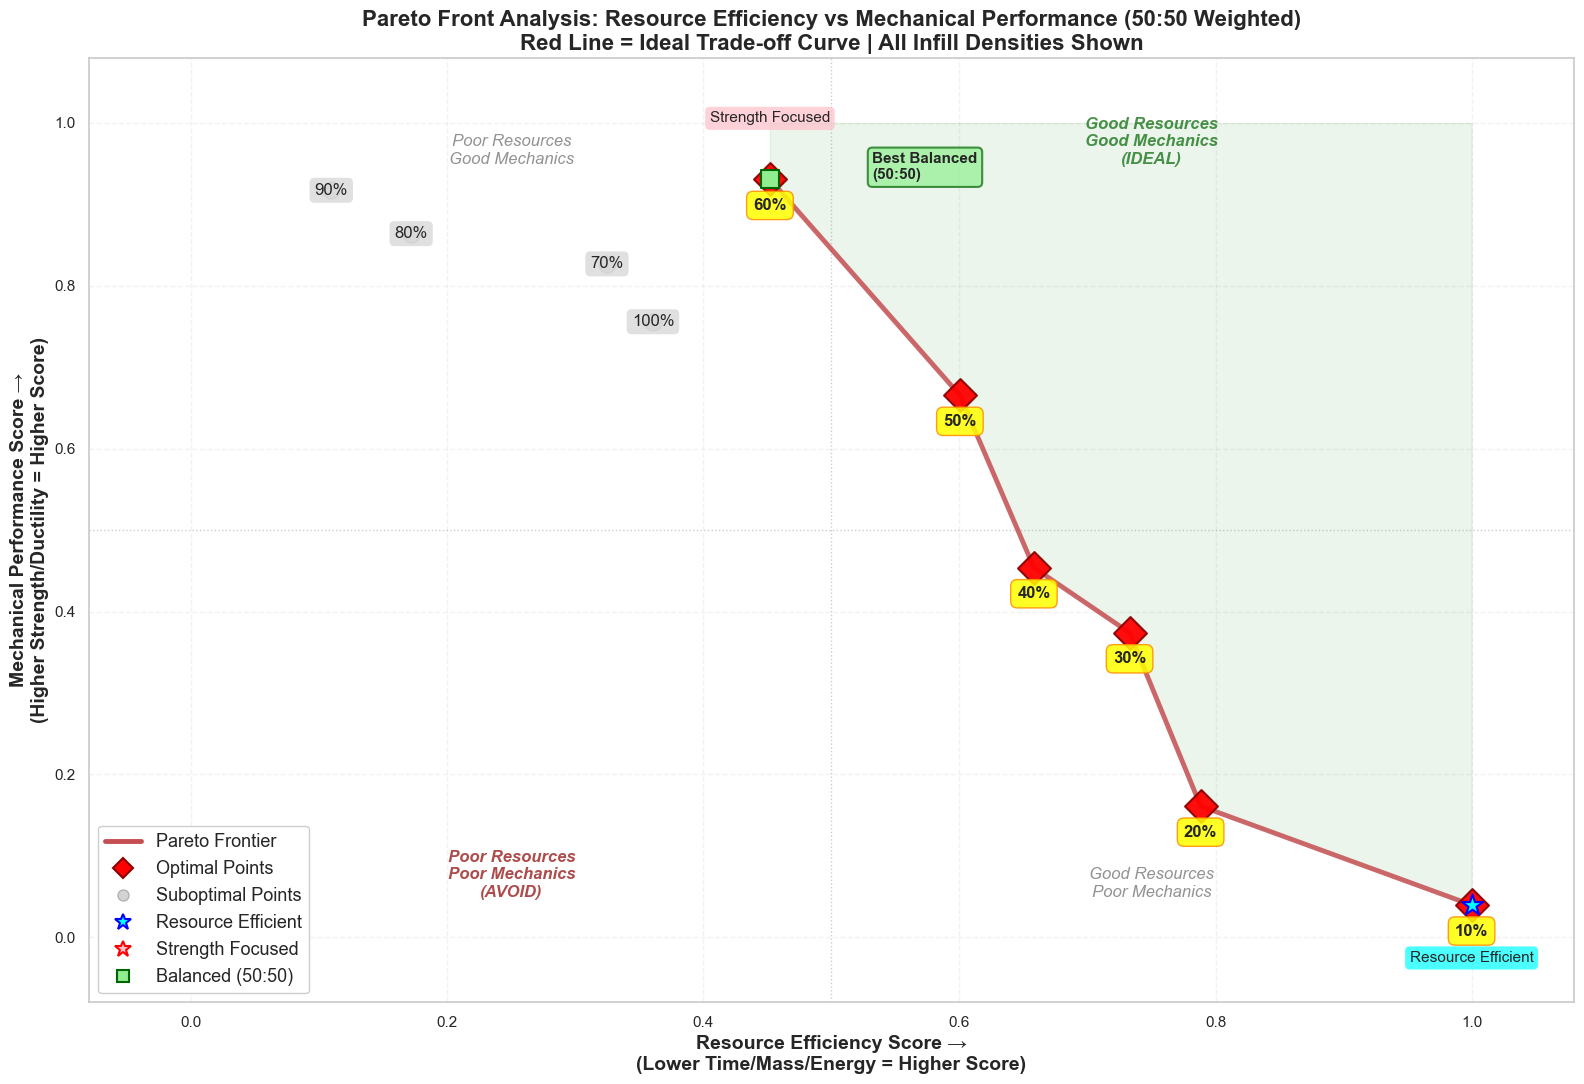

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define variables
indep_vars = ['infill_density_percent']

# Resource variables to minimize
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']

# Mechanical variables to maximize
dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']

# ============================================================================
# NORMALIZATION WITH 50:50 WEIGHTED SCORING
# ============================================================================
# Mechanical Performance: 50% (stress 50% + strain 50%)
# Resource Parameters: 50% (time 1/3 + energy 1/3 + mass 1/3)

# Create normalized dataframe for Pareto front calculation
avg_df_normalized = avg_df.copy()

# Normalize all variables to 0-1 scale (higher is better)
for var in dep_res_vars:
    # For resource variables: lower is better, so invert (1 - normalized)
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    avg_df_normalized[f'{var}_norm'] = 1 - (avg_df[var] - min_val) / (max_val - min_val)

for var in dep_mech_vars:
    # For mechanical variables: higher is better, so normalize directly
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    avg_df_normalized[f'{var}_norm'] = (avg_df[var] - min_val) / (max_val - min_val)

# ============================================================================
# WEIGHTED COMPOSITE SCORES (50% Mechanical / 50% Resource)
# ============================================================================

# MECHANICAL SCORE (50% total weight)
# ultimate_stress_mpa: 50% of mechanical score
# strain_percent: 50% of mechanical score
mechanical_score_raw = (0.5 * avg_df_normalized['ultimate_stress_mpa_norm'] + 
                        0.5 * avg_df_normalized['strain_percent_norm'])
avg_df_normalized['mechanical_score'] = mechanical_score_raw

# RESOURCE SCORE (50% total weight)
# print_time_actual: 1/3 of resource score
# energy_used_kwh: 1/3 of resource score
# actual_specimen_mass_g: 1/3 of resource score
resource_score_raw = ((1/3) * avg_df_normalized['print_time_actual_norm'] + 
                      (1/3) * avg_df_normalized['energy_used_kwh_norm'] + 
                      (1/3) * avg_df_normalized['actual_specimen_mass_g_norm'])
avg_df_normalized['resource_score'] = resource_score_raw

# OVERALL WEIGHTED SCORE
# Mechanical: 50% weight
# Resource: 50% weight
avg_df_normalized['overall_weighted_score'] = (0.50 * mechanical_score_raw + 0.50 * resource_score_raw)

# Identify Pareto front (points where you can't improve one without worsening the other)
def identify_pareto_front(df, objective1, objective2):
    """
    Identify Pareto front points
    Returns boolean mask of Pareto optimal points
    """
    is_pareto = np.ones(df.shape[0], dtype=bool)
    
    for i in range(df.shape[0]):
        for j in range(df.shape[0]):
            if i != j:
                # If point j is better or equal in both objectives, i is not Pareto optimal
                if (df.iloc[j][objective1] >= df.iloc[i][objective1] and 
                    df.iloc[j][objective2] >= df.iloc[i][objective2]):
                    if (df.iloc[j][objective1] > df.iloc[i][objective1] or 
                        df.iloc[j][objective2] > df.iloc[i][objective2]):
                        is_pareto[i] = False
                        break
    
    return is_pareto

# Find Pareto optimal solutions
pareto_mask = identify_pareto_front(avg_df_normalized, 'resource_score', 'mechanical_score')
pareto_front = avg_df_normalized[pareto_mask].sort_values('resource_score')

print("\n" + "="*80)
print("PARETO FRONT ANALYSIS - RESOURCE vs MECHANICAL PROPERTIES")
print("="*80)
print("\nWeighting Structure (50:50 Balance):")
print("  MECHANICAL PERFORMANCE (50% weight):")
print("    - Ultimate Stress MPa: 50% of mechanical = 25% overall")
print("    - Strain %: 50% of mechanical = 25% overall")
print("  RESOURCE PARAMETERS (50% weight):")
print("    - Print Time: 33.33% of resource = 16.67% overall")
print("    - Energy Used: 33.33% of resource = 16.67% overall")
print("    - Specimen Mass: 33.33% of resource = 16.67% overall")

print(f"\nTotal Design Points: {len(avg_df_normalized)}")
print(f"Pareto Optimal Points: {len(pareto_front)}")
print(f"Percentage on Pareto Front: {len(pareto_front)/len(avg_df_normalized)*100:.1f}%")

print(f"\n{'-'*80}")
print("PARETO FRONT DESIGNS (Sorted by Resource Score)")
print(f"{'-'*80}\n")

# Display Pareto front details
pareto_display = pareto_front[[
    'infill_density_percent',
    'print_time_actual',
    'actual_specimen_mass_g',
    'energy_used_kwh',
    'ultimate_stress_mpa',
    'strain_percent',
    'resource_score',
    'mechanical_score',
    'overall_weighted_score'
]].round(3)

print(pareto_display.to_string())

print(f"\n{'-'*80}")
print("DESIGN RECOMMENDATIONS")
print(f"{'-'*80}\n")

# Find specific optimal points
best_resources_idx = pareto_front['resource_score'].idxmax()
best_mechanical_idx = pareto_front['mechanical_score'].idxmax()
balanced_idx = pareto_front['overall_weighted_score'].idxmax()

print("1. BEST RESOURCE EFFICIENCY (Minimize Time/Mass/Energy):")
print(f"   Infill Density: {avg_df_normalized.loc[best_resources_idx, 'infill_density_percent']:.1f}%")
print(f"   Print Time: {avg_df_normalized.loc[best_resources_idx, 'print_time_actual']:.2f} s")
print(f"   Mass: {avg_df_normalized.loc[best_resources_idx, 'actual_specimen_mass_g']:.3f} g")
print(f"   Energy: {avg_df_normalized.loc[best_resources_idx, 'energy_used_kwh']:.4f} kWh")
print(f"   Resource Score: {avg_df_normalized.loc[best_resources_idx, 'resource_score']:.3f}")

print(f"\n2. BEST MECHANICAL PERFORMANCE (Maximize Strength/Ductility):")
print(f"   Infill Density: {avg_df_normalized.loc[best_mechanical_idx, 'infill_density_percent']:.1f}%")
print(f"   Ultimate Stress: {avg_df_normalized.loc[best_mechanical_idx, 'ultimate_stress_mpa']:.2f} MPa")
print(f"   Strain: {avg_df_normalized.loc[best_mechanical_idx, 'strain_percent']:.2f}%")
print(f"   Mechanical Score: {avg_df_normalized.loc[best_mechanical_idx, 'mechanical_score']:.3f}")

print(f"\n3. BEST BALANCED DESIGN (50% Mechanical / 50% Resource Trade-off):")
print(f"   Infill Density: {avg_df_normalized.loc[balanced_idx, 'infill_density_percent']:.1f}%")
print(f"   Print Time: {avg_df_normalized.loc[balanced_idx, 'print_time_actual']:.2f} s")
print(f"   Mass: {avg_df_normalized.loc[balanced_idx, 'actual_specimen_mass_g']:.3f} g")
print(f"   Energy: {avg_df_normalized.loc[balanced_idx, 'energy_used_kwh']:.4f} kWh")
print(f"   Ultimate Stress: {avg_df_normalized.loc[balanced_idx, 'ultimate_stress_mpa']:.2f} MPa")
print(f"   Strain: {avg_df_normalized.loc[balanced_idx, 'strain_percent']:.2f}%")
print(f"   Resource Score (50%): {avg_df_normalized.loc[balanced_idx, 'resource_score']:.3f}")
print(f"   Mechanical Score (50%): {avg_df_normalized.loc[balanced_idx, 'mechanical_score']:.3f}")
print(f"   Overall Weighted Score: {avg_df_normalized.loc[balanced_idx, 'overall_weighted_score']:.3f}")

print("="*80)

# ============================================================================
# VISUALIZATION 1: Pareto Front - Resource vs Mechanical Score
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 11))

# Plot all non-pareto points with labels
non_pareto = avg_df_normalized[~pareto_mask]
ax.scatter(non_pareto['resource_score'], 
           non_pareto['mechanical_score'],
           s=150, alpha=0.5, color='lightgray', edgecolor='darkgray', linewidth=0.8,
           label='Suboptimal designs', zorder=1)

# Label non-pareto points
for idx, row in non_pareto.iterrows():
    ax.annotate(f"{row['infill_density_percent']:.0f}%",
                (row['resource_score'], row['mechanical_score']),
                fontsize=12, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7, edgecolor='none'),
                zorder=2)

# Sort Pareto front by resource score for proper line drawing
pareto_sorted = pareto_front.sort_values('resource_score', ascending=False)

# Draw the Pareto frontier line prominently
ax.plot(pareto_sorted['resource_score'], 
        pareto_sorted['mechanical_score'],
        'r-', linewidth=3.5, alpha=0.85, label='Pareto Frontier (Ideal Curve)', zorder=4)

# Highlight Pareto optimal points with diamond markers
ax.scatter(pareto_front['resource_score'], 
           pareto_front['mechanical_score'],
           s=280, alpha=0.95, color='red', edgecolor='darkred', linewidth=1.5,
           label='Pareto optimal points', zorder=5, marker='D')

# Add reference zone shading to show the ideal region
ax.fill_between(pareto_sorted['resource_score'], 
                pareto_sorted['mechanical_score'], 
                1.0, 
                alpha=0.08, color='green')

# Annotate each Pareto point with infill density
for idx, row in pareto_sorted.iterrows():
    infill = row['infill_density_percent']
    resource = row['resource_score']
    mechanical = row['mechanical_score']
    
    ax.annotate(f"{infill:.0f}%",
                (resource, mechanical),
                xytext=(0, -22), textcoords='offset points',
                fontsize=12, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.85, edgecolor='darkorange', linewidth=1),
                zorder=6)

# Identify special reference points
best_resources = pareto_front.loc[pareto_front['resource_score'].idxmax()]
best_mechanical = pareto_front.loc[pareto_front['mechanical_score'].idxmax()]
balanced = pareto_front.loc[pareto_front['overall_weighted_score'].idxmax()]

# Mark special reference points with smaller stars
ax.scatter([best_resources['resource_score']], [best_resources['mechanical_score']],
          s=250, marker='*', color='cyan', edgecolor='blue', linewidth=1.5, zorder=6)

ax.scatter([best_mechanical['resource_score']], [best_mechanical['mechanical_score']],
          s=250, marker='*', color='pink', edgecolor='red', linewidth=1.5, zorder=6)

ax.scatter([balanced['resource_score']], [balanced['mechanical_score']],
          s=150, marker='s', color='lightgreen', edgecolor='darkgreen', linewidth=1.5, zorder=6)

# Add simple text labels for reference points
ax.text(best_resources['resource_score'], best_resources['mechanical_score'] - 0.07,
        'Resource Efficient', ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='cyan', alpha=0.7, edgecolor='none'))

ax.text(best_mechanical['resource_score'], best_mechanical['mechanical_score'] + 0.07,
        'Strength Focused', ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='pink', alpha=0.7, edgecolor='none'))

ax.text(balanced['resource_score'] + 0.08, balanced['mechanical_score'],
        'Best Balanced\n(50:50)', ha='left', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7, edgecolor='darkgreen', linewidth=1.5))

# Add quadrant lines and labels
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.4)
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.4)

ax.text(0.25, 0.95, 'Poor Resources\nGood Mechanics', ha='center', fontsize=12, 
        style='italic', alpha=0.5)
ax.text(0.75, 0.95, 'Good Resources\nGood Mechanics\n(IDEAL)', ha='center', fontsize=12, 
        fontweight='bold', style='italic', alpha=0.7, color='darkgreen')
ax.text(0.75, 0.05, 'Good Resources\nPoor Mechanics', ha='center', fontsize=12, 
        style='italic', alpha=0.5)
ax.text(0.25, 0.05, 'Poor Resources\nPoor Mechanics\n(AVOID)', ha='center', fontsize=12, 
        fontweight='bold', style='italic', alpha=0.7, color='darkred')

ax.set_xlabel('Resource Efficiency Score →\n(Lower Time/Mass/Energy = Higher Score)', 
              fontsize=14, fontweight='bold')
ax.set_ylabel('Mechanical Performance Score →\n(Higher Strength/Ductility = Higher Score)', 
              fontsize=14, fontweight='bold')
ax.set_title('Pareto Front Analysis: Resource Efficiency vs Mechanical Performance (50:50 Weighted)\nRed Line = Ideal Trade-off Curve | All Infill Densities Shown', 
             fontsize=16, fontweight='bold')

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='r', lw=3.5),
                 Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
                        markeredgecolor='darkred', markersize=10, markeredgewidth=1.5),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', 
                        markeredgecolor='darkgray', markersize=8, markeredgewidth=0.8),
                 Line2D([0], [0], marker='*', color='w', markerfacecolor='cyan', 
                        markeredgecolor='blue', markersize=12, markeredgewidth=1.5),
                 Line2D([0], [0], marker='*', color='w', markerfacecolor='pink', 
                        markeredgecolor='red', markersize=12, markeredgewidth=1.5),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
                        markeredgecolor='darkgreen', markersize=8, markeredgewidth=1.5)]
ax.legend(custom_lines, ['Pareto Frontier', 'Optimal Points', 'Suboptimal Points', 
                          'Resource Efficient', 'Strength Focused', 'Balanced (50:50)'],
          fontsize=13, loc='lower left', framealpha=0.95)

ax.grid(True, alpha=0.25, linestyle='--')
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.08, 1.08)

plt.tight_layout()
plt.show()

In [ ]:
avg_df.head(10)

,infill_density_percent,print_time_actual,print_time_slicer,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,percent_error,percent_error_mass
0,10,473.8,193.0,1.404,1.44,0.0128,35.35824,1.689846,145.492228,-2.500000
1,20,481.0,195.0,1.476,1.49,0.0148,37.68412,1.610488,146.666667,-0.939597
2,30,484.8,196.0,1.510,1.52,0.0146,39.11364,1.838116,147.346939,-0.657895
3,40,483.0,198.0,1.542,1.55,0.0160,40.02072,1.872232,143.939394,-0.516129
4,50,490.4,206.0,1.574,1.59,0.0152,40.80806,2.186410,138.058252,-1.006289
5,60,499.4,210.0,1.600,1.62,0.0164,42.57694,2.471508,137.809524,-1.234568
6,70,504.0,219.0,1.624,1.64,0.0180,41.00698,2.481400,130.136986,-0.975610
7,80,514.8,228.0,1.674,1.70,0.0184,40.61494,2.609872,125.789474,-1.529412
8,90,506.6,231.0,1.704,1.73,0.0208,41.76440,2.557180,119.307359,-1.502890
9,100,476.6,192.0,1.748,1.76,0.0196,39.82930,2.502366,148.229167,-0.681818


### Old Pareto



PARETO FRONT ANALYSIS - RESOURCE vs MECHANICAL PROPERTIES

Total Design Points: 10
Pareto Optimal Points: 6
Percentage on Pareto Front: 60.0%

--------------------------------------------------------------------------------
PARETO FRONT DESIGNS (Sorted by Resource Score)
--------------------------------------------------------------------------------

   infill_density_percent  print_time_actual  actual_specimen_mass_g  energy_used_kwh  ultimate_stress_mpa  strain_percent  resource_score  mechanical_score
5                      60              499.4                   1.600            0.016               42.577           2.472           0.452             0.931
4                      50              490.4                   1.574            0.015               40.808           2.186           0.600             0.666
3                      40              483.0                   1.542            0.016               40.021           1.872           0.658             0.454
2                

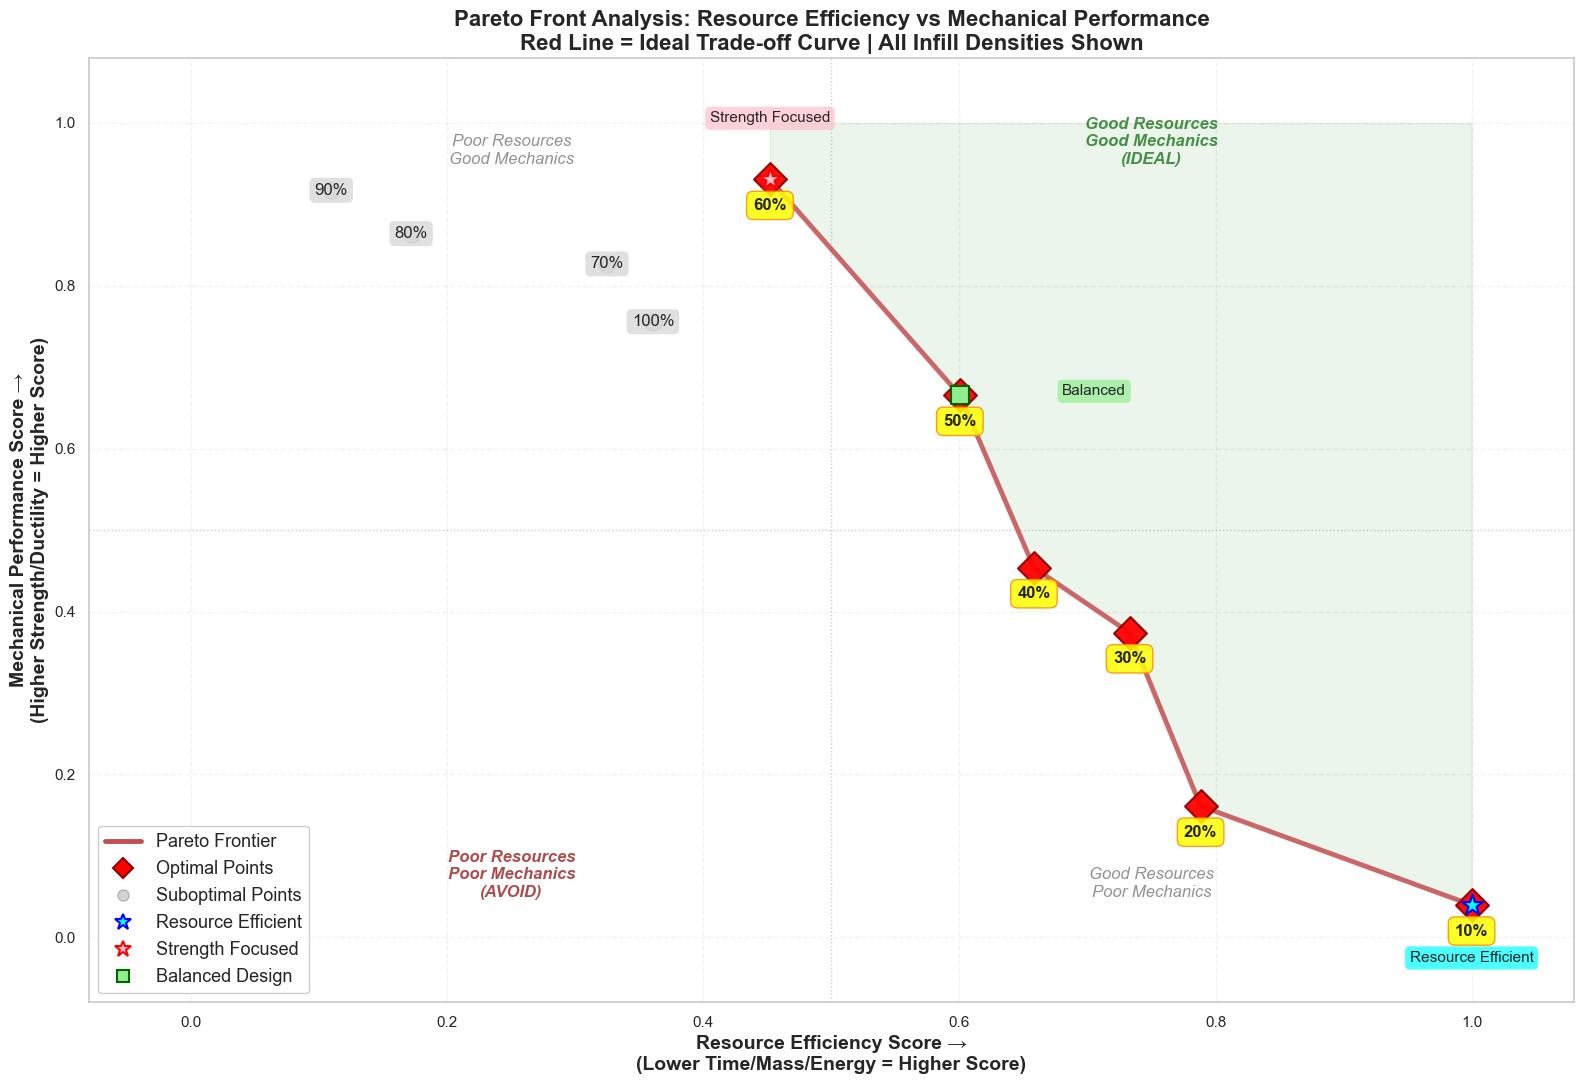

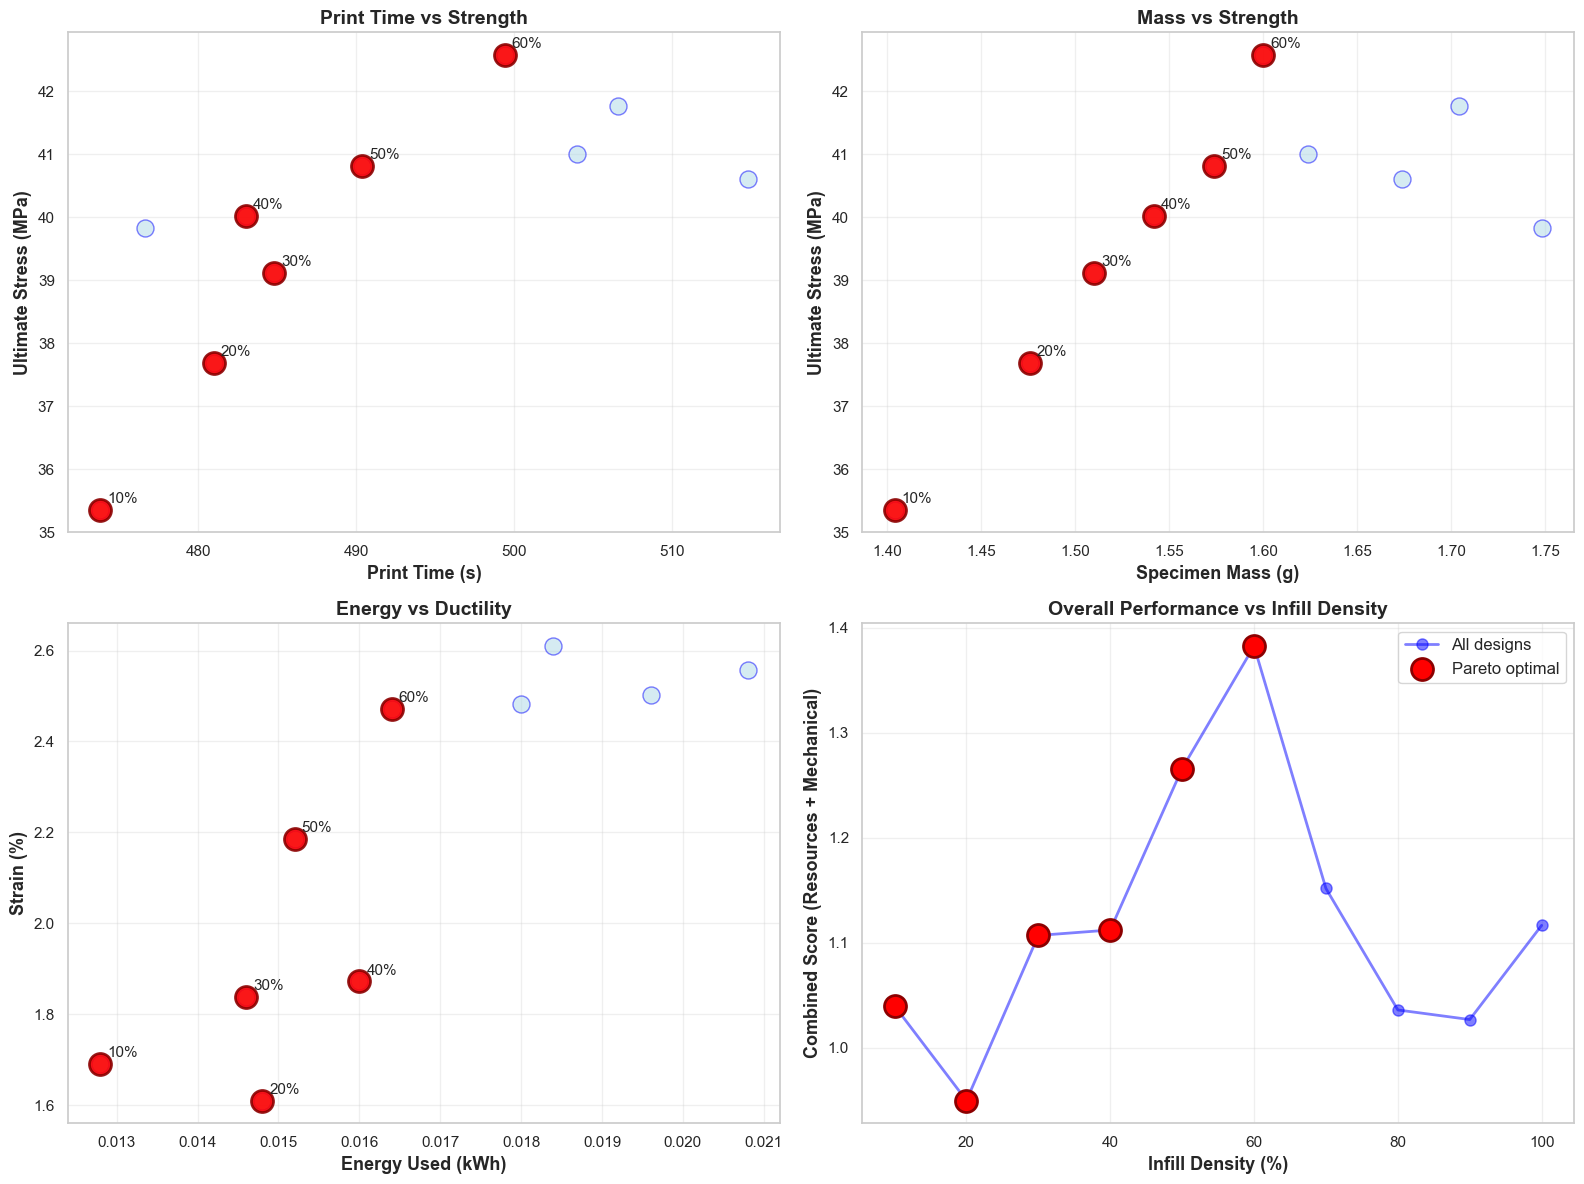

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define variables
indep_vars = ['infill_density_percent']

# Resource variables to minimize
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']

# Mechanical variables to maximize
dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']

# Create normalized dataframe for Pareto front calculation
avg_df_normalized = avg_df.copy()

# Normalize all variables to 0-1 scale (higher is better)
for var in dep_res_vars:
    # For resource variables: lower is better, so invert (1 - normalized)
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    avg_df_normalized[f'{var}_norm'] = 1 - (avg_df[var] - min_val) / (max_val - min_val)

for var in dep_mech_vars:
    # For mechanical variables: higher is better, so normalize directly
    min_val = avg_df[var].min()
    max_val = avg_df[var].max()
    avg_df_normalized[f'{var}_norm'] = (avg_df[var] - min_val) / (max_val - min_val)

# Calculate composite fitness scores
avg_df_normalized['resource_score'] = avg_df_normalized[[f'{var}_norm' for var in dep_res_vars]].mean(axis=1)
avg_df_normalized['mechanical_score'] = avg_df_normalized[[f'{var}_norm' for var in dep_mech_vars]].mean(axis=1)

# Identify Pareto front (points where you can't improve one without worsening the other)
def identify_pareto_front(df, objective1, objective2):
    """
    Identify Pareto front points
    Returns boolean mask of Pareto optimal points
    """
    is_pareto = np.ones(df.shape[0], dtype=bool)
    
    for i in range(df.shape[0]):
        for j in range(df.shape[0]):
            if i != j:
                # If point j is better or equal in both objectives, i is not Pareto optimal
                if (df.iloc[j][objective1] >= df.iloc[i][objective1] and 
                    df.iloc[j][objective2] >= df.iloc[i][objective2]):
                    if (df.iloc[j][objective1] > df.iloc[i][objective1] or 
                        df.iloc[j][objective2] > df.iloc[i][objective2]):
                        is_pareto[i] = False
                        break
    
    return is_pareto

# Find Pareto optimal solutions
pareto_mask = identify_pareto_front(avg_df_normalized, 'resource_score', 'mechanical_score')
pareto_front = avg_df_normalized[pareto_mask].sort_values('resource_score')

print("\n" + "="*80)
print("PARETO FRONT ANALYSIS - RESOURCE vs MECHANICAL PROPERTIES")
print("="*80)
print(f"\nTotal Design Points: {len(avg_df_normalized)}")
print(f"Pareto Optimal Points: {len(pareto_front)}")
print(f"Percentage on Pareto Front: {len(pareto_front)/len(avg_df_normalized)*100:.1f}%")

print(f"\n{'-'*80}")
print("PARETO FRONT DESIGNS (Sorted by Resource Score)")
print(f"{'-'*80}\n")

# Display Pareto front details
pareto_display = pareto_front[[
    'infill_density_percent',
    'print_time_actual',
    'actual_specimen_mass_g',
    'energy_used_kwh',
    'ultimate_stress_mpa',
    'strain_percent',
    'resource_score',
    'mechanical_score'
]].round(3)

print(pareto_display.to_string())

print(f"\n{'-'*80}")
print("DESIGN RECOMMENDATIONS")
print(f"{'-'*80}\n")

# Find specific optimal points
best_resources_idx = pareto_front['resource_score'].idxmax()
best_mechanical_idx = pareto_front['mechanical_score'].idxmax()
balanced_idx = (pareto_front['resource_score'] + pareto_front['mechanical_score']).idxmax()

print("1. BEST RESOURCE EFFICIENCY (Minimize Time/Mass/Energy):")
print(f"   Infill Density: {avg_df_normalized.loc[best_resources_idx, 'infill_density_percent']:.1f}%")
print(f"   Print Time: {avg_df_normalized.loc[best_resources_idx, 'print_time_actual']:.2f} s")
print(f"   Mass: {avg_df_normalized.loc[best_resources_idx, 'actual_specimen_mass_g']:.3f} g")
print(f"   Energy: {avg_df_normalized.loc[best_resources_idx, 'energy_used_kwh']:.4f} kWh")
print(f"   Resource Score: {avg_df_normalized.loc[best_resources_idx, 'resource_score']:.3f}")

print(f"\n2. BEST MECHANICAL PERFORMANCE (Maximize Strength/Ductility):")
print(f"   Infill Density: {avg_df_normalized.loc[best_mechanical_idx, 'infill_density_percent']:.1f}%")
print(f"   Ultimate Stress: {avg_df_normalized.loc[best_mechanical_idx, 'ultimate_stress_mpa']:.2f} MPa")
print(f"   Strain: {avg_df_normalized.loc[best_mechanical_idx, 'strain_percent']:.2f}%")
print(f"   Mechanical Score: {avg_df_normalized.loc[best_mechanical_idx, 'mechanical_score']:.3f}")

print(f"\n3. BALANCED DESIGN (Best Overall Trade-off):")
print(f"   Infill Density: {avg_df_normalized.loc[balanced_idx, 'infill_density_percent']:.1f}%")
print(f"   Print Time: {avg_df_normalized.loc[balanced_idx, 'print_time_actual']:.2f} s")
print(f"   Mass: {avg_df_normalized.loc[balanced_idx, 'actual_specimen_mass_g']:.3f} g")
print(f"   Energy: {avg_df_normalized.loc[balanced_idx, 'energy_used_kwh']:.4f} kWh")
print(f"   Ultimate Stress: {avg_df_normalized.loc[balanced_idx, 'ultimate_stress_mpa']:.2f} MPa")
print(f"   Strain: {avg_df_normalized.loc[balanced_idx, 'strain_percent']:.2f}%")
print(f"   Combined Score: {(avg_df_normalized.loc[balanced_idx, 'resource_score'] + avg_df_normalized.loc[balanced_idx, 'mechanical_score']):.3f}")

print("="*80)

# ============================================================================
# VISUALIZATION 1: Pareto Front - Resource vs Mechanical Score
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 11))

# Plot all non-pareto points with labels
non_pareto = avg_df_normalized[~pareto_mask]
ax.scatter(non_pareto['resource_score'], 
           non_pareto['mechanical_score'],
           s=150, alpha=0.5, color='lightgray', edgecolor='darkgray', linewidth=0.8,
           label='Suboptimal designs', zorder=1)

# Label non-pareto points
for idx, row in non_pareto.iterrows():
    ax.annotate(f"{row['infill_density_percent']:.0f}%",
                (row['resource_score'], row['mechanical_score']),
                fontsize=12, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7, edgecolor='none'),
                zorder=2)

# Sort Pareto front by resource score for proper line drawing
pareto_sorted = pareto_front.sort_values('resource_score', ascending=False)

# Draw the Pareto frontier line prominently
ax.plot(pareto_sorted['resource_score'], 
        pareto_sorted['mechanical_score'],
        'r-', linewidth=3.5, alpha=0.85, label='Pareto Frontier (Ideal Curve)', zorder=4)

# Highlight Pareto optimal points with diamond markers
ax.scatter(pareto_front['resource_score'], 
           pareto_front['mechanical_score'],
           s=280, alpha=0.95, color='red', edgecolor='darkred', linewidth=1.5,
           label='Pareto optimal points', zorder=5, marker='D')

# Add reference zone shading to show the ideal region
ax.fill_between(pareto_sorted['resource_score'], 
                pareto_sorted['mechanical_score'], 
                1.0, 
                alpha=0.08, color='green')

# Annotate each Pareto point with infill density
for idx, row in pareto_sorted.iterrows():
    infill = row['infill_density_percent']
    resource = row['resource_score']
    mechanical = row['mechanical_score']
    
    ax.annotate(f"{infill:.0f}%",
                (resource, mechanical),
                xytext=(0, -22), textcoords='offset points',
                fontsize=12, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.85, edgecolor='darkorange', linewidth=1),
                zorder=6)

# Identify special reference points
best_resources = pareto_front.loc[pareto_front['resource_score'].idxmax()]
best_mechanical = pareto_front.loc[pareto_front['mechanical_score'].idxmax()]
balanced = pareto_front.iloc[(pareto_front['resource_score'] - pareto_front['mechanical_score']).abs().argmin()]

# Mark special reference points with smaller stars
ax.scatter([best_resources['resource_score']], [best_resources['mechanical_score']],
          s=250, marker='*', color='cyan', edgecolor='blue', linewidth=1.5, zorder=6)

ax.scatter([best_mechanical['resource_score']], [best_mechanical['mechanical_score']],
          s=250, marker='*', color='pink', edgecolor='red', linewidth=1.5, zorder=6)

ax.scatter([balanced['resource_score']], [balanced['mechanical_score']],
          s=150, marker='s', color='lightgreen', edgecolor='darkgreen', linewidth=1.5, zorder=6)

# Add simple text labels for reference points
ax.text(best_resources['resource_score'], best_resources['mechanical_score'] - 0.07,
        'Resource Efficient', ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='cyan', alpha=0.7, edgecolor='none'))

ax.text(best_mechanical['resource_score'], best_mechanical['mechanical_score'] + 0.07,
        'Strength Focused', ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='pink', alpha=0.7, edgecolor='none'))

ax.text(balanced['resource_score'] + 0.08, balanced['mechanical_score'],
        'Balanced', ha='left', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7, edgecolor='none'))

# Add quadrant lines and labels
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.4)
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.4)

ax.text(0.25, 0.95, 'Poor Resources\nGood Mechanics', ha='center', fontsize=12, 
        style='italic', alpha=0.5)
ax.text(0.75, 0.95, 'Good Resources\nGood Mechanics\n(IDEAL)', ha='center', fontsize=12, 
        fontweight='bold', style='italic', alpha=0.7, color='darkgreen')
ax.text(0.75, 0.05, 'Good Resources\nPoor Mechanics', ha='center', fontsize=12, 
        style='italic', alpha=0.5)
ax.text(0.25, 0.05, 'Poor Resources\nPoor Mechanics\n(AVOID)', ha='center', fontsize=12, 
        fontweight='bold', style='italic', alpha=0.7, color='darkred')

ax.set_xlabel('Resource Efficiency Score →\n(Lower Time/Mass/Energy = Higher Score)', 
              fontsize=14, fontweight='bold')
ax.set_ylabel('Mechanical Performance Score →\n(Higher Strength/Ductility = Higher Score)', 
              fontsize=14, fontweight='bold')
ax.set_title('Pareto Front Analysis: Resource Efficiency vs Mechanical Performance\nRed Line = Ideal Trade-off Curve | All Infill Densities Shown', 
             fontsize=16, fontweight='bold')

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='r', lw=3.5),
                 Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
                        markeredgecolor='darkred', markersize=10, markeredgewidth=1.5),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', 
                        markeredgecolor='darkgray', markersize=8, markeredgewidth=0.8),
                 Line2D([0], [0], marker='*', color='w', markerfacecolor='cyan', 
                        markeredgecolor='blue', markersize=12, markeredgewidth=1.5),
                 Line2D([0], [0], marker='*', color='w', markerfacecolor='pink', 
                        markeredgecolor='red', markersize=12, markeredgewidth=1.5),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
                        markeredgecolor='darkgreen', markersize=8, markeredgewidth=1.5)]
ax.legend(custom_lines, ['Pareto Frontier', 'Optimal Points', 'Suboptimal Points', 
                          'Resource Efficient', 'Strength Focused', 'Balanced Design'],
          fontsize=13, loc='lower left', framealpha=0.95)

ax.grid(True, alpha=0.25, linestyle='--')
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.08, 1.08)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Individual Objective Trade-offs
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Print Time vs Ultimate Stress
ax = axes[0, 0]
ax.scatter(avg_df_normalized['print_time_actual'], 
           avg_df_normalized['ultimate_stress_mpa'],
           s=150, alpha=0.5, color='lightblue', edgecolor='blue')
ax.scatter(pareto_front['print_time_actual'], 
           pareto_front['ultimate_stress_mpa'],
           s=250, alpha=0.9, color='red', edgecolor='darkred', linewidth=2)
for idx, row in pareto_front.iterrows():
    ax.annotate(f"{row['infill_density_percent']:.0f}%",
                (row['print_time_actual'], row['ultimate_stress_mpa']),
                xytext=(5, 5), textcoords='offset points', fontsize=11)
ax.set_xlabel('Print Time (s)', fontsize=13, fontweight='bold')
ax.set_ylabel('Ultimate Stress (MPa)', fontsize=13, fontweight='bold')
ax.set_title('Print Time vs Strength', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Mass vs Ultimate Stress
ax = axes[0, 1]
ax.scatter(avg_df_normalized['actual_specimen_mass_g'], 
           avg_df_normalized['ultimate_stress_mpa'],
           s=150, alpha=0.5, color='lightblue', edgecolor='blue')
ax.scatter(pareto_front['actual_specimen_mass_g'], 
           pareto_front['ultimate_stress_mpa'],
           s=250, alpha=0.9, color='red', edgecolor='darkred', linewidth=2)
for idx, row in pareto_front.iterrows():
    ax.annotate(f"{row['infill_density_percent']:.0f}%",
                (row['actual_specimen_mass_g'], row['ultimate_stress_mpa']),
                xytext=(5, 5), textcoords='offset points', fontsize=11)
ax.set_xlabel('Specimen Mass (g)', fontsize=13, fontweight='bold')
ax.set_ylabel('Ultimate Stress (MPa)', fontsize=13, fontweight='bold')
ax.set_title('Mass vs Strength', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)

# Plot 3: Energy vs Strain
ax = axes[1, 0]
ax.scatter(avg_df_normalized['energy_used_kwh'], 
           avg_df_normalized['strain_percent'],
           s=150, alpha=0.5, color='lightblue', edgecolor='blue')
ax.scatter(pareto_front['energy_used_kwh'], 
           pareto_front['strain_percent'],
           s=250, alpha=0.9, color='red', edgecolor='darkred', linewidth=2)
for idx, row in pareto_front.iterrows():
    ax.annotate(f"{row['infill_density_percent']:.0f}%",
                (row['energy_used_kwh'], row['strain_percent']),
                xytext=(5, 5), textcoords='offset points', fontsize=11)
ax.set_xlabel('Energy Used (kWh)', fontsize=13, fontweight='bold')
ax.set_ylabel('Strain (%)', fontsize=13, fontweight='bold')
ax.set_title('Energy vs Ductility', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)

# Plot 4: Infill Density vs Combined Score
ax = axes[1, 1]
combined_score = avg_df_normalized['resource_score'] + avg_df_normalized['mechanical_score']
ax.plot(avg_df_normalized['infill_density_percent'], 
        combined_score,
        'o-', linewidth=2, markersize=8, color='blue', alpha=0.5, label='All designs')
pareto_combined = pareto_front['resource_score'] + pareto_front['mechanical_score']
ax.scatter(pareto_front['infill_density_percent'], 
           pareto_combined,
           s=250, color='red', edgecolor='darkred', linewidth=2, label='Pareto optimal', zorder=5)
ax.set_xlabel('Infill Density (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Combined Score (Resources + Mechanical)', fontsize=13, fontweight='bold')
ax.set_title('Overall Performance vs Infill Density', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Pareto Bar Chart


PARETO CHART DATA - INFILL DENSITY PERFORMANCE RANKING

Weighting Structure:
  MECHANICAL PERFORMANCE (60% weight):
    - Ultimate Stress MPa: 50% of mechanical = 30% overall
    - Strain %: 50% of mechanical = 30% overall
  RESOURCE PARAMETERS (40% weight):
    - Print Time: 33.33% of resource = 13.33% overall
    - Energy Used: 33.33% of resource = 13.33% overall
    - Specimen Mass: 33.33% of resource = 13.33% overall

Ranked by Overall Performance Score:

 infill_density_percent  print_time_actual  actual_specimen_mass_g  energy_used_kwh  ultimate_stress_mpa  strain_percent  overall_score  performance_percentage  cumulative_percentage
                     60              499.4                   1.600            0.016               42.577           2.472          0.691                  69.136                 12.360
                     50              490.4                   1.574            0.015               40.808           2.186          0.633                  63.296          

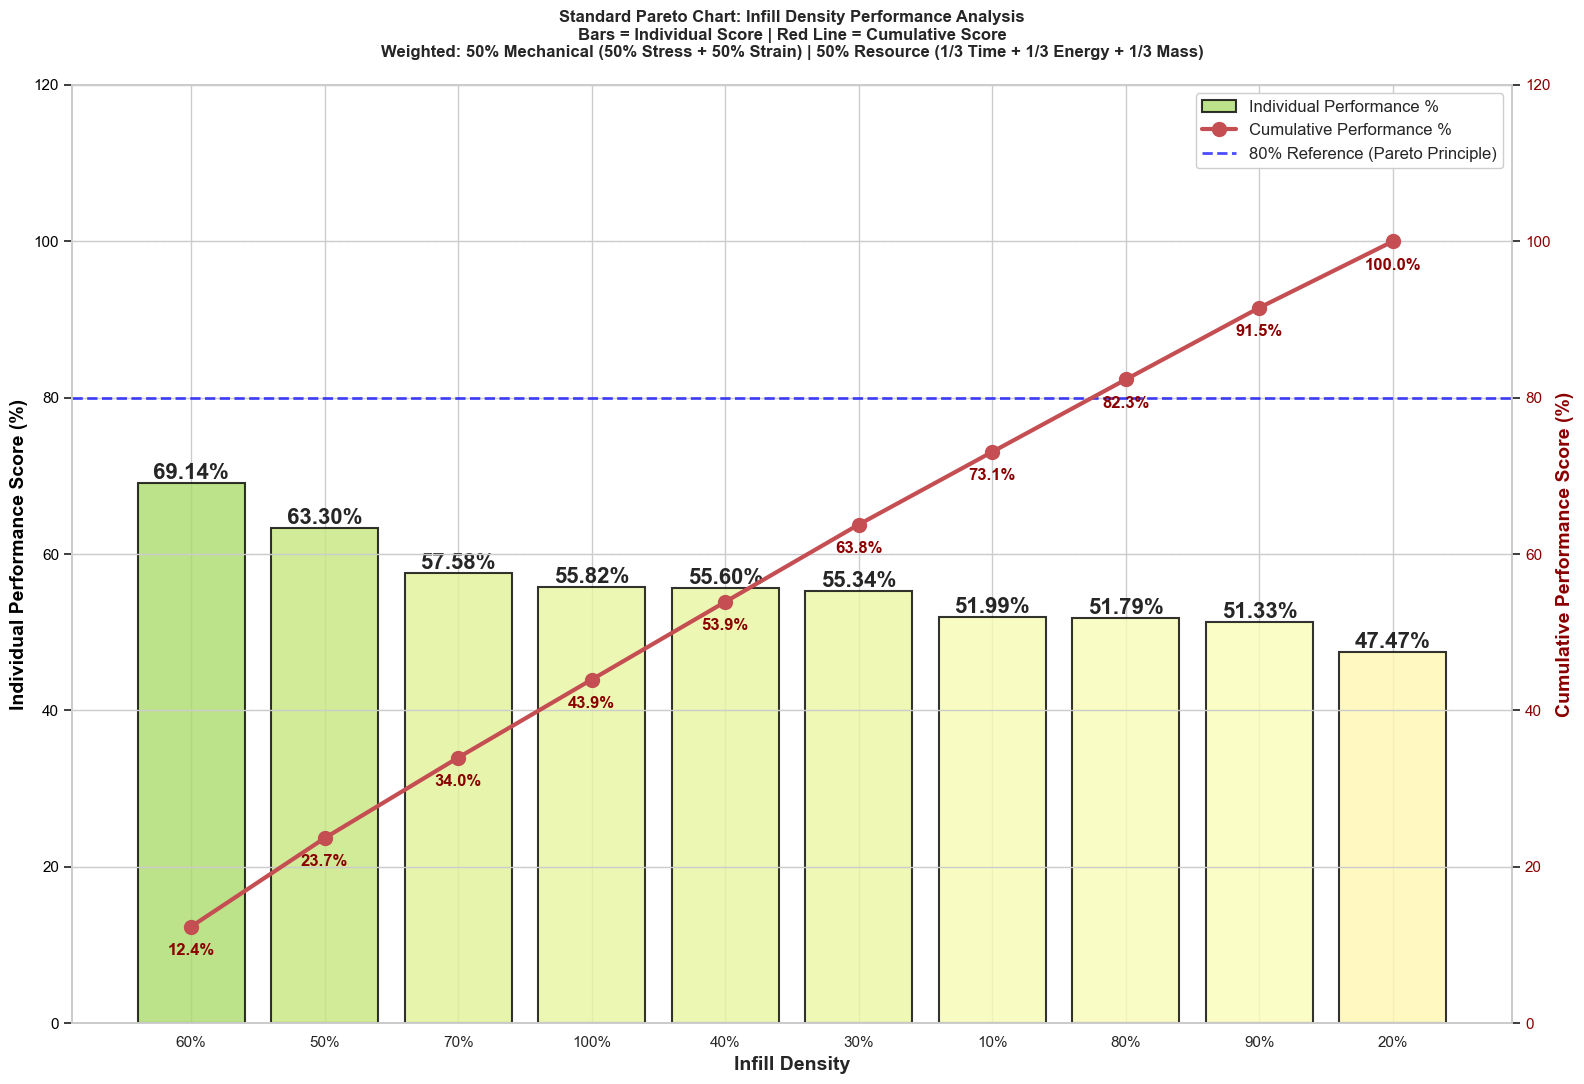


--------------------------------------------------------------------------------
KEY INSIGHTS
--------------------------------------------------------------------------------

Top 3 Performing Infill Densities:
1. 60% - Score: 0.691 (69.1%)
2. 50% - Score: 0.633 (63.3%)
3. 70% - Score: 0.576 (57.6%)

Pareto Principle (80/20):
To achieve 80% of optimal performance, focus on these infill densities:
60%, 50%, 70%, 100%, 40%, 30%, 10%, 80%
This represents 8 out of 10 infill densities tested
Cumulative Performance: 82.3%

Best Overall Design (Weighted Score: 50% Mechanical / 50% Resource):
Infill Density: 60%
  Print Time: 499.40 s
  Specimen Mass: 1.600 g
  Energy Used: 0.0164 kWh
  Ultimate Stress: 42.58 MPa
  Strain: 2.47%
  Overall Weighted Score: 0.691 (69.1%)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# STANDARD PARETO CHART - Bar Graph + Cumulative Line
# ============================================================================
# Mechanical Performance: 60% (stress 50% + strain 50%)
# Resource Parameters: 40% (time 1/3 + energy 1/3 + mass 1/3)

# Create a copy for analysis
pareto_df = avg_df.copy()

# Sort by infill density for consistent ordering
pareto_df = pareto_df.sort_values('infill_density_percent').reset_index(drop=True)

# Calculate weighted importance score for each infill density
# Combining resource efficiency and mechanical performance

# Normalize each metric (0-1 scale, where 1 is best)
metrics_to_analyze = {
    'print_time_actual': 'minimize',      # Lower is better
    'actual_specimen_mass_g': 'minimize', # Lower is better
    'energy_used_kwh': 'minimize',        # Lower is better
    'ultimate_stress_mpa': 'maximize',    # Higher is better
    'strain_percent': 'maximize'          # Higher is better
}

# Create normalized metrics
pareto_normalized = pareto_df.copy()

for metric, direction in metrics_to_analyze.items():
    min_val = pareto_df[metric].min()
    max_val = pareto_df[metric].max()
    
    if direction == 'minimize':
        # For minimize: lower values get higher scores (inverted)
        pareto_normalized[f'{metric}_norm'] = 1 - (pareto_df[metric] - min_val) / (max_val - min_val)
    else:
        # For maximize: higher values get higher scores
        pareto_normalized[f'{metric}_norm'] = (pareto_df[metric] - min_val) / (max_val - min_val)

# ============================================================================
# WEIGHTED COMPOSITE SCORES (60% Mechanical / 40% Resource)
# ============================================================================

# MECHANICAL SCORE (60% total weight)
# ultimate_stress_mpa: 50% of mechanical score
# strain_percent: 50% of mechanical score
mechanical_score_raw = (0.5 * pareto_normalized['ultimate_stress_mpa_norm'] + 
                        0.5 * pareto_normalized['strain_percent_norm'])

# RESOURCE SCORE (40% total weight)
# print_time_actual: 1/3 of resource score
# energy_used_kwh: 1/3 of resource score
# actual_specimen_mass_g: 1/3 of resource score
resource_score_raw = ((1/3) * pareto_normalized['print_time_actual_norm'] + 
                      (1/3) * pareto_normalized['energy_used_kwh_norm'] + 
                      (1/3) * pareto_normalized['actual_specimen_mass_g_norm'])

# OVERALL WEIGHTED SCORE
# Mechanical: 60% weight
# Resource: 40% weight
overall_weighted_score = (0.50 * mechanical_score_raw + 0.50 * resource_score_raw)

# Convert to percentage (0-100)
pareto_normalized['overall_score'] = overall_weighted_score
pareto_normalized['performance_percentage'] = overall_weighted_score * 100

# Sort by performance score (descending) for Pareto chart
pareto_sorted = pareto_normalized.sort_values('overall_score', ascending=False).reset_index(drop=True)

# Calculate cumulative percentage
pareto_sorted['cumulative_percentage'] = pareto_sorted['performance_percentage'].cumsum()
pareto_sorted['cumulative_percentage'] = (pareto_sorted['cumulative_percentage'] / 
                                          pareto_sorted['performance_percentage'].sum()) * 100

print("\n" + "="*80)
print("PARETO CHART DATA - INFILL DENSITY PERFORMANCE RANKING")
print("="*80)
print("\nWeighting Structure:")
print("  MECHANICAL PERFORMANCE (60% weight):")
print("    - Ultimate Stress MPa: 50% of mechanical = 30% overall")
print("    - Strain %: 50% of mechanical = 30% overall")
print("  RESOURCE PARAMETERS (40% weight):")
print("    - Print Time: 33.33% of resource = 13.33% overall")
print("    - Energy Used: 33.33% of resource = 13.33% overall")
print("    - Specimen Mass: 33.33% of resource = 13.33% overall")

print("\nRanked by Overall Performance Score:\n")

display_df = pareto_sorted[[
    'infill_density_percent',
    'print_time_actual',
    'actual_specimen_mass_g',
    'energy_used_kwh',
    'ultimate_stress_mpa',
    'strain_percent',
    'overall_score',
    'performance_percentage',
    'cumulative_percentage'
]].round(3)

print(display_df.to_string(index=False))

# ============================================================================
# CREATE STANDARD PARETO CHART
# ============================================================================

fig, ax1 = plt.subplots(figsize=(16, 11))

# Prepare data
infill_densities = [f"{int(d)}%" for d in pareto_sorted['infill_density_percent']]
performance_pcts = pareto_sorted['performance_percentage'].values
cumulative_pcts = pareto_sorted['cumulative_percentage'].values

# Color bars: green for high performance, red for low
colors = plt.cm.RdYlGn(performance_pcts / 100)

# Plot bars on primary y-axis
bars = ax1.bar(infill_densities, performance_pcts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8, label='Individual Performance %')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, performance_pcts)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%',
             ha='center', va='bottom', fontsize=16, fontweight='bold')

ax1.set_xlabel('Infill Density', fontsize=14, fontweight='bold')
ax1.set_ylabel('Individual Performance Score (%)', fontsize=14, fontweight='bold', color='black')
ax1.set_ylim(0, 120)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# Create secondary y-axis for cumulative line
ax2 = ax1.twinx()

# Plot cumulative line
line = ax2.plot(infill_densities, cumulative_pcts, 'ro-', linewidth=3, markersize=10, 
                label='Cumulative Performance %', zorder=5)

# Add value labels on cumulative line
for i, (x, y) in enumerate(zip(infill_densities, cumulative_pcts)):
    ax2.text(i, y - 4, f'{y:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkred')

ax2.set_ylabel('Cumulative Performance Score (%)', fontsize=14, fontweight='bold', color='darkred')
ax2.set_ylim(0, 120)
ax2.tick_params(axis='y', labelcolor='darkred')

# Add 80% reference line (Pareto principle)
ax2.axhline(y=80, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='80% Reference (Pareto Principle)')

# Title and legend
plt.title('Standard Pareto Chart: Infill Density Performance Analysis\nBars = Individual Score | Red Line = Cumulative Score\nWeighted: 50% Mechanical (50% Stress + 50% Strain) | 50% Resource (1/3 Time + 1/3 Energy + 1/3 Mass)', 
          fontsize=12, fontweight='bold', pad=20)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=12, framealpha=0.95)

plt.tight_layout()
plt.show()

# ============================================================================
# IDENTIFY KEY INSIGHTS
# ============================================================================

print(f"\n{'-'*80}")
print("KEY INSIGHTS")
print(f"{'-'*80}\n")

# Top 3 performers
print("Top 3 Performing Infill Densities:")
for i in range(min(3, len(pareto_sorted))):
    row = pareto_sorted.iloc[i]
    print(f"{i+1}. {int(row['infill_density_percent'])}% - Score: {row['overall_score']:.3f} ({row['performance_percentage']:.1f}%)")

# 80/20 rule analysis
cumulative_80_idx = (pareto_sorted['cumulative_percentage'] >= 80).idxmax() if (pareto_sorted['cumulative_percentage'] >= 80).any() else len(pareto_sorted) - 1
infills_for_80 = pareto_sorted.iloc[:cumulative_80_idx + 1]['infill_density_percent'].values

print(f"\nPareto Principle (80/20):")
print(f"To achieve 80% of optimal performance, focus on these infill densities:")
print(f"{', '.join([f'{int(d)}%' for d in infills_for_80])}")
print(f"This represents {len(infills_for_80)} out of {len(pareto_sorted)} infill densities tested")
print(f"Cumulative Performance: {pareto_sorted.iloc[cumulative_80_idx]['cumulative_percentage']:.1f}%")

# Detailed metrics for top performer
top_performer = pareto_sorted.iloc[0]
print(f"\nBest Overall Design (Weighted Score: 50% Mechanical / 50% Resource):")
print(f"Infill Density: {int(top_performer['infill_density_percent'])}%")
print(f"  Print Time: {top_performer['print_time_actual']:.2f} s")
print(f"  Specimen Mass: {top_performer['actual_specimen_mass_g']:.3f} g")
print(f"  Energy Used: {top_performer['energy_used_kwh']:.4f} kWh")
print(f"  Ultimate Stress: {top_performer['ultimate_stress_mpa']:.2f} MPa")
print(f"  Strain: {top_performer['strain_percent']:.2f}%")
print(f"  Overall Weighted Score: {top_performer['overall_score']:.3f} ({top_performer['performance_percentage']:.1f}%)")

print("="*80)

In [ ]:
df.head()

,item_no,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,remarks
0,1,4/14/2026,15:15:57,15:23:30,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,453.0,1.40,1.44,0.013,35.8098,1.68293,NaN
1,2,4/14/2026,15:25:15,15:33:12,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,477.0,1.40,1.44,0.013,33.5701,1.92406,NaN
2,3,4/14/2026,15:34:26,15:42:32,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,486.0,1.40,1.44,0.013,36.1737,1.59461,NaN
3,4,4/14/2026,15:43:59,15:51:56,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,477.0,1.41,1.44,0.013,36.8314,1.54971,NaN
4,5,4/14/2026,15:53:29,16:01:25,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,193.0,476.0,1.41,1.44,0.012,34.4062,1.69792,NaN


In [ ]:
import pandas as pd

# 3. Compute the new average dataset grouped by Infill Density
# Replace 'Infill Density (%)' with your actual infill column name
avg_df_opt = df.groupby('infill_density_percent').median(numeric_only=True).reset_index()

# Display the optimized average dataset
avg_df_opt.head(10)

,infill_density_percent,item_no,replicate_no,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,remarks
0,10,3.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,193.0,477.0,1.40,1.44,0.013,35.8098,1.68293,NaN
1,20,8.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,195.0,481.0,1.48,1.49,0.015,38.3593,1.65602,NaN
2,30,13.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,196.0,482.0,1.51,1.52,0.015,39.6049,1.88064,NaN
3,40,18.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,198.0,483.0,1.54,1.55,0.016,40.3547,1.86416,NaN
4,50,23.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,206.0,490.0,1.57,1.59,0.015,40.9604,2.20555,NaN
5,60,28.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,210.0,497.0,1.60,1.62,0.017,40.1057,2.40172,NaN
6,70,33.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,219.0,503.0,1.62,1.64,0.018,38.8435,2.43016,NaN
7,80,38.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,228.0,514.0,1.67,1.70,0.019,40.4904,2.56495,NaN
8,90,43.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,231.0,520.0,1.70,1.73,0.021,41.7739,2.57699,NaN
9,100,48.0,3.0,0.2,220.0,50.0,2.0,5.0,5.0,192.0,477.0,1.75,1.76,0.018,39.6388,2.46313,NaN


In [ ]:
# ============================================================================
# NORMALIZED INFILL DENSITY TABLE
# ============================================================================
 
# Define variables
indep_vars = ['infill_density_percent']
 
# Resource variables to minimize
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']
 
# Mechanical variables to maximize
dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']
 
 
# ============================================================================
# CREATE NORMALIZED TABLE FOR MECHANICAL & RESOURCE PARAMETERS
# ============================================================================
 
normalized_params_df = pd.DataFrame()
 
# Keep original infill density
normalized_params_df['Infill Density (%)'] = avg_df_opt['infill_density_percent'].values
 
# Resource variables (minimize - invert normalization: 1 - normalized)
print("Normalizing Resource Parameters (Lower is Better)...")
for var in dep_res_vars:
    min_val = avg_df_opt[var].min()
    max_val = avg_df_opt[var].max()
    normalized_params_df[f'{var}_norm'] = (
        1 - (avg_df_opt[var] - min_val) / (max_val - min_val)
    ).round(4)
 
# Mechanical variables (maximize - normal normalization)
print("Normalizing Mechanical Properties (Higher is Better)...")
for var in dep_mech_vars:
    min_val = avg_df_opt[var].min()
    max_val = avg_df_opt[var].max()
    normalized_params_df[f'{var}_norm'] = (
        (avg_df_opt[var] - min_val) / (max_val - min_val)
    ).round(4)
 
# Sort by infill density
normalized_params_df = normalized_params_df.sort_values('Infill Density (%)').reset_index(drop=True)
 
print("\n" + "="*100)
print("NORMALIZED MECHANICAL PROPERTIES & RESOURCE PARAMETERS")
print("="*100 + "\n")
print("Resource Variables (Normalized: 1 = Best, 0 = Worst):")
print("  - print_time_actual_norm")
print("  - actual_specimen_mass_g_norm")
print("  - energy_used_kwh_norm")
print("\nMechanical Variables (Normalized: 1 = Best, 0 = Worst):")
print("  - ultimate_stress_mpa_norm")
print("  - strain_percent_norm")
print("\n" + "-"*100 + "\n")
display(normalized_params_df)

Normalizing Resource Parameters (Lower is Better)...
Normalizing Mechanical Properties (Higher is Better)...

NORMALIZED MECHANICAL PROPERTIES & RESOURCE PARAMETERS

Resource Variables (Normalized: 1 = Best, 0 = Worst):
  - print_time_actual_norm
  - actual_specimen_mass_g_norm
  - energy_used_kwh_norm

Mechanical Variables (Normalized: 1 = Best, 0 = Worst):
  - ultimate_stress_mpa_norm
  - strain_percent_norm

----------------------------------------------------------------------------------------------------



,Infill Density (%),print_time_actual_norm,actual_specimen_mass_g_norm,energy_used_kwh_norm,ultimate_stress_mpa_norm,strain_percent_norm
0,10,1.0000,1.0000,1.000,0.0000,0.0292
1,20,0.9070,0.7714,0.750,0.4275,0.0000
2,30,0.8837,0.6857,0.750,0.6363,0.2439
3,40,0.8605,0.6000,0.625,0.7620,0.2260
4,50,0.6977,0.5143,0.750,0.8636,0.5967
5,60,0.5349,0.4286,0.500,0.7203,0.8097
6,70,0.3953,0.3714,0.375,0.5087,0.8406
7,80,0.1395,0.2286,0.250,0.7848,0.9869
8,90,0.0000,0.1429,0.000,1.0000,1.0000
9,100,1.0000,0.0000,0.375,0.6420,0.8764


In [ ]:
# Define variables
indep_vars = ['infill_density_percent']

# Resource variables to minimize
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']

# Mechanical variables to maximize
dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']

# Compute weighted scores
scores_df = pd.DataFrame()
scores_df['Infill Density (%)'] = avg_df_opt['infill_density_percent'].values

# Mechanical Score (50% weight)
mechanical_score = pd.Series([0.0] * len(avg_df_opt))
for var in dep_mech_vars:
    min_val = avg_df_opt[var].min()
    max_val = avg_df_opt[var].max()
    normalized = (avg_df_opt[var] - min_val) / (max_val - min_val)
    mechanical_score += 0.5 * normalized

scores_df['Mechanical Score (50%)'] = mechanical_score.round(4)

# Resource Score (50% weight)
resource_score = pd.Series([0.0] * len(avg_df_opt))
for var in dep_res_vars:
    min_val = avg_df_opt[var].min()
    max_val = avg_df_opt[var].max()
    normalized = 1 - (avg_df[var] - min_val) / (max_val - min_val)
    resource_score += (1/3) * normalized

scores_df['Resource Score (50%)'] = resource_score.round(4)

# Overall Score (50% Mechanical + 50% Resource)
overall_score = (0.50 * mechanical_score) + (0.50 * resource_score)
scores_df['Overall Score'] = overall_score.round(4)

# Sort by infill density
scores_df = scores_df.sort_values('Infill Density (%)').reset_index(drop=True)

# Display the table
display(scores_df)

,Infill Density (%),Mechanical Score (50%),Resource Score (50%),Overall Score
0,10,0.0146,1.0293,0.5220
1,20,0.2137,0.8216,0.5177
2,30,0.4401,0.7681,0.6041
3,40,0.4940,0.6933,0.5936
4,50,0.7301,0.6387,0.6844
5,60,0.7650,0.4942,0.6296
6,70,0.6746,0.3690,0.5218
7,80,0.8859,0.2210,0.5534
8,90,1.0000,0.1560,0.5780
9,100,0.7592,0.3967,0.5779



PARETO CHART DATA - INFILL DENSITY PERFORMANCE RANKING

Weighting Structure:
  MECHANICAL PERFORMANCE (60% weight):
    - Ultimate Stress MPa: 50% of mechanical = 30% overall
    - Strain %: 50% of mechanical = 30% overall
  RESOURCE PARAMETERS (40% weight):
    - Print Time: 33.33% of resource = 13.33% overall
    - Energy Used: 33.33% of resource = 13.33% overall
    - Specimen Mass: 33.33% of resource = 13.33% overall

Ranked by Overall Performance Score:

 infill_density_percent  print_time_actual  actual_specimen_mass_g  energy_used_kwh  ultimate_stress_mpa  strain_percent  overall_score  performance_percentage  cumulative_percentage
                     50              490.0                    1.57            0.015               40.960           2.206          0.692                  69.207                 12.047
                     60              497.0                    1.60            0.017               40.106           2.402          0.626                  62.640          

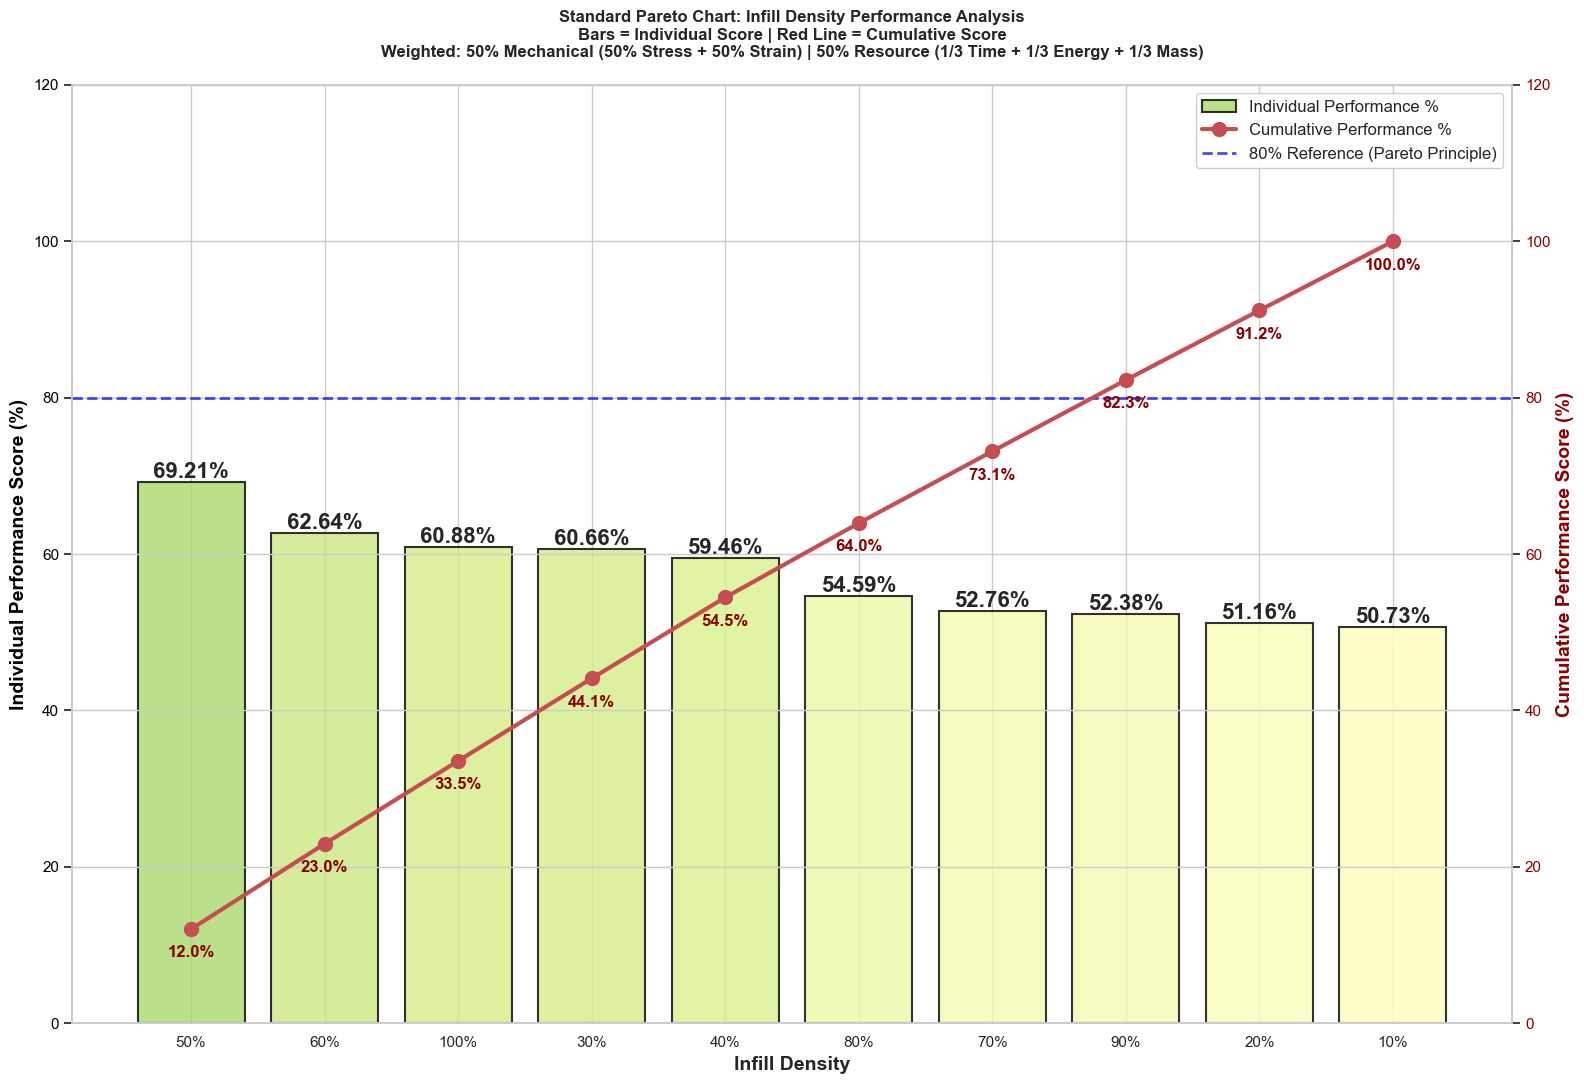


--------------------------------------------------------------------------------
KEY INSIGHTS
--------------------------------------------------------------------------------

Top 3 Performing Infill Densities:
1. 50% - Score: 0.692 (69.2%)
2. 60% - Score: 0.626 (62.6%)
3. 100% - Score: 0.609 (60.9%)

Pareto Principle (80/20):
To achieve 80% of optimal performance, focus on these infill densities:
50%, 60%, 100%, 30%, 40%, 80%, 70%, 90%
This represents 8 out of 10 infill densities tested
Cumulative Performance: 82.3%

Best Overall Design (Weighted Score: 50% Mechanical / 50% Resource):
Infill Density: 50%
  Print Time: 490.00 s
  Specimen Mass: 1.570 g
  Energy Used: 0.0150 kWh
  Ultimate Stress: 40.96 MPa
  Strain: 2.21%
  Overall Weighted Score: 0.692 (69.2%)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# STANDARD PARETO CHART - Bar Graph + Cumulative Line
# ============================================================================
# Mechanical Performance: 60% (stress 50% + strain 50%)
# Resource Parameters: 40% (time 1/3 + energy 1/3 + mass 1/3)

# Create a copy for analysis
pareto_df = avg_df_opt.copy()

# Sort by infill density for consistent ordering
pareto_df = pareto_df.sort_values('infill_density_percent').reset_index(drop=True)

# Calculate weighted importance score for each infill density
# Combining resource efficiency and mechanical performance

# Normalize each metric (0-1 scale, where 1 is best)
metrics_to_analyze = {
    'print_time_actual': 'minimize',      # Lower is better
    'actual_specimen_mass_g': 'minimize', # Lower is better
    'energy_used_kwh': 'minimize',        # Lower is better
    'ultimate_stress_mpa': 'maximize',    # Higher is better
    'strain_percent': 'maximize'          # Higher is better
}

# Create normalized metrics
pareto_normalized = pareto_df.copy()

for metric, direction in metrics_to_analyze.items():
    min_val = pareto_df[metric].min()
    max_val = pareto_df[metric].max()
    
    if direction == 'minimize':
        # For minimize: lower values get higher scores (inverted)
        pareto_normalized[f'{metric}_norm'] = 1 - (pareto_df[metric] - min_val) / (max_val - min_val)
    else:
        # For maximize: higher values get higher scores
        pareto_normalized[f'{metric}_norm'] = (pareto_df[metric] - min_val) / (max_val - min_val)

# ============================================================================
# WEIGHTED COMPOSITE SCORES (60% Mechanical / 40% Resource)
# ============================================================================

# MECHANICAL SCORE (60% total weight)
# ultimate_stress_mpa: 50% of mechanical score
# strain_percent: 50% of mechanical score
mechanical_score_raw = (0.5 * pareto_normalized['ultimate_stress_mpa_norm'] + 
                        0.5 * pareto_normalized['strain_percent_norm'])

# RESOURCE SCORE (40% total weight)
# print_time_actual: 1/3 of resource score
# energy_used_kwh: 1/3 of resource score
# actual_specimen_mass_g: 1/3 of resource score
resource_score_raw = ((1/3) * pareto_normalized['print_time_actual_norm'] + 
                      (1/3) * pareto_normalized['energy_used_kwh_norm'] + 
                      (1/3) * pareto_normalized['actual_specimen_mass_g_norm'])

# OVERALL WEIGHTED SCORE
# Mechanical: 60% weight
# Resource: 40% weight
overall_weighted_score = (0.50 * mechanical_score_raw + 0.50 * resource_score_raw)

# Convert to percentage (0-100)
pareto_normalized['overall_score'] = overall_weighted_score
pareto_normalized['performance_percentage'] = overall_weighted_score * 100

# Sort by performance score (descending) for Pareto chart
pareto_sorted = pareto_normalized.sort_values('overall_score', ascending=False).reset_index(drop=True)

# Calculate cumulative percentage
pareto_sorted['cumulative_percentage'] = pareto_sorted['performance_percentage'].cumsum()
pareto_sorted['cumulative_percentage'] = (pareto_sorted['cumulative_percentage'] / 
                                          pareto_sorted['performance_percentage'].sum()) * 100

print("\n" + "="*80)
print("PARETO CHART DATA - INFILL DENSITY PERFORMANCE RANKING")
print("="*80)
print("\nWeighting Structure:")
print("  MECHANICAL PERFORMANCE (60% weight):")
print("    - Ultimate Stress MPa: 50% of mechanical = 30% overall")
print("    - Strain %: 50% of mechanical = 30% overall")
print("  RESOURCE PARAMETERS (40% weight):")
print("    - Print Time: 33.33% of resource = 13.33% overall")
print("    - Energy Used: 33.33% of resource = 13.33% overall")
print("    - Specimen Mass: 33.33% of resource = 13.33% overall")

print("\nRanked by Overall Performance Score:\n")

display_df = pareto_sorted[[
    'infill_density_percent',
    'print_time_actual',
    'actual_specimen_mass_g',
    'energy_used_kwh',
    'ultimate_stress_mpa',
    'strain_percent',
    'overall_score',
    'performance_percentage',
    'cumulative_percentage'
]].round(3)

print(display_df.to_string(index=False))

# ============================================================================
# CREATE STANDARD PARETO CHART
# ============================================================================

fig, ax1 = plt.subplots(figsize=(16, 11))

# Prepare data
infill_densities = [f"{int(d)}%" for d in pareto_sorted['infill_density_percent']]
performance_pcts = pareto_sorted['performance_percentage'].values
cumulative_pcts = pareto_sorted['cumulative_percentage'].values

# Color bars: green for high performance, red for low
colors = plt.cm.RdYlGn(performance_pcts / 100)

# Plot bars on primary y-axis
bars = ax1.bar(infill_densities, performance_pcts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8, label='Individual Performance %')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, performance_pcts)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%',
             ha='center', va='bottom', fontsize=16, fontweight='bold')

ax1.set_xlabel('Infill Density', fontsize=14, fontweight='bold')
ax1.set_ylabel('Individual Performance Score (%)', fontsize=14, fontweight='bold', color='black')
ax1.set_ylim(0, 120)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# Create secondary y-axis for cumulative line
ax2 = ax1.twinx()

# Plot cumulative line
line = ax2.plot(infill_densities, cumulative_pcts, 'ro-', linewidth=3, markersize=10, 
                label='Cumulative Performance %', zorder=5)

# Add value labels on cumulative line
for i, (x, y) in enumerate(zip(infill_densities, cumulative_pcts)):
    ax2.text(i, y - 4, f'{y:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkred')

ax2.set_ylabel('Cumulative Performance Score (%)', fontsize=14, fontweight='bold', color='darkred')
ax2.set_ylim(0, 120)
ax2.tick_params(axis='y', labelcolor='darkred')

# Add 80% reference line (Pareto principle)
ax2.axhline(y=80, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='80% Reference (Pareto Principle)')

# Title and legend
plt.title('Standard Pareto Chart: Infill Density Performance Analysis\nBars = Individual Score | Red Line = Cumulative Score\nWeighted: 50% Mechanical (50% Stress + 50% Strain) | 50% Resource (1/3 Time + 1/3 Energy + 1/3 Mass)', 
          fontsize=12, fontweight='bold', pad=20)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=12, framealpha=0.95)

plt.tight_layout()
plt.show()

# ============================================================================
# IDENTIFY KEY INSIGHTS
# ============================================================================

print(f"\n{'-'*80}")
print("KEY INSIGHTS")
print(f"{'-'*80}\n")

# Top 3 performers
print("Top 3 Performing Infill Densities:")
for i in range(min(3, len(pareto_sorted))):
    row = pareto_sorted.iloc[i]
    print(f"{i+1}. {int(row['infill_density_percent'])}% - Score: {row['overall_score']:.3f} ({row['performance_percentage']:.1f}%)")

# 80/20 rule analysis
cumulative_80_idx = (pareto_sorted['cumulative_percentage'] >= 80).idxmax() if (pareto_sorted['cumulative_percentage'] >= 80).any() else len(pareto_sorted) - 1
infills_for_80 = pareto_sorted.iloc[:cumulative_80_idx + 1]['infill_density_percent'].values

print(f"\nPareto Principle (80/20):")
print(f"To achieve 80% of optimal performance, focus on these infill densities:")
print(f"{', '.join([f'{int(d)}%' for d in infills_for_80])}")
print(f"This represents {len(infills_for_80)} out of {len(pareto_sorted)} infill densities tested")
print(f"Cumulative Performance: {pareto_sorted.iloc[cumulative_80_idx]['cumulative_percentage']:.1f}%")

# Detailed metrics for top performer
top_performer = pareto_sorted.iloc[0]
print(f"\nBest Overall Design (Weighted Score: 50% Mechanical / 50% Resource):")
print(f"Infill Density: {int(top_performer['infill_density_percent'])}%")
print(f"  Print Time: {top_performer['print_time_actual']:.2f} s")
print(f"  Specimen Mass: {top_performer['actual_specimen_mass_g']:.3f} g")
print(f"  Energy Used: {top_performer['energy_used_kwh']:.4f} kWh")
print(f"  Ultimate Stress: {top_performer['ultimate_stress_mpa']:.2f} MPa")
print(f"  Strain: {top_performer['strain_percent']:.2f}%")
print(f"  Overall Weighted Score: {top_performer['overall_score']:.3f} ({top_performer['performance_percentage']:.1f}%)")

print("="*80)

--- Pairwise Dominance Matrix Table ---


,10,20,30,40,50,60,70,80,90,100
Infill (%),,,,,,,,,,
10,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
20,Non-Dominated,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
30,Non-Dominated,Non-Dominated,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
40,Non-Dominated,Non-Dominated,Non-Dominated,—,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated
50,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,—,Non-Dominated,Dominates,Non-Dominated,Non-Dominated,Non-Dominated
60,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,—,Dominates,Non-Dominated,Non-Dominated,Dominates
70,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Defeated,Defeated,—,Non-Dominated,Non-Dominated,Defeated
80,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,—,Non-Dominated,Non-Dominated
90,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,Non-Dominated,—,Non-Dominated


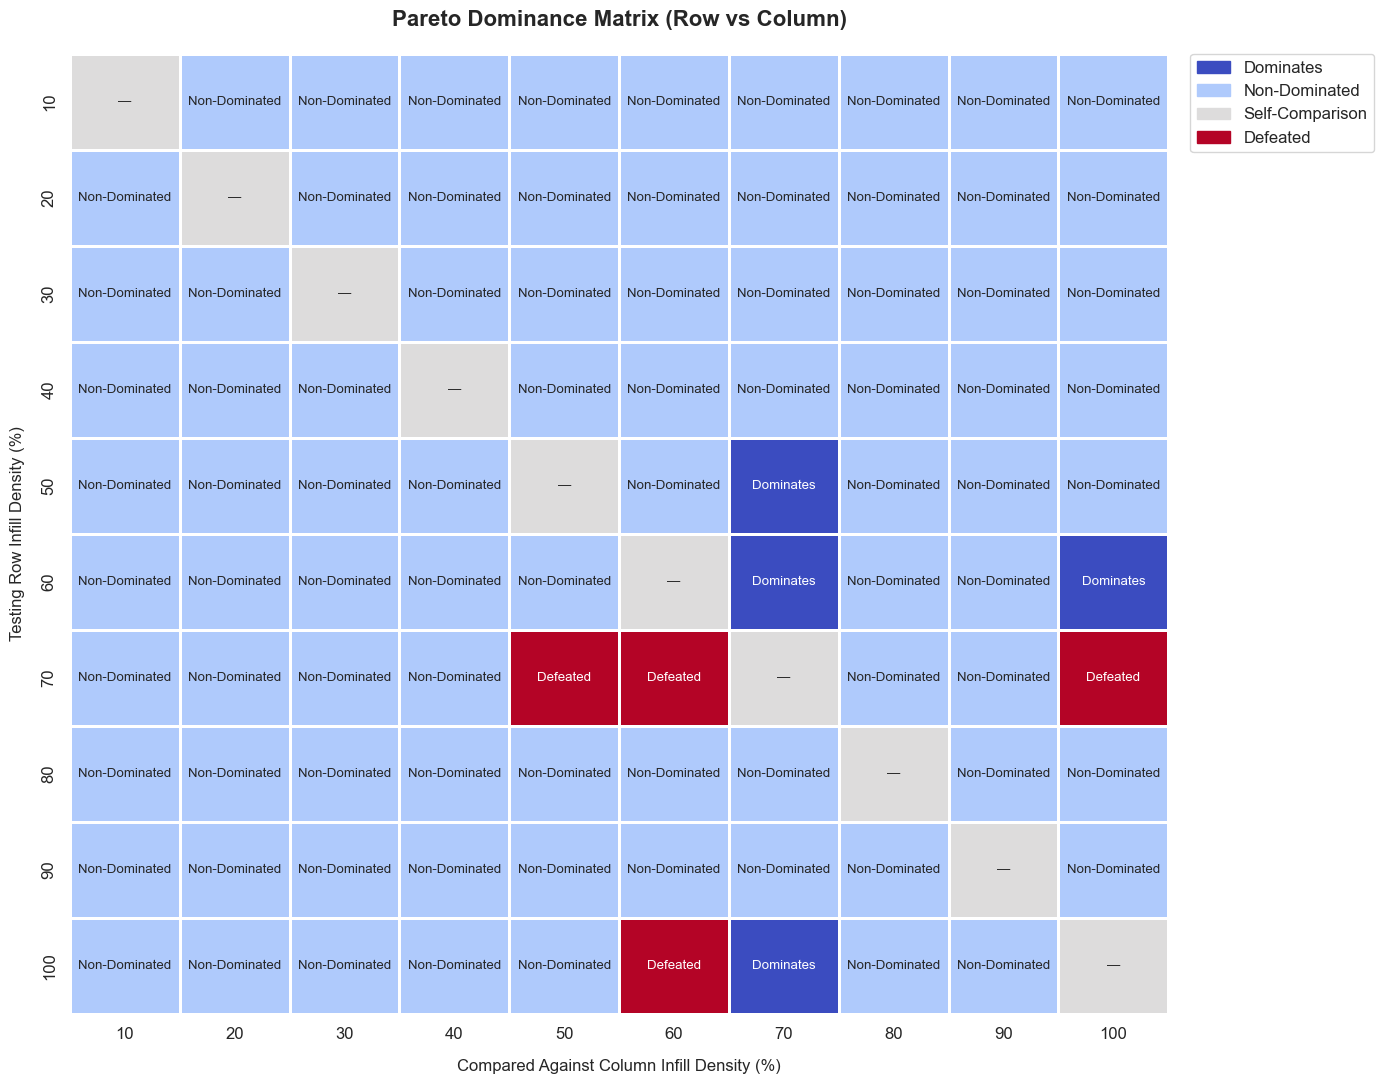

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Extract the normalized scores from your existing scores_df
infills = scores_df['Infill Density (%)'].values
mech_scores = scores_df['Mechanical Score (50%)'].values
res_scores = scores_df['Resource Score (50%)'].values
n = len(infills)

# 2. Initialize arrays for full text categories and numeric color codes
# We re-index the integers to map cleanly onto a coolwarm gradient space
# 0.0 = Dominates (Deep Blue), 0.35 = Non-Dominated (Soft Light Blue/Gray)
# 0.5 = Self (Neutral Light), 1.0 = Defeated (Deep Red)
dominance_numeric = np.zeros((n, n))
dominance_text = np.empty((n, n), dtype=object)

for i in range(n):
    for j in range(n):
        if i == j:
            dominance_text[i, j] = "—"
            dominance_numeric[i, j] = 0.5  # Neutral center of coolwarm
            continue
        
        # Alternative A (Row i) vs Alternative B (Column j)
        a_dominates_b = (
            (mech_scores[i] >= mech_scores[j] and res_scores[i] > res_scores[j]) or
            (mech_scores[i] > mech_scores[j] and res_scores[i] >= res_scores[j])
        )
        
        b_dominates_a = (
            (mech_scores[j] >= mech_scores[i] and res_scores[j] > res_scores[i]) or
            (mech_scores[j] > mech_scores[i] and res_scores[j] >= res_scores[i])
        )
        
        if a_dominates_b:
            dominance_text[i, j] = "Dominates"
            dominance_numeric[i, j] = 0.0   # Cool Anchor
        elif b_dominates_a:
            dominance_text[i, j] = "Defeated"
            dominance_numeric[i, j] = 1.0   # Warm Anchor
        else:
            dominance_text[i, j] = "Non-Dominated"
            dominance_numeric[i, j] = 0.35  # Transition Cool-Neutral

# 3. Create DataFrame for clean text display in Jupyter
matrix_df = pd.DataFrame(dominance_text, index=infills, columns=infills)
matrix_df.index.name = "Infill (%)"

print("--- Pairwise Dominance Matrix Table ---")
display(matrix_df)

# 4. Generate the Categorical Visual Heatmap using 'coolwarm'
plt.figure(figsize=(14, 11))

# We set vmin=0 and vmax=1 to map our explicit anchors perfectly to the coolwarm spectrum
ax = sns.heatmap(
    dominance_numeric, 
    annot=dominance_text, 
    fmt="", 
    cmap="coolwarm", 
    vmin=0,
    vmax=1,
    cbar=False,
    xticklabels=infills, 
    yticklabels=infills,
    linewidths=1,
    annot_kws={"size": 9.5}
)

ax.tick_params(axis='both', which='major', labelsize=12)

# 5. Build an explicit color legend panel sampled from the coolwarm space
# Fetching the exact hex colors extracted by the colormap bounds for consistency
cmap_sample = plt.cm.coolwarm([0.0, 0.35, 0.5, 1.0])
colors_hex = [plt.cm.colors.to_hex(c) for c in cmap_sample]

labels = ["Dominates", "Non-Dominated", "Self-Comparison", "Defeated"]
# Reordering legend logically for the reader
legend_order = [0, 1, 2, 3] 

patches = [mpatches.Patch(color=colors_hex[k], label=labels[k]) for k in legend_order]
plt.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=12)

plt.title("Pareto Dominance Matrix (Row vs Column)", fontsize=16, pad=20, weight='bold')
plt.xlabel("Compared Against Column Infill Density (%)", fontsize=12, labelpad=12)
plt.ylabel("Testing Row Infill Density (%)", fontsize=12, labelpad=12)
plt.tight_layout()
plt.show()


PARETO FRONT ANALYSIS - RESOURCE vs MECHANICAL PROPERTIES

Weighting Structure (50:50 Balance):
  MECHANICAL PERFORMANCE (50% weight):
    - Ultimate Stress MPa: 50% of mechanical = 25% overall
    - Strain %: 50% of mechanical = 25% overall
  RESOURCE PARAMETERS (50% weight):
    - Print Time: 33.33% of resource = 16.67% overall
    - Energy Used: 33.33% of resource = 16.67% overall
    - Specimen Mass: 33.33% of resource = 16.67% overall

Total Design Points: 10
Pareto Optimal Points: 8
Percentage on Pareto Front: 80.0%

--------------------------------------------------------------------------------
PARETO FRONT DESIGNS (Sorted by Resource Score)
--------------------------------------------------------------------------------

   infill_density_percent  print_time_actual  actual_specimen_mass_g  energy_used_kwh  ultimate_stress_mpa  strain_percent  resource_score  mechanical_score  overall_weighted_score
8                      90              520.0                    1.70          

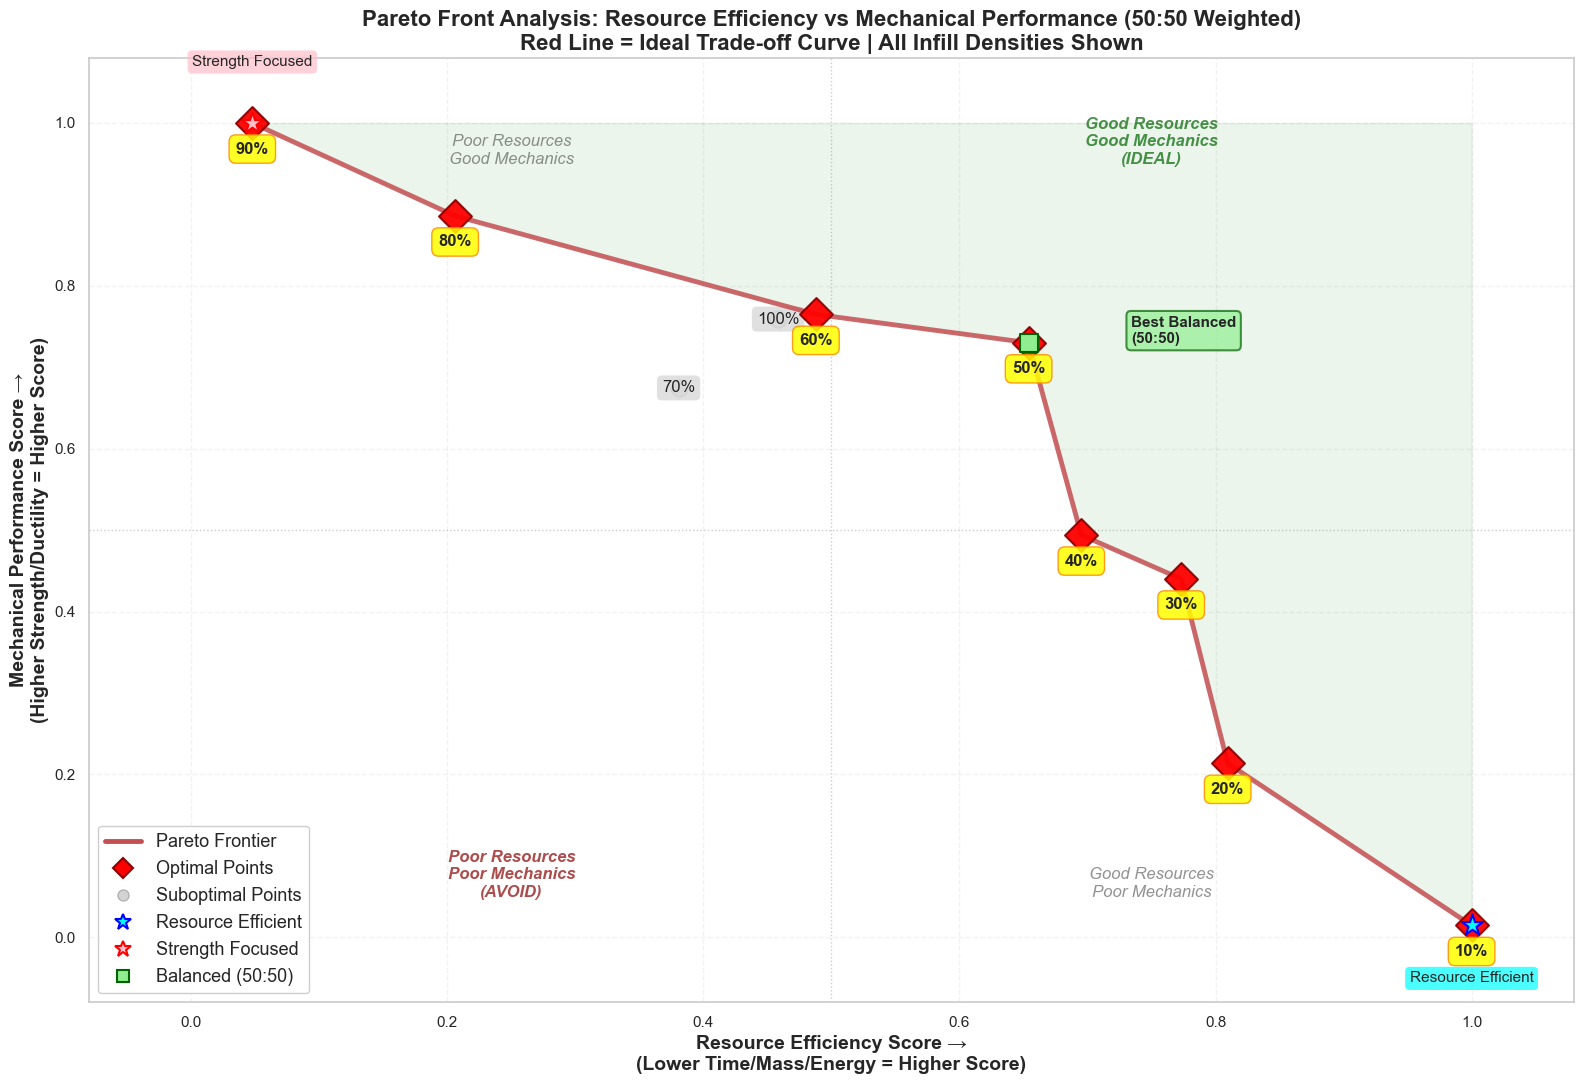

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define variables
indep_vars = ['infill_density_percent']

# Resource variables to minimize
dep_res_vars = ['print_time_actual',
                'actual_specimen_mass_g',
                'energy_used_kwh']

# Mechanical variables to maximize
dep_mech_vars = ['ultimate_stress_mpa',
                 'strain_percent']

# ============================================================================
# NORMALIZATION WITH 50:50 WEIGHTED SCORING
# ============================================================================
# Mechanical Performance: 50% (stress 50% + strain 50%)
# Resource Parameters: 50% (time 1/3 + energy 1/3 + mass 1/3)

# Create normalized dataframe for Pareto front calculation
avg_df_normalized = avg_df_opt.copy()

# Normalize all variables to 0-1 scale (higher is better)
for var in dep_res_vars:
    # For resource variables: lower is better, so invert (1 - normalized)
    min_val = avg_df_opt[var].min()
    max_val = avg_df_opt[var].max()
    avg_df_normalized[f'{var}_norm'] = 1 - (avg_df_opt[var] - min_val) / (max_val - min_val)

for var in dep_mech_vars:
    # For mechanical variables: higher is better, so normalize directly
    min_val = avg_df_opt[var].min()
    max_val = avg_df_opt[var].max()
    avg_df_normalized[f'{var}_norm'] = (avg_df_opt[var] - min_val) / (max_val - min_val)

# ============================================================================
# WEIGHTED COMPOSITE SCORES (50% Mechanical / 50% Resource)
# ============================================================================

# MECHANICAL SCORE (50% total weight)
# ultimate_stress_mpa: 50% of mechanical score
# strain_percent: 50% of mechanical score
mechanical_score_raw = (0.5 * avg_df_normalized['ultimate_stress_mpa_norm'] + 
                        0.5 * avg_df_normalized['strain_percent_norm'])
avg_df_normalized['mechanical_score'] = mechanical_score_raw

# RESOURCE SCORE (50% total weight)
# print_time_actual: 1/3 of resource score
# energy_used_kwh: 1/3 of resource score
# actual_specimen_mass_g: 1/3 of resource score
resource_score_raw = ((1/3) * avg_df_normalized['print_time_actual_norm'] + 
                      (1/3) * avg_df_normalized['energy_used_kwh_norm'] + 
                      (1/3) * avg_df_normalized['actual_specimen_mass_g_norm'])
avg_df_normalized['resource_score'] = resource_score_raw

# OVERALL WEIGHTED SCORE
# Mechanical: 50% weight
# Resource: 50% weight
avg_df_normalized['overall_weighted_score'] = (0.50 * mechanical_score_raw + 0.50 * resource_score_raw)

# Identify Pareto front (points where you can't improve one without worsening the other)
def identify_pareto_front(df, objective1, objective2):
    """
    Identify Pareto front points
    Returns boolean mask of Pareto optimal points
    """
    is_pareto = np.ones(df.shape[0], dtype=bool)
    
    for i in range(df.shape[0]):
        for j in range(df.shape[0]):
            if i != j:
                # If point j is better or equal in both objectives, i is not Pareto optimal
                if (df.iloc[j][objective1] >= df.iloc[i][objective1] and 
                    df.iloc[j][objective2] >= df.iloc[i][objective2]):
                    if (df.iloc[j][objective1] > df.iloc[i][objective1] or 
                        df.iloc[j][objective2] > df.iloc[i][objective2]):
                        is_pareto[i] = False
                        break
    
    return is_pareto

# Find Pareto optimal solutions
pareto_mask = identify_pareto_front(avg_df_normalized, 'resource_score', 'mechanical_score')
pareto_front = avg_df_normalized[pareto_mask].sort_values('resource_score')

print("\n" + "="*80)
print("PARETO FRONT ANALYSIS - RESOURCE vs MECHANICAL PROPERTIES")
print("="*80)
print("\nWeighting Structure (50:50 Balance):")
print("  MECHANICAL PERFORMANCE (50% weight):")
print("    - Ultimate Stress MPa: 50% of mechanical = 25% overall")
print("    - Strain %: 50% of mechanical = 25% overall")
print("  RESOURCE PARAMETERS (50% weight):")
print("    - Print Time: 33.33% of resource = 16.67% overall")
print("    - Energy Used: 33.33% of resource = 16.67% overall")
print("    - Specimen Mass: 33.33% of resource = 16.67% overall")

print(f"\nTotal Design Points: {len(avg_df_normalized)}")
print(f"Pareto Optimal Points: {len(pareto_front)}")
print(f"Percentage on Pareto Front: {len(pareto_front)/len(avg_df_normalized)*100:.1f}%")

print(f"\n{'-'*80}")
print("PARETO FRONT DESIGNS (Sorted by Resource Score)")
print(f"{'-'*80}\n")

# Display Pareto front details
pareto_display = pareto_front[[
    'infill_density_percent',
    'print_time_actual',
    'actual_specimen_mass_g',
    'energy_used_kwh',
    'ultimate_stress_mpa',
    'strain_percent',
    'resource_score',
    'mechanical_score',
    'overall_weighted_score'
]].round(3)

print(pareto_display.to_string())

print(f"\n{'-'*80}")
print("DESIGN RECOMMENDATIONS")
print(f"{'-'*80}\n")

# Find specific optimal points
best_resources_idx = pareto_front['resource_score'].idxmax()
best_mechanical_idx = pareto_front['mechanical_score'].idxmax()
balanced_idx = pareto_front['overall_weighted_score'].idxmax()

print("1. BEST RESOURCE EFFICIENCY (Minimize Time/Mass/Energy):")
print(f"   Infill Density: {avg_df_normalized.loc[best_resources_idx, 'infill_density_percent']:.1f}%")
print(f"   Print Time: {avg_df_normalized.loc[best_resources_idx, 'print_time_actual']:.2f} s")
print(f"   Mass: {avg_df_normalized.loc[best_resources_idx, 'actual_specimen_mass_g']:.3f} g")
print(f"   Energy: {avg_df_normalized.loc[best_resources_idx, 'energy_used_kwh']:.4f} kWh")
print(f"   Resource Score: {avg_df_normalized.loc[best_resources_idx, 'resource_score']:.3f}")

print(f"\n2. BEST MECHANICAL PERFORMANCE (Maximize Strength/Ductility):")
print(f"   Infill Density: {avg_df_normalized.loc[best_mechanical_idx, 'infill_density_percent']:.1f}%")
print(f"   Ultimate Stress: {avg_df_normalized.loc[best_mechanical_idx, 'ultimate_stress_mpa']:.2f} MPa")
print(f"   Strain: {avg_df_normalized.loc[best_mechanical_idx, 'strain_percent']:.2f}%")
print(f"   Mechanical Score: {avg_df_normalized.loc[best_mechanical_idx, 'mechanical_score']:.3f}")

print(f"\n3. BEST BALANCED DESIGN (50% Mechanical / 50% Resource Trade-off):")
print(f"   Infill Density: {avg_df_normalized.loc[balanced_idx, 'infill_density_percent']:.1f}%")
print(f"   Print Time: {avg_df_normalized.loc[balanced_idx, 'print_time_actual']:.2f} s")
print(f"   Mass: {avg_df_normalized.loc[balanced_idx, 'actual_specimen_mass_g']:.3f} g")
print(f"   Energy: {avg_df_normalized.loc[balanced_idx, 'energy_used_kwh']:.4f} kWh")
print(f"   Ultimate Stress: {avg_df_normalized.loc[balanced_idx, 'ultimate_stress_mpa']:.2f} MPa")
print(f"   Strain: {avg_df_normalized.loc[balanced_idx, 'strain_percent']:.2f}%")
print(f"   Resource Score (50%): {avg_df_normalized.loc[balanced_idx, 'resource_score']:.3f}")
print(f"   Mechanical Score (50%): {avg_df_normalized.loc[balanced_idx, 'mechanical_score']:.3f}")
print(f"   Overall Weighted Score: {avg_df_normalized.loc[balanced_idx, 'overall_weighted_score']:.3f}")

print("="*80)

# ============================================================================
# VISUALIZATION 1: Pareto Front - Resource vs Mechanical Score
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 11))

# Plot all non-pareto points with labels
non_pareto = avg_df_normalized[~pareto_mask]
ax.scatter(non_pareto['resource_score'], 
           non_pareto['mechanical_score'],
           s=150, alpha=0.5, color='lightgray', edgecolor='darkgray', linewidth=0.8,
           label='Suboptimal designs', zorder=1)

# Label non-pareto points
for idx, row in non_pareto.iterrows():
    ax.annotate(f"{row['infill_density_percent']:.0f}%",
                (row['resource_score'], row['mechanical_score']),
                fontsize=12, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7, edgecolor='none'),
                zorder=2)

# Sort Pareto front by resource score for proper line drawing
pareto_sorted = pareto_front.sort_values('resource_score', ascending=False)

# Draw the Pareto frontier line prominently
ax.plot(pareto_sorted['resource_score'], 
        pareto_sorted['mechanical_score'],
        'r-', linewidth=3.5, alpha=0.85, label='Pareto Frontier (Ideal Curve)', zorder=4)

# Highlight Pareto optimal points with diamond markers
ax.scatter(pareto_front['resource_score'], 
           pareto_front['mechanical_score'],
           s=280, alpha=0.95, color='red', edgecolor='darkred', linewidth=1.5,
           label='Pareto optimal points', zorder=5, marker='D')

# Add reference zone shading to show the ideal region
ax.fill_between(pareto_sorted['resource_score'], 
                pareto_sorted['mechanical_score'], 
                1.0, 
                alpha=0.08, color='green')

# Annotate each Pareto point with infill density
for idx, row in pareto_sorted.iterrows():
    infill = row['infill_density_percent']
    resource = row['resource_score']
    mechanical = row['mechanical_score']
    
    ax.annotate(f"{infill:.0f}%",
                (resource, mechanical),
                xytext=(0, -22), textcoords='offset points',
                fontsize=12, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.85, edgecolor='darkorange', linewidth=1),
                zorder=6)

# Identify special reference points
best_resources = pareto_front.loc[pareto_front['resource_score'].idxmax()]
best_mechanical = pareto_front.loc[pareto_front['mechanical_score'].idxmax()]
balanced = pareto_front.loc[pareto_front['overall_weighted_score'].idxmax()]

# Mark special reference points with smaller stars
ax.scatter([best_resources['resource_score']], [best_resources['mechanical_score']],
          s=250, marker='*', color='cyan', edgecolor='blue', linewidth=1.5, zorder=6)

ax.scatter([best_mechanical['resource_score']], [best_mechanical['mechanical_score']],
          s=250, marker='*', color='pink', edgecolor='red', linewidth=1.5, zorder=6)

ax.scatter([balanced['resource_score']], [balanced['mechanical_score']],
          s=150, marker='s', color='lightgreen', edgecolor='darkgreen', linewidth=1.5, zorder=6)

# Add simple text labels for reference points
ax.text(best_resources['resource_score'], best_resources['mechanical_score'] - 0.07,
        'Resource Efficient', ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='cyan', alpha=0.7, edgecolor='none'))

ax.text(best_mechanical['resource_score'], best_mechanical['mechanical_score'] + 0.07,
        'Strength Focused', ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='pink', alpha=0.7, edgecolor='none'))

ax.text(balanced['resource_score'] + 0.08, balanced['mechanical_score'],
        'Best Balanced\n(50:50)', ha='left', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7, edgecolor='darkgreen', linewidth=1.5))

# Add quadrant lines and labels
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.4)
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.4)

ax.text(0.25, 0.95, 'Poor Resources\nGood Mechanics', ha='center', fontsize=12, 
        style='italic', alpha=0.5)
ax.text(0.75, 0.95, 'Good Resources\nGood Mechanics\n(IDEAL)', ha='center', fontsize=12, 
        fontweight='bold', style='italic', alpha=0.7, color='darkgreen')
ax.text(0.75, 0.05, 'Good Resources\nPoor Mechanics', ha='center', fontsize=12, 
        style='italic', alpha=0.5)
ax.text(0.25, 0.05, 'Poor Resources\nPoor Mechanics\n(AVOID)', ha='center', fontsize=12, 
        fontweight='bold', style='italic', alpha=0.7, color='darkred')

ax.set_xlabel('Resource Efficiency Score →\n(Lower Time/Mass/Energy = Higher Score)', 
              fontsize=14, fontweight='bold')
ax.set_ylabel('Mechanical Performance Score →\n(Higher Strength/Ductility = Higher Score)', 
              fontsize=14, fontweight='bold')
ax.set_title('Pareto Front Analysis: Resource Efficiency vs Mechanical Performance (50:50 Weighted)\nRed Line = Ideal Trade-off Curve | All Infill Densities Shown', 
             fontsize=16, fontweight='bold')

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='r', lw=3.5),
                 Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
                        markeredgecolor='darkred', markersize=10, markeredgewidth=1.5),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', 
                        markeredgecolor='darkgray', markersize=8, markeredgewidth=0.8),
                 Line2D([0], [0], marker='*', color='w', markerfacecolor='cyan', 
                        markeredgecolor='blue', markersize=12, markeredgewidth=1.5),
                 Line2D([0], [0], marker='*', color='w', markerfacecolor='pink', 
                        markeredgecolor='red', markersize=12, markeredgewidth=1.5),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
                        markeredgecolor='darkgreen', markersize=8, markeredgewidth=1.5)]
ax.legend(custom_lines, ['Pareto Frontier', 'Optimal Points', 'Suboptimal Points', 
                          'Resource Efficient', 'Strength Focused', 'Balanced (50:50)'],
          fontsize=13, loc='lower left', framealpha=0.95)

ax.grid(True, alpha=0.25, linestyle='--')
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.08, 1.08)

plt.tight_layout()
plt.show()